# Решение тестового технического задания от SHIFT

# Задача кредитного скоринга

### Построение бинарного классификатора для предсказания флага выхода в серьёзную просрочку в течение 90 дней после выдачи займа на основе метрики ROC-AUC. 

##### Выполнил Ямщиков Владимир

## Задача   
Необходимо построить модель, которая будет предсказывать вероятность серьёзной просрочки (90+ дней) в течение 90 дней после выдачи займа:   
0 - просрочки нет,   
1 - просрочка есть.  

## Метрика
**ROC-AUC** - площадь под ROC-кривой. Метрика нечувствительна к дисбалансу классов, что критически важно для задач кредитного скоринга, где доля дефолтов обычно составляет 10–30%.

### Условие задачи
Вам предстоит поработать с данными финтех-компании. Компания принимает заявки на займ и хочет заранее оценивать риск серьёзной просрочки.

О данных
https://drive.google.com/drive/folders/1P67wVcY0-u2jvhcMT82v1gb4hpxCXMu2?usp=sharing – ссылка на архив с данными

Данные представляют собой информацию о заёмщиках с одной целевой переменной - флаг выхода в серьёзную просрочку в течение 90 дней после выдачи займа.

## Данные

В вашем распоряжении будет несколько датасетов:

1. `train.csv` - заявки с известной целевой переменной `target`;
2. `test.csv` - заявки, для которых нужно сделать предсказание;
3. `transactions.csv` - транзакционная история клиента до даты заявки;
4. `bureau.csv` - внешняя кредитная история из бюро (1 клиент -> N счетов);
5. `previous_loans.csv` - прошлые займы клиента.

Также на диске находится ноутбук simple_baseline.ipynb, в котором есть пример того, как можно подготовить файл с ответом.

## Итоговый результат
Используйте ту же почту для загрузки решения на платформу, на которую вам пришло письмо для участия!!!

От вас нам нужен сабмит на платформе – архив submisson.zip, в котором находятся следующие файлы:

1. Прогноз модели в формате submisson.csv

2. Ноутбук с решением конкурса, EDA и формированием файла с ответами – competition.ipynb

3. Файл requirements.txt

#### Постановка задачи и критерии оценивания
Ваша задача – обучить классификатор, наилучшим образом предсказывающий целевую переменную. Помимо этого, обратите внимание на следующие важные моменты:

1. EDA (исследование данных, гипотезы, визуализации);
2. Качество кода (скорость алгоритмов, читаемость, знание и использование библиотечных функций);
3. Комментарии (пояснения к действиям, объяснение принятых решений);
4. Подбор модели (аргументированный выбор той или иной модели, валидация);
5. Скор (то, насколько хороший получится результат);
6. requirements.txt (посмотрите заранее, как должен выглядеть этот файл и из чего состоять);
7. Формирование и сохранение submisson.csv должно происходить в ноутбуке;
8. Ноутбук должен быть полностью воспроизводимым и выдавать submisson.csv аналогичный тому, что вы загрузили на платформу;
9. В приоритете будут решения, написанные самостоятельно (без использования ИИ).

Загружайте на платформу архив в формате submission.zip, в котором должен находиться submission.csv файл следующего формата:

* application_id	target
* 1	0.78
* 2	0.23
* 3	0.91
* 4	0.45
* 5	0.67

Где application_id – id клиента из тестового датасета, а target – проба вашей модели.

Истинные значения целевой переменной известны только организаторам конкурса. Решения проверяются автоматически путем сопоставления с истинными значениями.

Не забудьте отразить ваш лучший сабмит на лидерборде! Зелёная кнопка в колонке "Actions" в разделе "MySubmissions".

Метрика соревнования – roc-auc.

### Примеры графиков

#### Матрица возмущений и необходиые метрики (Confusion Matrix & useful metrics)
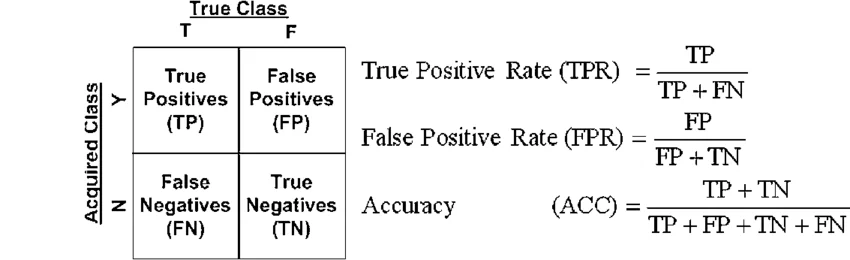

#### ROC-AUC Curve (Кривая ROC-AUC)
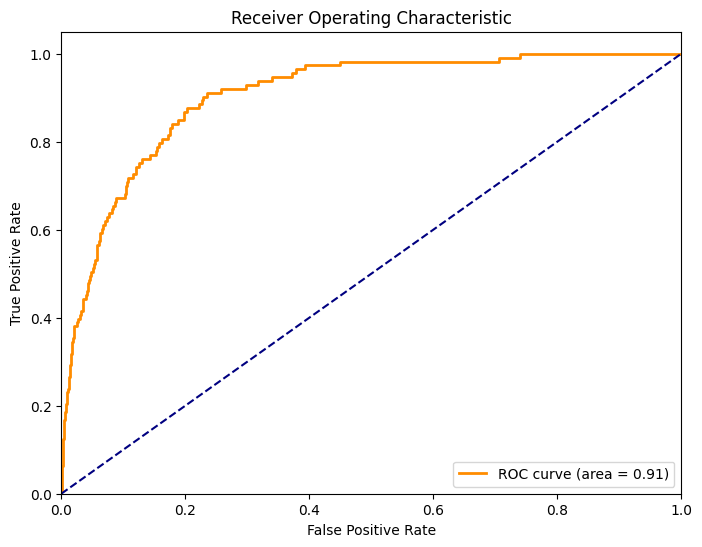

## Подход к решению задачи

1. **Агрегация реляционных данных** – превращение таблиц «1-ко-многим» в плоские признаки;
2. **Feature Engineering** – доменные признаки из кредитного скоринга;
3. **Target Encoding** – кодирование категориальных признаков без утечки данных;
4. **Удаление признаков-утечек** – `days_until_first_overdue`, `internal_decision_code`, `post_loan_collection_score`;
5. **Stacking-ансамбль** – LightGBM + CatBoost + XGBoost -> Logistic Regression;
6. **Optuna** – автоматический подбор гиперпараметров;
7. **Псевдолейблинг** – расширение обучающей выборки уверенными предсказаниями.

## Импорт библиотек

Используем проверенный стек для табличных данных:
- **LightGBM** – быстрый градиентный бустинг, хорошо работает с числовыми признаками;
- **CatBoost** – лучший выбор для категориальных признаков (нативная обработка);
- **XGBoost** – стабильный бустинг с хорошей регуляризацией;
- **Optuna** – байесовская оптимизация гиперпараметров (TPE-сэмплер);
- **SHAP** – интерпретируемость модели.

In [1]:
# Вспомогательные библиотеки и типизация
import warnings
import zipfile
from pathlib import Path
from typing import Tuple, List, Set, Dict, Any 

# Для работы с данными
import pandas as pd
import numpy as np

# Для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Интерпретация
import shap 

# Библиотека для сохранения модели
import joblib

# Ансамбли
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# Метрики и модели
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, KFold, learning_curve, train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# Для автоматического подбора параметров моделей
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Настройка параметров библиотек
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# для полного вывода без сокращения
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

RANDOM_STATE: int = 42
ROOT: Path = Path.cwd()
DATA_DIR: Path = ROOT / "data" if (ROOT / "data").exists() else ROOT

print("✅ Окружение настроено")

✅ Окружение настроено


/home/yamshchikov/ML_practice/Torchvision_core_project/MLvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Текущий корень проекта

In [2]:
print(f"Root: {ROOT}")

Root: /home/yamshchikov/ML_practice/Torchvision_core_project/Shift_ML_Tech_Task_2/notebooks


## Загрузка данных
Загружаем все 5 CSV-файлов. Проверяем размеры и базовый баланс классов.

In [3]:
print("Загрузка данных...")
train: pd.DataFrame = pd.read_csv(DATA_DIR / "../data/train.csv")
test: pd.DataFrame = pd.read_csv(DATA_DIR / "../data/test.csv")
bureau: pd.DataFrame = pd.read_csv(DATA_DIR / "../data/bureau.csv")
transactions: pd.DataFrame = pd.read_csv(DATA_DIR / "../data/transactions.csv")
previous_loans: pd.DataFrame = pd.read_csv(DATA_DIR / "../data/previous_loans.csv")

print(f"Train: {train.shape} | Test: {test.shape}")
print(f"Bureau: {bureau.shape} | Transactions: {transactions.shape} | Previous Loans: {previous_loans.shape}")

# Базовый EDA: баланс классов
target_rate: float = train['target'].mean()
print(f"Доля дефолтов (target=1) в train: {target_rate:.2%}")

Загрузка данных...
Train: (6488, 25) | Test: (2520, 24)
Bureau: (24689, 8) | Transactions: (353300, 6) | Previous Loans: (12762, 7)
Доля дефолтов (target=1) в train: 34.22%


### Загрузка данных из тренировочного файла

In [4]:
train

,application_id,client_id,employment_type,hash_id,region_coefficient_extended,age,incoming_amount,internal_decision_code,monthly_income,application_date,...,post_loan_collection_score,region_coefficient,region,interest_rate,months_at_job,dependents,days_until_first_overdue,loan_term_months,siberia_northern_score,target
0,107941,7941,employee,61441390.0,1.0,37.0,30401.28,NaN,30401.28,2025-08-11,...,800.87,1.0,east,0.3062,31.0,0.0,61.0,24.0,0.336102,1
1,101163,1163,employee,67321556.0,0.0,60.0,26024.64,manual_review_bad,26024.64,2025-12-29,...,721.57,1.0,ural,0.1383,90.0,0.0,82.0,6.0,0.560893,1
2,100583,583,contractor,26719968.0,0.0,37.0,21389.83,vip,21389.83,2025-11-09,...,NaN,1.0,west,0.1729,57.0,1.0,999.0,9.0,NaN,0
3,104082,4082,NaN,45184358.0,0.0,NaN,31617.26,approved_auto,NaN,2025-02-23,...,170.91,1.0,ural,0.3585,19.0,0.0,999.0,36.0,NaN,0
4,108413,8413,employee,58267524.0,0.0,60.0,18000.00,approved_auto,18000.00,2025-12-07,...,NaN,1.0,west,0.1472,405.0,0.0,730.0,9.0,0.741053,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6483,101662,1662,contractor,NaN,0.0,26.0,NaN,NaN,21480.58,2025-05-13,...,724.34,1.0,north,0.2237,41.0,1.0,5.0,12.0,NaN,1
6484,103037,3037,employee,84416127.0,0.0,56.0,28198.35,manual_review_bad,28198.35,2025-07-05,...,607.58,1.0,south,0.3609,182.0,0.0,94.0,NaN,NaN,1
6485,108868,8868,contractor,31058252.0,0.0,50.0,40575.25,vip,40575.25,2025-05-03,...,163.11,1.0,west,0.1939,95.0,2.0,999.0,12.0,0.486275,0
6486,102303,2303,employee,82787744.0,0.0,56.0,24783.06,approved_manual,24783.06,2025-05-18,...,NaN,NaN,center,0.2019,184.0,NaN,30.0,12.0,0.029255,0


### Загрузка данных из тестового файла

In [5]:
test

,application_id,client_id,region_coefficient_extended,loan_term_months,siberia_northern_score,hash_id,loan_amount,post_loan_collection_score,months_at_job,channel,...,employment_type,days_until_first_overdue,incoming_amount,age,dependents,interest_rate,marketing_segment,region_coefficient,requested_product,application_date
0,102531,2531,0.0,18.0,NaN,NaN,73071.51,NaN,38.0,call_center,...,employee,NaN,34183.79,NaN,0.0,0.2146,segment_112,1.0,refinance,2025-04-25
1,107213,7213,0.0,12.0,0.317813,30012008.0,65408.73,NaN,23.0,partner,...,unemployed,NaN,18645.00,64.0,0.0,0.2851,segment_023,1.0,refinance,2025-05-07
2,100238,238,0.0,36.0,0.902039,92419982.0,NaN,NaN,12.0,office,...,employee,NaN,52931.84,21.0,1.0,0.3810,segment_020,1.0,card,2025-02-26
3,104918,4918,0.0,6.0,0.737848,76137566.0,NaN,NaN,179.0,web,...,employee,NaN,37301.16,55.0,0.0,0.1471,segment_057,1.0,auto,2025-12-07
4,106480,6480,0.0,12.0,0.746599,21845266.0,76253.20,NaN,153.0,mobile,...,NaN,NaN,71928.29,55.0,1.0,0.1840,segment_138,1.0,cash,2025-05-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,105735,5735,0.0,24.0,0.496285,17047133.0,95337.81,NaN,200.0,mobile,...,employee,NaN,34557.28,NaN,1.0,0.2745,segment_139,1.0,cash,2025-10-23
2516,105192,5192,0.0,9.0,0.940226,77377804.0,NaN,NaN,206.0,web,...,self_employed,NaN,NaN,41.0,2.0,0.1992,segment_097,1.0,cash,2025-01-19
2517,105391,5391,0.0,36.0,0.765447,NaN,63097.47,NaN,48.0,partner,...,employee,NaN,25281.07,25.0,1.0,0.3981,segment_057,1.0,auto,2025-10-10
2518,100861,861,0.0,12.0,0.826164,87976929.0,148171.13,NaN,90.0,call_center,...,employee,NaN,30665.10,31.0,1.0,0.2159,segment_123,1.0,pos,2025-05-18


### Загрузка данных из файла кредитной истории

In [6]:
bureau

,client_id,bureau_account_id,account_type,opened_days_ago,credit_limit,current_balance,max_dpd_last_12m,bureau_status
0,1,B1_0,credit_card,2410.0,20474.70,5760.10,0.0,active
1,2,B2_1,NaN,2983.0,61748.02,47175.10,1.0,active
2,3,B3_2,auto,943.0,93069.06,40725.25,15.0,active
3,3,B3_3,mortgage,2355.0,173852.51,57974.36,7.0,closed
4,3,B3_4,credit_card,302.0,24037.79,7801.91,1.0,closed
...,...,...,...,...,...,...,...,...
24684,8918,B8918_24468,microloan,1637.0,21444.49,2981.00,1.0,active
24685,8681,B8681_23844,credit_card,2774.0,30805.62,17256.58,0.0,closed
24686,7264,B7264_19920,microloan,380.0,69520.13,63747.35,3.0,closed
24687,4909,B4909_13356,microloan,647.0,37868.02,12225.73,90.0,active


### Загрузка данных из файла транзакций

In [7]:
transactions

,client_id,application_id,transaction_date,transaction_category,amount,merchant_risk_level
0,1,100001,2025-10-22,transfer,-1538.95,5.0
1,1,100001,2025-07-10,cash_withdrawal,-1460.46,1.0
2,1,100001,2025-11-01,utilities,-988.50,2.0
3,1,100001,2025-10-10,salary,8578.27,3.0
4,1,100001,2025-12-24,entertainment,-2015.69,2.0
...,...,...,...,...,...,...
353295,8386,108386,2025-03-20,groceries,-961.09,1.0
353296,727,100727,2025-08-12,groceries,-6750.90,1.0
353297,780,100780,2025-04-08,transfer,-1716.45,2.0
353298,7874,107874,2025-07-07,transfer,-3241.86,2.0


### Загрузка данных из файла прошлых займов клиента

In [8]:
previous_loans

,client_id,previous_loan_id,previous_amount,previous_term_months,closed_days_ago,was_overdue,max_overdue_days
0,2,L2_0,51911.71,3.0,986.0,1.0,3.0
1,2,L2_1,64582.12,24.0,1172.0,0.0,0.0
2,3,L3_2,27102.97,3.0,744.0,0.0,0.0
3,4,L4_3,56399.68,12.0,139.0,1.0,15.0
4,4,L4_4,73117.38,18.0,548.0,0.0,0.0
...,...,...,...,...,...,...,...
12757,9000,L9000_12757,30577.75,24.0,569.0,0.0,0.0
12758,1768,L1768_2520,50626.43,6.0,400.0,0.0,0.0
12759,1831,L1831_2597,62113.07,24.0,1373.0,0.0,0.0
12760,2342,L2342_3356,68475.52,9.0,204.0,0.0,0.0


#### Получение информации о файлах

In [9]:
print("\nИнформация о данных train:")
train.info()


Информация о данных train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6488 entries, 0 to 6487
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   application_id               6488 non-null   int64  
 1   client_id                    6488 non-null   int64  
 2   employment_type              6023 non-null   object 
 3   hash_id                      6071 non-null   float64
 4   region_coefficient_extended  6027 non-null   float64
 5   age                          6039 non-null   float64
 6   incoming_amount              6055 non-null   float64
 7   internal_decision_code       5114 non-null   object 
 8   monthly_income               6047 non-null   float64
 9   application_date             6020 non-null   object 
 10  education                    6040 non-null   object 
 11  requested_product            6106 non-null   object 
 12  channel                      5911 non-null   obj

In [10]:
print("\nИнформация о данных test:")
test.info()


Информация о данных test:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   application_id               2520 non-null   int64  
 1   client_id                    2520 non-null   int64  
 2   region_coefficient_extended  2314 non-null   float64
 3   loan_term_months             2360 non-null   float64
 4   siberia_northern_score       2352 non-null   float64
 5   hash_id                      2291 non-null   float64
 6   loan_amount                  2351 non-null   float64
 7   post_loan_collection_score   0 non-null      float64
 8   months_at_job                2329 non-null   float64
 9   channel                      2315 non-null   object 
 10  education                    2345 non-null   object 
 11  internal_decision_code       0 non-null      float64
 12  monthly_income               2284 non-null   floa

In [11]:
print("\nИнформация о данных bureau:")
bureau.info()


Информация о данных bureau:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24689 entries, 0 to 24688
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   client_id          24689 non-null  int64  
 1   bureau_account_id  24689 non-null  object 
 2   account_type       23852 non-null  object 
 3   opened_days_ago    24037 non-null  float64
 4   credit_limit       23862 non-null  float64
 5   current_balance    24209 non-null  float64
 6   max_dpd_last_12m   23832 non-null  float64
 7   bureau_status      23414 non-null  object 
dtypes: float64(4), int64(1), object(3)
memory usage: 1.5+ MB


In [12]:
print("\nИнформация о данных previous_loans:")
previous_loans.info()


Информация о данных previous_loans:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12762 entries, 0 to 12761
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   client_id             12762 non-null  int64  
 1   previous_loan_id      12762 non-null  object 
 2   previous_amount       12445 non-null  float64
 3   previous_term_months  12117 non-null  float64
 4   closed_days_ago       12246 non-null  float64
 5   was_overdue           12496 non-null  float64
 6   max_overdue_days      12318 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 698.1+ KB


In [13]:
print("\nИнформация о данных transactions:")
transactions.info()


Информация о данных transactions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353300 entries, 0 to 353299
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   client_id             353300 non-null  int64  
 1   application_id        353300 non-null  int64  
 2   transaction_date      342664 non-null  object 
 3   transaction_category  335599 non-null  object 
 4   amount                341886 non-null  float64
 5   merchant_risk_level   338285 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 16.2+ MB


### Получение подробной информации и первичной статистики данных из датафрейма

In [14]:
print("Типы данных train:\n", train.dtypes)
print("Основные статистики для числовых признаков:\n", train.describe())

cat_cols_train = train.select_dtypes(include=['object']).columns
if len(cat_cols_train) > 0:
    print("Основные статистики для категориальных признаков:\n", train[cat_cols_train].describe())

Типы данных train:
 application_id                   int64
client_id                        int64
employment_type                 object
hash_id                        float64
region_coefficient_extended    float64
age                            float64
incoming_amount                float64
internal_decision_code          object
monthly_income                 float64
application_date                object
education                       object
requested_product               object
channel                         object
loan_amount                    float64
marketing_segment               object
post_loan_collection_score     float64
region_coefficient             float64
region                          object
interest_rate                  float64
months_at_job                  float64
dependents                     float64
days_until_first_overdue       float64
loan_term_months               float64
siberia_northern_score         float64
target                           int64
dtype

In [15]:
print("Типы данных test:\n", test.dtypes)
print("Основные статистики для числовых признаков:\n", test.describe())

cat_cols_test = test.select_dtypes(include=['object']).columns
if len(cat_cols_test) > 0:
    print("Основные статистики для категориальных признаков:\n", test[cat_cols_test].describe())

Типы данных test:
 application_id                   int64
client_id                        int64
region_coefficient_extended    float64
loan_term_months               float64
siberia_northern_score         float64
hash_id                        float64
loan_amount                    float64
post_loan_collection_score     float64
months_at_job                  float64
channel                         object
education                       object
internal_decision_code         float64
monthly_income                 float64
region                          object
employment_type                 object
days_until_first_overdue       float64
incoming_amount                float64
age                            float64
dependents                     float64
interest_rate                  float64
marketing_segment               object
region_coefficient             float64
requested_product               object
application_date                object
dtype: object
Основные статистики для числовы

In [16]:
print("Типы данных bureau:\n", bureau.dtypes)
print("Основные статистики для числовых признаков:\n", bureau.describe())

cat_cols_bureau = bureau.select_dtypes(include=['object']).columns
if len(cat_cols_bureau) > 0:
    print("Основные статистики для категориальных признаков:\n", bureau[cat_cols_bureau].describe())

Типы данных bureau:
 client_id              int64
bureau_account_id     object
account_type          object
opened_days_ago      float64
credit_limit         float64
current_balance      float64
max_dpd_last_12m     float64
bureau_status         object
dtype: object
Основные статистики для числовых признаков:
           client_id  opened_days_ago   credit_limit  current_balance  \
count  24689.000000     24037.000000   23862.000000     24209.000000   
mean    4503.892584      1530.544952   73635.370562     31605.814437   
std     2601.993418       851.999018   52976.082696     29566.123851   
min        1.000000        60.000000    5162.010000       208.920000   
25%     2246.000000       788.000000   38598.330000     12849.940000   
50%     4537.000000      1526.000000   59774.735000     23324.850000   
75%     6766.000000      2274.000000   92573.527500     40686.930000   
max     9000.000000      2999.000000  823503.730000    589438.390000   

       max_dpd_last_12m  
count      23

In [17]:
print("Типы данных previous_loans:\n", previous_loans.dtypes)
print("Основные статистики для числовых признаков:\n", previous_loans.describe())

cat_cols_previous_loans = previous_loans.select_dtypes(include=['object']).columns
if len(cat_cols_previous_loans) > 0:
    print("Основные статистики для категориальных признаков:\n", previous_loans[cat_cols_previous_loans].describe())

Типы данных previous_loans:
 client_id                 int64
previous_loan_id         object
previous_amount         float64
previous_term_months    float64
closed_days_ago         float64
was_overdue             float64
max_overdue_days        float64
dtype: object
Основные статистики для числовых признаков:
           client_id  previous_amount  previous_term_months  closed_days_ago  \
count  12762.000000     12445.000000          12117.000000     12246.000000   
mean    4512.050306     56621.215050             15.324090       813.172709   
std     2598.207487     33839.413872             10.647548       457.405745   
min        2.000000      6101.880000              3.000000        20.000000   
25%     2232.000000     33506.610000              6.000000       417.000000   
50%     4545.500000     48665.570000             12.000000       813.500000   
75%     6739.750000     70704.430000             24.000000      1215.000000   
max     9000.000000    527095.240000             36.0000

In [18]:
print("Типы данных transactions:\n", transactions.dtypes)
print("Основные статистики для числовых признаков:\n", transactions.describe())

cat_cols_transactions = transactions.select_dtypes(include=['object']).columns
if len(cat_cols_transactions) > 0:
    print("Основные статистики для категориальных признаков:\n", transactions[cat_cols_transactions].describe())

Типы данных transactions:
 client_id                 int64
application_id            int64
transaction_date         object
transaction_category     object
amount                  float64
merchant_risk_level     float64
dtype: object
Основные статистики для числовых признаков:
            client_id  application_id         amount  merchant_risk_level
count  353300.000000   353300.000000  341886.000000        338285.000000
mean     4498.879856   104498.879856    -351.372813             2.281629
std      2597.796811     2597.796811   11658.936876             1.219794
min         1.000000   100001.000000  -99514.770000             1.000000
25%      2249.000000   102249.000000   -3573.080000             1.000000
50%      4495.000000   104495.000000   -1840.155000             2.000000
75%      6748.000000   106748.000000    -850.822500             3.000000
max      9000.000000   109000.000000  788077.580000             5.000000
Основные статистики для категориальных признаков:
        transac

### Проверка на наличие дубликатов

In [19]:
duplicates_train = train.duplicated(subset=['application_id']).sum()
print(f"Количество дубликатов по 'application_id' в train: {duplicates_train}")
duplicates_test = test.duplicated(subset=['application_id']).sum()
print(f"Количество дубликатов по 'application_id' в test: {duplicates_test}")

common_ids = set(train['application_id']) & set(test['application_id'])
print(f"Количество пересекающихся application_id: {len(common_ids)}")

Количество дубликатов по 'application_id' в train: 8
Количество дубликатов по 'application_id' в test: 0
Количество пересекающихся application_id: 0


In [20]:
duplicates_client_train = train.duplicated(subset=['client_id']).sum()
print(f"Количество дубликатов по 'client_id' в train: {duplicates_client_train}")
duplicates_client_test = test.duplicated(subset=['client_id']).sum()
print(f"Количество дубликатов по 'client_id' в test: {duplicates_client_test}")

common_client_ids = set(train['client_id']) & set(test['client_id'])
print(f"Количество пересекающихся client_id: {len(common_client_ids)}")

Количество дубликатов по 'client_id' в train: 8
Количество дубликатов по 'client_id' в test: 0
Количество пересекающихся client_id: 0


#### Информация о названиях колонок и типов данных исследуемых датафреймов

In [21]:
print(f"\nКолонки в train: {train.columns.tolist()}")
print(f"\nТипы данных:\n{train.dtypes.value_counts()}")


Колонки в train: ['application_id', 'client_id', 'employment_type', 'hash_id', 'region_coefficient_extended', 'age', 'incoming_amount', 'internal_decision_code', 'monthly_income', 'application_date', 'education', 'requested_product', 'channel', 'loan_amount', 'marketing_segment', 'post_loan_collection_score', 'region_coefficient', 'region', 'interest_rate', 'months_at_job', 'dependents', 'days_until_first_overdue', 'loan_term_months', 'siberia_northern_score', 'target']

Типы данных:
float64    14
object      8
int64       3
Name: count, dtype: int64


In [22]:
print(f"\nКолонки в test: {test.columns.tolist()}")
print(f"\nТипы данных:\n{test.dtypes.value_counts()}")


Колонки в test: ['application_id', 'client_id', 'region_coefficient_extended', 'loan_term_months', 'siberia_northern_score', 'hash_id', 'loan_amount', 'post_loan_collection_score', 'months_at_job', 'channel', 'education', 'internal_decision_code', 'monthly_income', 'region', 'employment_type', 'days_until_first_overdue', 'incoming_amount', 'age', 'dependents', 'interest_rate', 'marketing_segment', 'region_coefficient', 'requested_product', 'application_date']

Типы данных:
float64    15
object      7
int64       2
Name: count, dtype: int64


In [23]:
print(f"\nКолонки в bureau: {bureau.columns.tolist()}")
print(f"\nТипы данных:\n{bureau.dtypes.value_counts()}")


Колонки в bureau: ['client_id', 'bureau_account_id', 'account_type', 'opened_days_ago', 'credit_limit', 'current_balance', 'max_dpd_last_12m', 'bureau_status']

Типы данных:
float64    4
object     3
int64      1
Name: count, dtype: int64


In [24]:
print(f"\nКолонки в previous_loans: {previous_loans.columns.tolist()}")
print(f"\nТипы данных:\n{previous_loans.dtypes.value_counts()}")


Колонки в previous_loans: ['client_id', 'previous_loan_id', 'previous_amount', 'previous_term_months', 'closed_days_ago', 'was_overdue', 'max_overdue_days']

Типы данных:
float64    5
int64      1
object     1
Name: count, dtype: int64


In [25]:
print(f"\nКолонки в transactions: {transactions.columns.tolist()}")
print(f"\nТипы данных:\n{transactions.dtypes.value_counts()}")


Колонки в transactions: ['client_id', 'application_id', 'transaction_date', 'transaction_category', 'amount', 'merchant_risk_level']

Типы данных:
int64      2
object     2
float64    2
Name: count, dtype: int64


### Первичное разделение признаков на числовые и категориальные

In [93]:
num_cols_train: pd.Index = train.select_dtypes(include=["int64", "float64"]).columns
cat_cols_train: pd.Index = train.select_dtypes(include=["object"]).columns

print(f"Числовые: {len(num_cols_train)}")
print(f"Категориальные: {len(cat_cols_train)}")

Числовые: 17
Категориальные: 8


In [ ]:
num_cols_test: pd.Index = test.select_dtypes(include=["int64", "float64"]).columns
cat_cols_test: pd.Index = test.select_dtypes(include=["object"]).columns

print(f"Числовые: {len(num_cols_test)}")
print(f"Категориальные: {len(cat_cols_test)}")

Числовые: 17
Категориальные: 7


In [ ]:
num_cols_bureau: pd.Index = bureau.select_dtypes(include=["int64", "float64"]).columns
cat_cols_bureau: pd.Index = bureau.select_dtypes(include=["object"]).columns

print(f"Числовые: {len(num_cols_bureau)}")
print(f"Категориальные: {len(cat_cols_bureau)}")

Числовые: 5
Категориальные: 3


In [ ]:
num_cols_transactions: pd.Index = transactions.select_dtypes(include=["int64", "float64"]).columns
cat_cols_transactions: pd.Index = transactions.select_dtypes(include=["object"]).columns

print(f"Числовые: {len(num_cols_transactions)}")
print(f"Категориальные: {len(cat_cols_transactions)}")

Числовые: 4
Категориальные: 2


In [32]:
num_cols_previous_loans: pd.Index = previous_loans.select_dtypes(include=["int64", "float64"]).columns
cat_cols_previous_loans: pd.Index = previous_loans.select_dtypes(include=["object"]).columns

print(f"Числовые: {len(num_cols_previous_loans)}")
print(f"Категориальные: {len(cat_cols_previous_loans)}")

Числовые: 6
Категориальные: 1


### Отдельная проверка типа данных колонок

In [33]:
float_train_cols: List[str] = train.select_dtypes(include=['float64']).columns.tolist()
float_train_cols

['hash_id',
 'region_coefficient_extended',
 'age',
 'incoming_amount',
 'monthly_income',
 'loan_amount',
 'post_loan_collection_score',
 'region_coefficient',
 'interest_rate',
 'months_at_job',
 'dependents',
 'days_until_first_overdue',
 'loan_term_months',
 'siberia_northern_score']

In [34]:
object_train_cols: List[str] = train.select_dtypes(include=['object']).columns.tolist()
object_train_cols

['employment_type',
 'internal_decision_code',
 'application_date',
 'education',
 'requested_product',
 'channel',
 'marketing_segment',
 'region']

In [35]:
int_train_cols: List[str] = train.select_dtypes(include=['int64']).columns.tolist()
int_train_cols

['application_id', 'client_id', 'target']

In [36]:
float_test_cols: List[str] = test.select_dtypes(include=['float64']).columns.tolist()
float_test_cols

['region_coefficient_extended',
 'loan_term_months',
 'siberia_northern_score',
 'hash_id',
 'loan_amount',
 'post_loan_collection_score',
 'months_at_job',
 'internal_decision_code',
 'monthly_income',
 'days_until_first_overdue',
 'incoming_amount',
 'age',
 'dependents',
 'interest_rate',
 'region_coefficient']

In [37]:
object_test_cols: List[str] = test.select_dtypes(include=['object']).columns.tolist()
object_test_cols

['channel',
 'education',
 'region',
 'employment_type',
 'marketing_segment',
 'requested_product',
 'application_date']

In [38]:
int_test_cols: List[str] = test.select_dtypes(include=['int64']).columns.tolist()
int_test_cols

['application_id', 'client_id']

In [39]:
float_bureau_cols: List[str] = bureau.select_dtypes(include=['float64']).columns.tolist()
float_bureau_cols

['opened_days_ago', 'credit_limit', 'current_balance', 'max_dpd_last_12m']

In [40]:
object_bureau_cols: List[str] = bureau.select_dtypes(include=['object']).columns.tolist()
object_bureau_cols

['bureau_account_id', 'account_type', 'bureau_status']

In [41]:
int_bureau_cols: List[str] = bureau.select_dtypes(include=['int64']).columns.tolist()
int_bureau_cols

['client_id']

In [42]:
float_previous_loans_cols: List[str] = previous_loans.select_dtypes(include=['float64']).columns.tolist()
float_previous_loans_cols

['previous_amount',
 'previous_term_months',
 'closed_days_ago',
 'was_overdue',
 'max_overdue_days']

In [43]:
object_previous_loans_cols: List[str] = previous_loans.select_dtypes(include=['object']).columns.tolist()
object_previous_loans_cols

['previous_loan_id']

In [44]:
int_previous_loans_cols: List[str] = previous_loans.select_dtypes(include=['int64']).columns.tolist()
int_previous_loans_cols

['client_id']

In [45]:
float_transactions_cols: List[str] = transactions.select_dtypes(include=['float64']).columns.tolist()
float_transactions_cols

['amount', 'merchant_risk_level']

In [46]:
object_transactions_cols: List[str] = transactions.select_dtypes(include=['object']).columns.tolist()
object_transactions_cols

['transaction_date', 'transaction_category']

In [47]:
int_transactions_cols: List[str] = transactions.select_dtypes(include=['int64']).columns.tolist()
int_transactions_cols

['client_id', 'application_id']

In [48]:
float_train_only: Set[str] = set(float_train_cols) - set(float_test_cols)
float_test_only: Set[str] = set(float_test_cols) - set(float_train_cols)

if float_train_only:
    print("Колонки, которые есть только в train:")
    for col in sorted(float_train_only):
        print(f"  {col} (train)")

if float_test_only:
    print("\nКолонки, которые есть только в test:")
    for col in sorted(float_test_only):
        print(f"  {col} (test)")

if not float_train_only and not float_test_only:
    print("Все float-колонки совпадают между train и test")


Колонки, которые есть только в test:
  internal_decision_code (test)


## EDA Анализ данных
### Анализ целевой переменной

In [88]:
target_col: str = 'target'
print(f"\nРаспределение целевой переменной '{target_col}':")
target_dist: pd.Series = train[target_col].value_counts(normalize=True)
print(target_dist)


Распределение целевой переменной 'target':
target
0    0.65783
1    0.34217
Name: proportion, dtype: float64


In [91]:
print(f"Доля просрочки (1): {train[target_col].mean() * 100:.2f}%")

Доля просрочки (1): 34.22%


### Имеется небольшой дисбаланс классов. Необходимо сбалансировать классы при обучении модели.

### График для анализа результатов целевой переменной

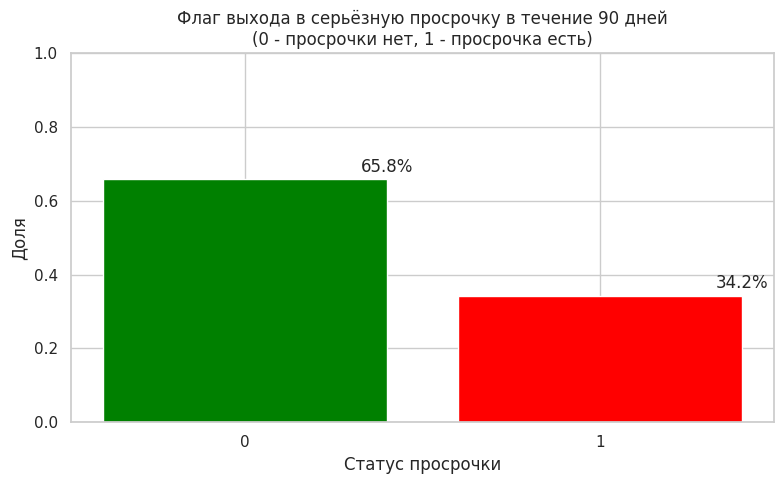

In [50]:
plt.figure(figsize=(8, 5))
bars = plt.bar(target_dist.index.astype(str), target_dist.values, color=['green', 'red'])
plt.title('Флаг выхода в серьёзную просрочку в течение 90 дней\n(0 - просрочки нет, 1 - просрочка есть)')
plt.xlabel('Статус просрочки')
plt.ylabel('Доля')
plt.ylim(0, 1)
for bar, value in zip(bars, target_dist.values):
    plt.text(bar.get_x() + bar.get_width(), bar.get_height() + 0.01, 
             f'{value:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Анализ пропусков в данных

In [59]:
na_rate1 = train.isna().mean().sort_values(ascending=False)
na_rate1.head(30)

days_until_first_overdue       0.286067
post_loan_collection_score     0.237053
internal_decision_code         0.211776
channel                        0.088933
loan_amount                    0.085697
region                         0.084155
loan_term_months               0.081227
marketing_segment              0.078607
dependents                     0.072441
application_date               0.072133
employment_type                0.071671
region_coefficient_extended    0.071054
age                            0.069205
education                      0.069051
monthly_income                 0.067972
incoming_amount                0.066739
siberia_northern_score         0.066584
hash_id                        0.064273
months_at_job                  0.059494
requested_product              0.058878
interest_rate                  0.057799
region_coefficient             0.054871
application_id                 0.000000
client_id                      0.000000
target                         0.000000


In [82]:
print("\nАнализ пропусков в данных:")

def analyze_missing(
    df: pd.DataFrame, 
    dataset_name: str
) -> pd.DataFrame:
    missing: pd.Series = df.isnull().sum()
    missing_pct: pd.Series = (missing / len(df)) * 100
    missing_df: pd.DataFrame = pd.DataFrame({
        'missing_count': missing,
        'missing_percent': missing_pct
    }).sort_values('missing_percent', ascending=False)
    
    missing_df: pd.DataFrame = missing_df[missing_df['missing_count'] > 0]
    
    print(f"\n{dataset_name} - колонки с пропусками ({len(missing_df)}):")
    if len(missing_df) > 0:
        display(missing_df.head(40))
        if len(missing_df) > 0:
            plt.figure(figsize=(12, 6))
            missing_df.head(40)['missing_percent'].plot(kind='barh', color='skyblue')
            plt.title(f'Топ-40 признаков по % пропусков в ({dataset_name})')
            plt.xlabel('Процент пропусков')
            plt.ylabel('Признаки')
            plt.tight_layout()
            plt.show()

            sample_df = df.sample(frac=1, random_state=42)
            plt.figure(figsize=(12, 6))
            sns.heatmap(sample_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
            plt.title('Heatmap пропусков (выборка 100%)')
            plt.show()
    else:
        print("Пропусков нет!")
    return missing_df


Анализ пропусков в данных:



Train - колонки с пропусками (22):


,missing_count,missing_percent
days_until_first_overdue,1856,28.606658
post_loan_collection_score,1538,23.705302
internal_decision_code,1374,21.177559
channel,577,8.893342
loan_amount,556,8.569667
region,546,8.415536
loan_term_months,527,8.122688
marketing_segment,510,7.860666
dependents,470,7.244143
application_date,468,7.213317


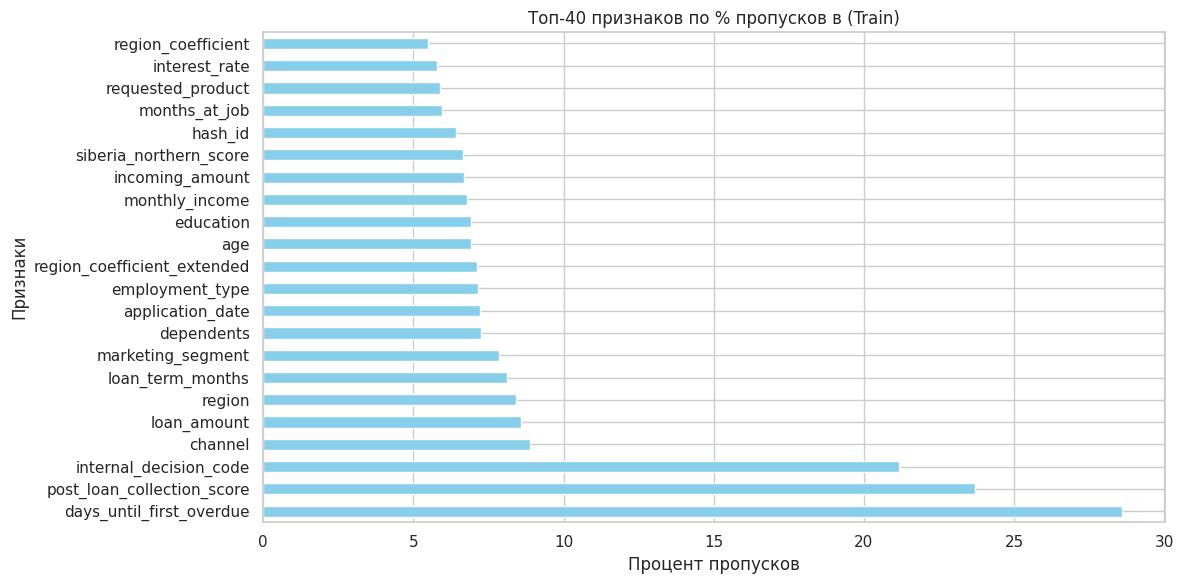

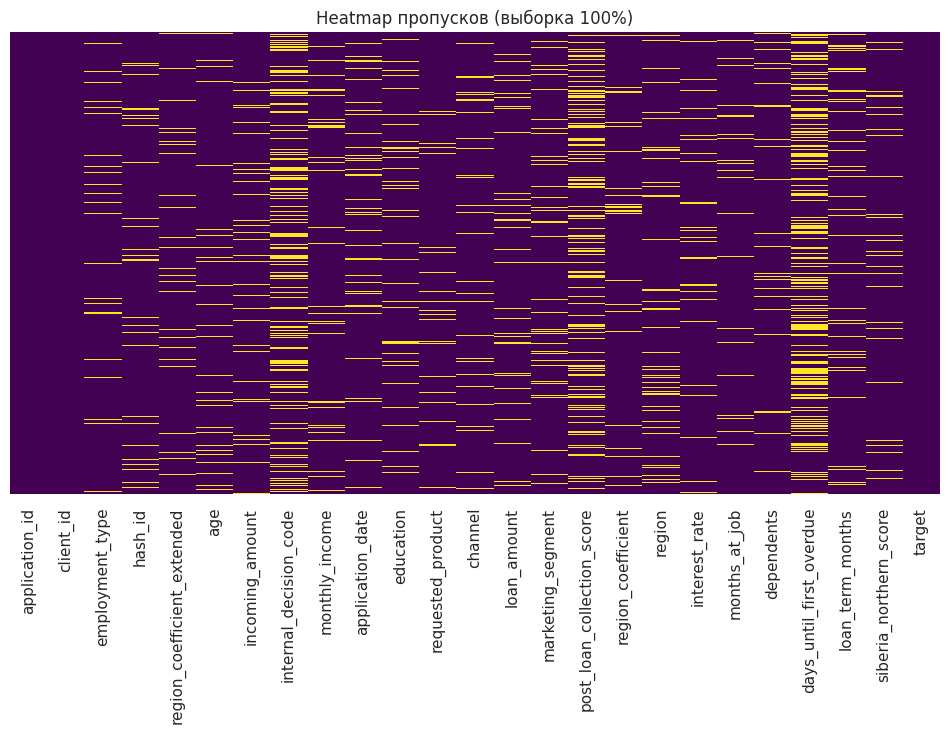

,missing_count,missing_percent
days_until_first_overdue,1856,28.606658
post_loan_collection_score,1538,23.705302
internal_decision_code,1374,21.177559
channel,577,8.893342
loan_amount,556,8.569667
region,546,8.415536
loan_term_months,527,8.122688
marketing_segment,510,7.860666
dependents,470,7.244143
application_date,468,7.213317


In [83]:
missing_train: pd.DataFrame = analyze_missing(train, 'Train')
missing_train


Test - колонки с пропусками (22):


,missing_count,missing_percent
post_loan_collection_score,2520,100.000000
internal_decision_code,2520,100.000000
days_until_first_overdue,2520,100.000000
monthly_income,236,9.365079
region,236,9.365079
hash_id,229,9.087302
region_coefficient_extended,206,8.174603
channel,205,8.134921
interest_rate,203,8.055556
incoming_amount,202,8.015873


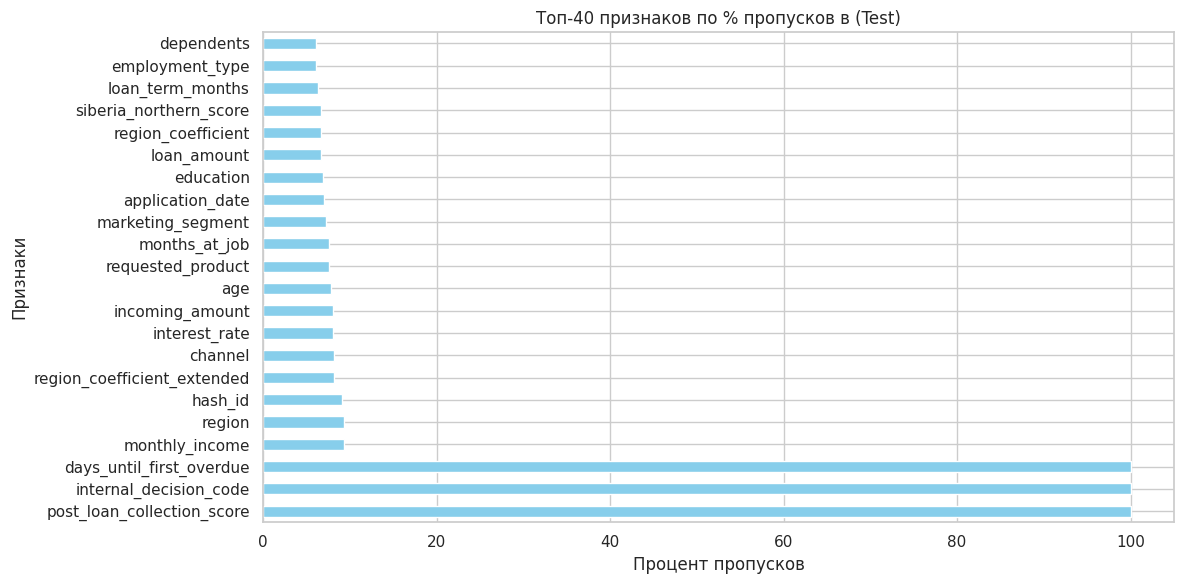

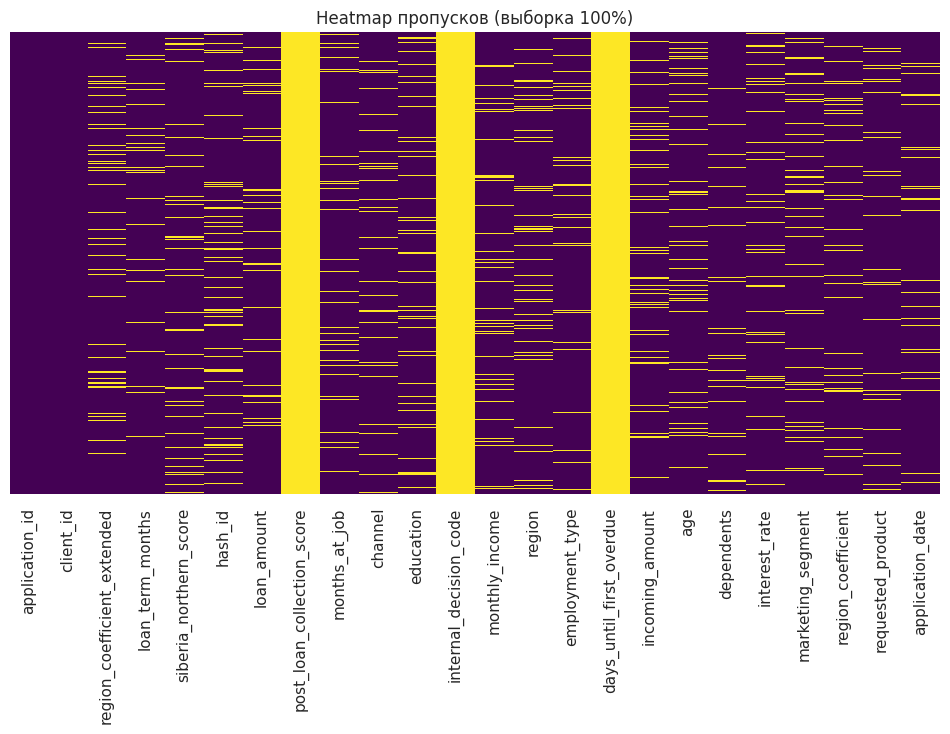

,missing_count,missing_percent
post_loan_collection_score,2520,100.000000
internal_decision_code,2520,100.000000
days_until_first_overdue,2520,100.000000
monthly_income,236,9.365079
region,236,9.365079
hash_id,229,9.087302
region_coefficient_extended,206,8.174603
channel,205,8.134921
interest_rate,203,8.055556
incoming_amount,202,8.015873


In [84]:
missing_test: pd.DataFrame = analyze_missing(test, 'Test')
missing_test


Bureau - колонки с пропусками (6):


,missing_count,missing_percent
bureau_status,1275,5.164243
max_dpd_last_12m,857,3.471181
account_type,837,3.390174
credit_limit,827,3.349670
opened_days_ago,652,2.640852
current_balance,480,1.944186


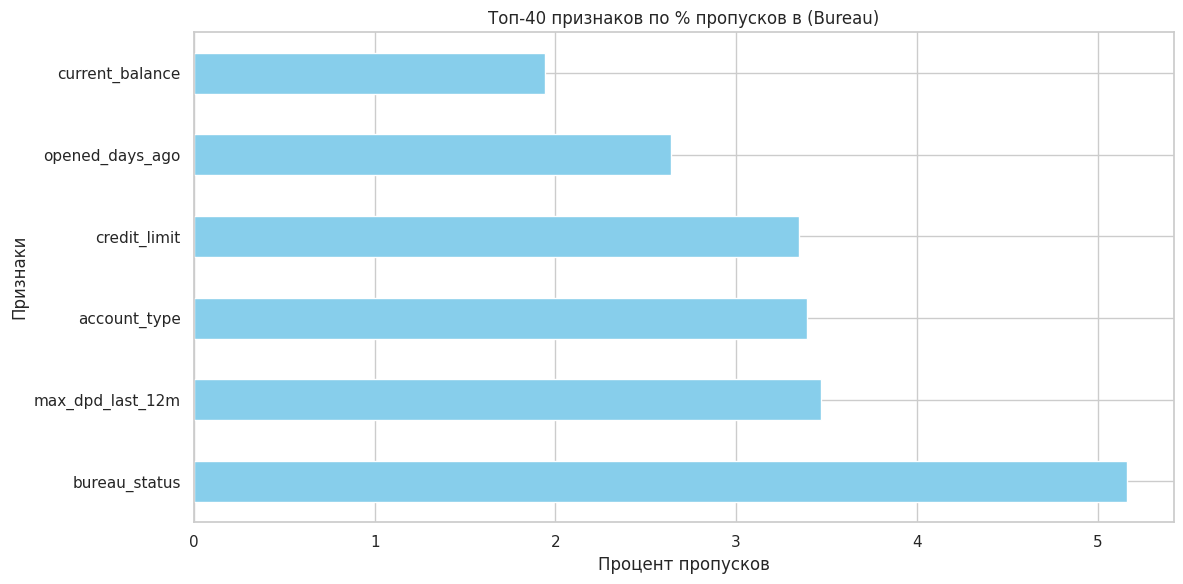

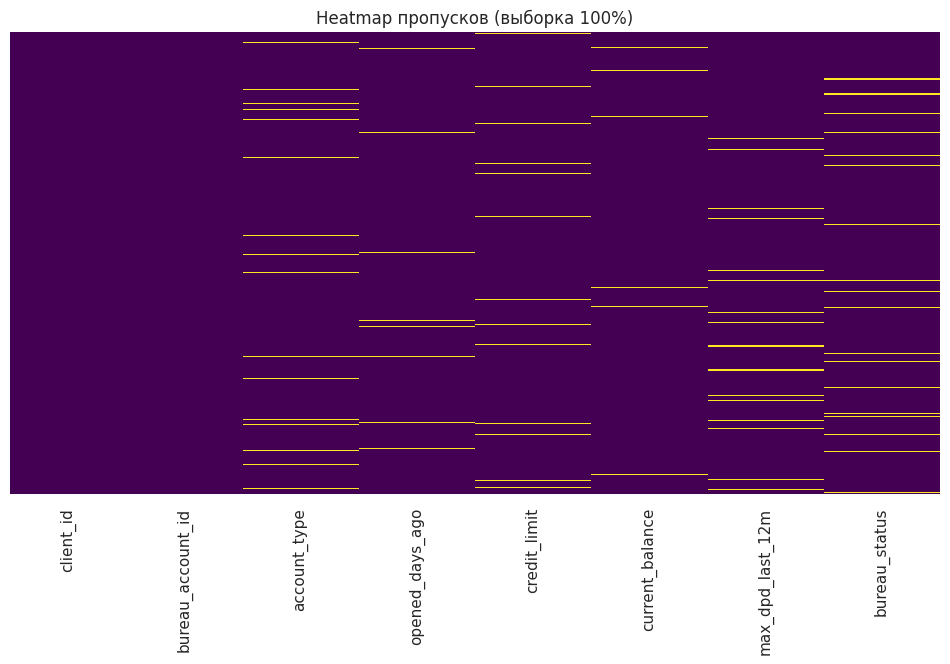

,missing_count,missing_percent
bureau_status,1275,5.164243
max_dpd_last_12m,857,3.471181
account_type,837,3.390174
credit_limit,827,3.349670
opened_days_ago,652,2.640852
current_balance,480,1.944186


In [85]:
missing_bureau: pd.DataFrame = analyze_missing(bureau, 'Bureau')
missing_bureau


Previous Loans - колонки с пропусками (5):


,missing_count,missing_percent
previous_term_months,645,5.054067
closed_days_ago,516,4.043253
max_overdue_days,444,3.479079
previous_amount,317,2.483937
was_overdue,266,2.084313


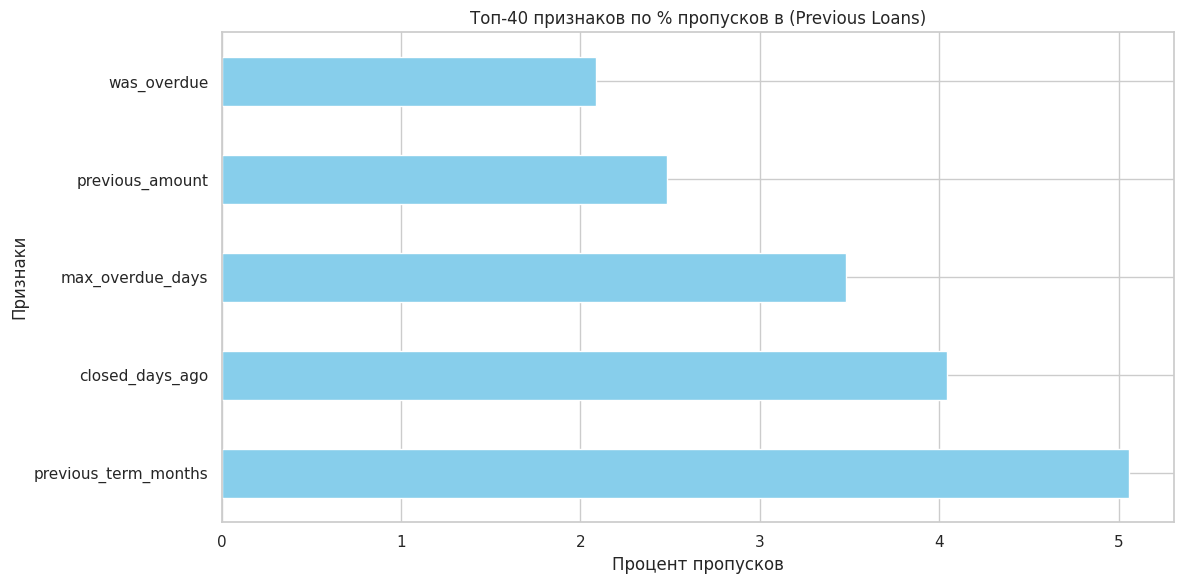

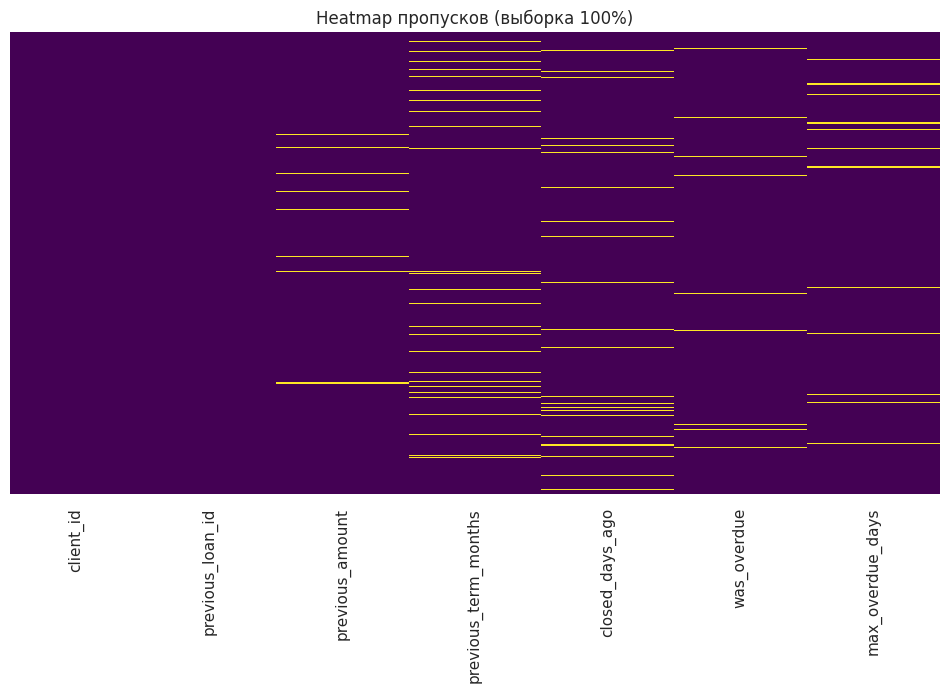

,missing_count,missing_percent
previous_term_months,645,5.054067
closed_days_ago,516,4.043253
max_overdue_days,444,3.479079
previous_amount,317,2.483937
was_overdue,266,2.084313


In [86]:
missing_previous_loans: pd.DataFrame = analyze_missing(previous_loans, 'Previous Loans')
missing_previous_loans


Transactions - колонки с пропусками (4):


,missing_count,missing_percent
transaction_category,17701,5.010190
merchant_risk_level,15015,4.249929
amount,11414,3.230682
transaction_date,10636,3.010473


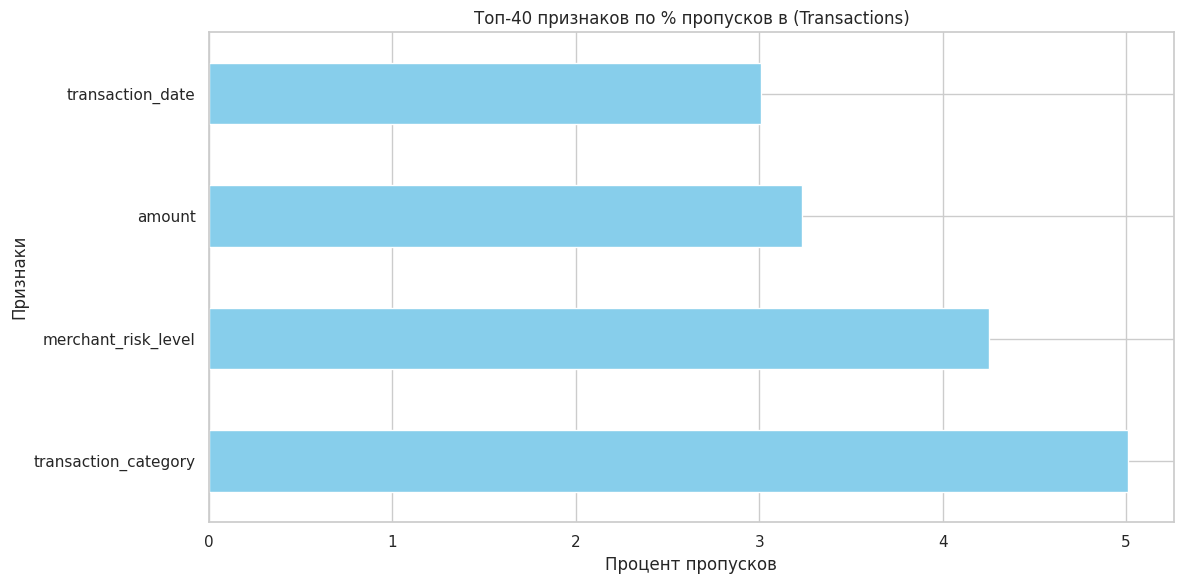

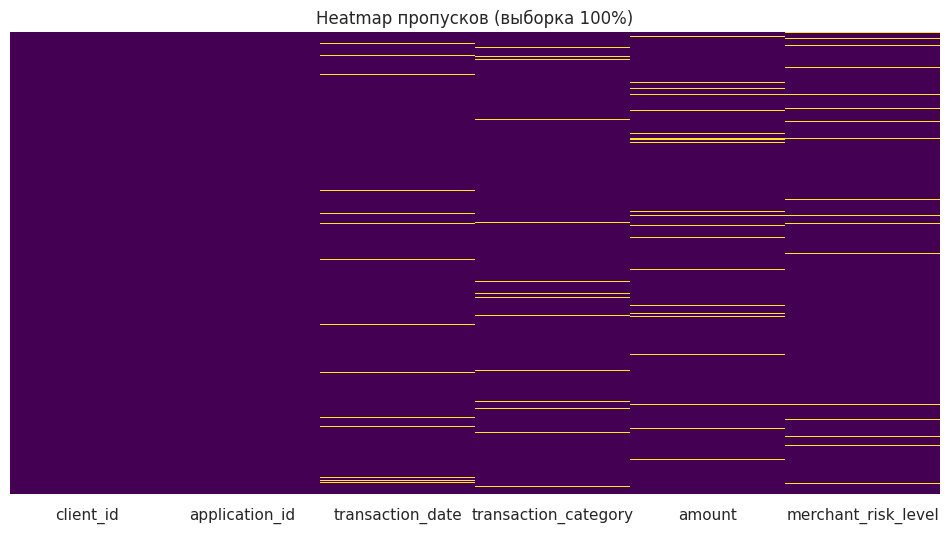

,missing_count,missing_percent
transaction_category,17701,5.010190
merchant_risk_level,15015,4.249929
amount,11414,3.230682
transaction_date,10636,3.010473


In [87]:
missing_transactions: pd.DataFrame = analyze_missing(transactions, 'Transactions')
missing_transactions

## Агрегация реляционных данных
Таблицы `bureau`, `previous_loans` и `transactions` имеют отношение **1-ко-многим** (один клиент -> несколько записей для клиента). 

**Решение:** агрегируем по `client_id`, создавая статистики (count, sum, max, mean) и доменные признаки:
- **Bureau:** утилизация кредитного лимита, флаг серьёзной просрочки (≥30 дней);
- **Previous Loans:** доля просроченных займов, флаг недавней просрочки (<365 дней);
- **Transactions:** доля азартных игр (gambling), стабильность зарплат, высокорисковые транзакции.

In [95]:
def aggregate_relational_data(
    train_df: pd.DataFrame, 
    test_df: pd.DataFrame, 
    bureau_df: pd.DataFrame, 
    prev_loans_df: pd.DataFrame, 
    tx_df: pd.DataFrame
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Агрегирует реляционные таблицы по client_id и сливает их с train/test.
    
    Args:
        train_df: тренировочный датасет
        test_df: тестовый датасет
        bureau_df: кредитная история из бюро
        prev_loans_df: прошлые займы клиента
        tx_df: транзакционная история
    
    Returns:
        Tuple[train_agg, test_agg]: агрегированные train и test
    """
    print("Начало агрегации реляционных данных...")
    
    # 1. Bureau (кредитная история)
    bureau_agg: pd.DataFrame = bureau_df.groupby('client_id').agg(
        bureau_accounts_count=('bureau_account_id', 'count'),
        total_credit_limit=('credit_limit', 'sum'),
        total_current_balance=('current_balance', 'sum'),
        max_dpd_last_12m=('max_dpd_last_12m', 'max'),
        active_accounts_count=('bureau_status', lambda x: (x == 'active').sum()),
    ).reset_index()
    bureau_agg['credit_utilization_ratio'] = bureau_agg['total_current_balance'] / (bureau_agg['total_credit_limit'] + 1e-5)
    bureau_agg['severe_overdue_flag'] = (bureau_agg['max_dpd_last_12m'].fillna(0) >= 30).astype(int)
    
    # 2. Previous Loans (прошлые займы)
    prev_agg: pd.DataFrame = prev_loans_df.groupby('client_id').agg(
        prev_loans_count=('previous_loan_id', 'count'),
        total_prev_amount=('previous_amount', 'sum'),
        max_overdue_days=('max_overdue_days', 'max'),
        was_overdue_count=('was_overdue', 'sum'),
        closed_days_ago=('closed_days_ago', 'min'),
    ).reset_index()
    prev_agg['was_overdue_ratio'] = prev_agg['was_overdue_count'] / (prev_agg['prev_loans_count'] + 1e-5)
    prev_agg['recent_overdue_flag'] = (
        (prev_agg['was_overdue_count'] > 0) & 
        (prev_agg['closed_days_ago'].fillna(9999) < 365)
    ).astype(int)
    
    # 3. Transactions (транзакционная история)
    tx_df['transaction_date'] = pd.to_datetime(tx_df['transaction_date'], errors='coerce')
    ref_date: pd.Timestamp = pd.to_datetime('2025-12-31')
    tx_df['days_since_tx'] = (ref_date - tx_df['transaction_date']).dt.days
    
    tx_agg: pd.DataFrame = tx_df.groupby('client_id').agg(
        tx_count=('transaction_date', 'count'),
        net_tx_amount=('amount', 'sum'),
        total_tx_turnover=('amount', lambda x: x.abs().sum()),
        days_since_last_tx=('days_since_tx', 'min')
    ).reset_index()
    
    # Азартные игры (gambling) (фактор дефолта)
    gambling_df: pd.DataFrame = tx_df[tx_df['transaction_category'] == 'gambling']
    gambling_agg: pd.DataFrame = gambling_df.groupby('client_id').agg(
        gambling_count=('transaction_category', 'count'),
        gambling_amount=('amount', lambda x: x.abs().sum()),
        gambling_max_risk=('merchant_risk_level', 'max')
    ).reset_index()
    
    # Зарплаты (salary) (показатель стабильности дохода)
    salary_df: pd.DataFrame = tx_df[tx_df['transaction_category'] == 'salary']
    salary_agg: pd.DataFrame = salary_df.groupby('client_id').agg(
        salary_count=('transaction_category', 'count'),
        avg_salary=('amount', 'mean'),
        days_since_last_salary=('days_since_tx', 'min')
    ).reset_index()
    
    # Высокий риск (merchant_risk_level >= 4)
    high_risk_df: pd.DataFrame = tx_df[tx_df['merchant_risk_level'] >= 4]
    high_risk_agg: pd.DataFrame = high_risk_df.groupby('client_id').agg(
        high_risk_count=('transaction_category', 'count')
    ).reset_index()

    # Объединяем все транзакционные агрегации
    tx_agg = tx_agg.merge(gambling_agg, on='client_id', how='left')
    tx_agg = tx_agg.merge(salary_agg, on='client_id', how='left')
    tx_agg = tx_agg.merge(high_risk_agg, on='client_id', how='left')
    
    # Заполняем пропуски нулями (отсутсвие транзакций - 0)
    fill_zero_cols: List[str] = ['gambling_count', 'gambling_amount', 'salary_count', 'high_risk_count',
                      'gambling_max_risk', 'avg_salary', 'days_since_last_salary']
    for col in fill_zero_cols:
        if col in tx_agg.columns:
            tx_agg[col] = tx_agg[col].fillna(0)
            
    tx_agg['gambling_to_turnover_ratio'] = tx_agg['gambling_amount'] / (tx_agg['total_tx_turnover'] + 1e-5)
    
    # 4. Слияние
    result_dfs: List[pd.DataFrame] = []
    for df in [train_df, test_df]:
        df_merged: pd.DataFrame = df.copy()
        df_merged = df_merged.merge(bureau_agg, on='client_id', how='left')
        df_merged = df_merged.merge(prev_agg, on='client_id', how='left')
        df_merged = df_merged.merge(tx_agg, on='client_id', how='left')
        result_dfs.append(df_merged)
        
    print("Агрегация завершена (с расширенными транзакциями и флагами).")
    return result_dfs[0], result_dfs[1]

train_agg, test_agg = aggregate_relational_data(train, test, bureau, previous_loans, transactions)

Начало агрегации реляционных данных...


Агрегация завершена (с расширенными транзакциями и флагами).


In [96]:
train_agg

,application_id,client_id,employment_type,hash_id,region_coefficient_extended,age,incoming_amount,internal_decision_code,monthly_income,application_date,...,total_tx_turnover,days_since_last_tx,gambling_count,gambling_amount,gambling_max_risk,salary_count,avg_salary,days_since_last_salary,high_risk_count,gambling_to_turnover_ratio
0,107941,7941,employee,61441390.0,1.0,37.0,30401.28,NaN,30401.28,2025-08-11,...,97084.50,147.0,1.0,5582.08,1.0,2.0,7468.340000,207.0,6.0,0.057497
1,101163,1163,employee,67321556.0,0.0,60.0,26024.64,manual_review_bad,26024.64,2025-12-29,...,89650.77,4.0,0.0,0.00,0.0,2.0,13623.675000,70.0,6.0,0.000000
2,100583,583,contractor,26719968.0,0.0,37.0,21389.83,vip,21389.83,2025-11-09,...,41186.19,66.0,0.0,0.00,0.0,1.0,3951.390000,0.0,6.0,0.000000
3,104082,4082,NaN,45184358.0,0.0,NaN,31617.26,approved_auto,NaN,2025-02-23,...,196388.22,319.0,0.0,0.00,0.0,6.0,18155.436667,322.0,3.0,0.000000
4,108413,8413,employee,58267524.0,0.0,60.0,18000.00,approved_auto,18000.00,2025-12-07,...,42203.98,25.0,1.0,872.48,1.0,1.0,3257.700000,63.0,4.0,0.020673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6483,101662,1662,contractor,NaN,0.0,26.0,NaN,NaN,21480.58,2025-05-13,...,56850.19,239.0,1.0,420.63,1.0,2.0,7331.750000,281.0,7.0,0.007399
6484,103037,3037,employee,84416127.0,0.0,56.0,28198.35,manual_review_bad,28198.35,2025-07-05,...,254545.72,183.0,1.0,1344.82,5.0,8.0,21312.978750,187.0,9.0,0.005283
6485,108868,8868,contractor,31058252.0,0.0,50.0,40575.25,vip,40575.25,2025-05-03,...,183951.85,252.0,2.0,9564.78,1.0,4.0,15972.302500,294.0,7.0,0.051996
6486,102303,2303,employee,82787744.0,0.0,56.0,24783.06,approved_manual,24783.06,2025-05-18,...,110411.46,247.0,0.0,0.00,0.0,5.0,15350.300000,247.0,4.0,0.000000


In [97]:
test_agg

,application_id,client_id,region_coefficient_extended,loan_term_months,siberia_northern_score,hash_id,loan_amount,post_loan_collection_score,months_at_job,channel,...,total_tx_turnover,days_since_last_tx,gambling_count,gambling_amount,gambling_max_risk,salary_count,avg_salary,days_since_last_salary,high_risk_count,gambling_to_turnover_ratio
0,102531,2531,0.0,18.0,NaN,NaN,73071.51,NaN,38.0,call_center,...,90628.29,260.0,1.0,1008.84,4.0,3.0,14107.553333,341.0,5.0,0.011132
1,107213,7213,0.0,12.0,0.317813,30012008.0,65408.73,NaN,23.0,partner,...,76890.02,241.0,2.0,2242.59,1.0,4.0,7672.785000,253.0,6.0,0.029166
2,100238,238,0.0,36.0,0.902039,92419982.0,NaN,NaN,12.0,office,...,279895.93,310.0,1.0,2862.30,5.0,7.0,20907.485000,310.0,5.0,0.010226
3,104918,4918,0.0,6.0,0.737848,76137566.0,NaN,NaN,179.0,web,...,108780.83,29.0,1.0,4169.87,4.0,2.0,7796.135000,44.0,10.0,0.038333
4,106480,6480,0.0,12.0,0.746599,21845266.0,76253.20,NaN,153.0,mobile,...,453586.91,244.0,2.0,22460.38,1.0,5.0,43834.826000,257.0,5.0,0.049517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,105735,5735,0.0,24.0,0.496285,17047133.0,95337.81,NaN,200.0,mobile,...,235015.21,92.0,1.0,1077.36,1.0,7.0,17327.592857,92.0,7.0,0.004584
2516,105192,5192,0.0,9.0,0.940226,77377804.0,NaN,NaN,206.0,web,...,187547.48,354.0,4.0,8643.25,4.0,4.0,13893.697500,361.0,11.0,0.046086
2517,105391,5391,0.0,36.0,0.765447,NaN,63097.47,NaN,48.0,partner,...,150577.97,84.0,0.0,0.00,0.0,8.0,8603.968750,97.0,9.0,0.000000
2518,100861,861,0.0,12.0,0.826164,87976929.0,148171.13,NaN,90.0,call_center,...,120504.49,228.0,2.0,6742.81,4.0,5.0,11125.540000,247.0,8.0,0.055955


In [99]:
if train_agg.isna().any().any():
    cols_with_na: List[str] = train_agg.columns[train_agg.isna().any()].tolist()
    print(f"Столбцы с пропусками ({len(cols_with_na)}): {cols_with_na}")
    
    # Детальная информация
    na_info: pd.Series = train_agg.isna().sum()
    na_info = na_info[na_info > 0]
    print("\nДетальная информация о пропусках:")
    for col, count in na_info.items():
        percentage = (count / len(train_agg)) * 100
        print(f"{col}: {count} пропусков ({percentage:.4f}%)")

Столбцы с пропусками (36): ['employment_type', 'hash_id', 'region_coefficient_extended', 'age', 'incoming_amount', 'internal_decision_code', 'monthly_income', 'application_date', 'education', 'requested_product', 'channel', 'loan_amount', 'marketing_segment', 'post_loan_collection_score', 'region_coefficient', 'region', 'interest_rate', 'months_at_job', 'dependents', 'days_until_first_overdue', 'loan_term_months', 'siberia_northern_score', 'bureau_accounts_count', 'total_credit_limit', 'total_current_balance', 'max_dpd_last_12m', 'active_accounts_count', 'credit_utilization_ratio', 'severe_overdue_flag', 'prev_loans_count', 'total_prev_amount', 'max_overdue_days', 'was_overdue_count', 'closed_days_ago', 'was_overdue_ratio', 'recent_overdue_flag']

Детальная информация о пропусках:
employment_type: 465 пропусков (7.1671%)
hash_id: 417 пропусков (6.4273%)
region_coefficient_extended: 461 пропусков (7.1054%)
age: 449 пропусков (6.9205%)
incoming_amount: 433 пропусков (6.6739%)
internal_de

In [100]:
if test_agg.isna().any().any():
    cols_with_na: List[str] = test_agg.columns[test_agg.isna().any()].tolist()
    print(f"Столбцы с пропусками ({len(cols_with_na)}): {cols_with_na}")
    
    # Детальная информация
    na_info: pd.Series = test_agg.isna().sum()
    na_info = na_info[na_info > 0]
    print("\nДетальная информация о пропусках:")
    for col, count in na_info.items():
        percentage = (count / len(test_agg)) * 100
        print(f"{col}: {count} пропусков ({percentage:.4f}%)")

Столбцы с пропусками (36): ['region_coefficient_extended', 'loan_term_months', 'siberia_northern_score', 'hash_id', 'loan_amount', 'post_loan_collection_score', 'months_at_job', 'channel', 'education', 'internal_decision_code', 'monthly_income', 'region', 'employment_type', 'days_until_first_overdue', 'incoming_amount', 'age', 'dependents', 'interest_rate', 'marketing_segment', 'region_coefficient', 'requested_product', 'application_date', 'bureau_accounts_count', 'total_credit_limit', 'total_current_balance', 'max_dpd_last_12m', 'active_accounts_count', 'credit_utilization_ratio', 'severe_overdue_flag', 'prev_loans_count', 'total_prev_amount', 'max_overdue_days', 'was_overdue_count', 'closed_days_ago', 'was_overdue_ratio', 'recent_overdue_flag']

Детальная информация о пропусках:
region_coefficient_extended: 206 пропусков (8.1746%)
loan_term_months: 160 пропусков (6.3492%)
siberia_northern_score: 168 пропусков (6.6667%)
hash_id: 229 пропусков (9.0873%)
loan_amount: 169 пропусков (6.70

## Генерация новых признаков (Feature Engineering)

После агрегации реляционных данных мы создаем новые производные признаки. Это позволяет модели лучше улавливать нелинейные зависимости, оценивать комплексные отношения между переменными и снижать влияние статистических выбросов.

### 1. Финансовая нагрузка и платежеспособность
* **`loan_to_income_ratio`** - отношение суммы займа к годовому доходу. Показывает, насколько велика сумма займа относительно дохода клиента, что напрямую влияет на вероятность дефолта.
* **`payment_to_income_ratio`** - доля ежемесячного платежа в доходе (аналог банковского DTI, Debt-to-Income). Ключевой индикатор долговой нагрузки.
* **`free_income`** и **`free_income_ratio`** - свободный доход и его доля после вычета ежемесячного платежа. Показывает финансовую "подушку безопасности" заемщика.
* **`total_debt_to_income`** - общая долговая нагрузка, включающая как текущий запрос, так и непогашенные остатки по бюро.
* **`income_per_dependent`** - доход на одного иждивенца. Учитывает семейную нагрузку при оценке платежеспособности.

### 2. Логарифмирование (борьба с выбросами)
* **`log_loan_amount`**, **`log_monthly_income`**, **`log_total_credit_limit`** - логарифмы основных финансовых величин. Финансовые данные имеют "тяжелые хвосты" (экстремальные выбросы), и логарифмирование (`log1p`) стабилизирует дисперсию, помогая деревьям строить более качественные разбиения.
* **`log_prev_amount`**, **`log_max_overdue`** - логарифмы исторических сумм займов и максимальных просрочек.

### 3. Поведенческие паттерны и транзакции
* **`is_gambler`** и **`gambling_severity`** - бинарный флаг наличия трат на азартные игры и комплексная оценка их тяжести. Один из сильнейших предикторов будущего дефолта.
* **`salary_stability`** и **`has_salary`** - регулярность и сам факт наличия зарплатных поступлений. Показывает стабильность источника дохода.
* **`bad_tx_ratio`** - доля высокорисковых транзакций (уровень риска мерчанта ≥ 4) в общем числе операций.
* **`gambling_to_turnover_ratio`** - доля азартных трат в общем транзакционном обороте клиента.

### 4. Кредитная история и данные бюро
* **`has_overdue_history`** - бинарный флаг наличия любой просрочки за последние 12 месяцев.
* **`bureau_debt_ratio`** - коэффициент утилизации кредитного лимита (текущий баланс / общий лимит). Значения, близкие к 1, говорят о высокой закредитованности.
* **`active_bureau_ratio`** - доля активных кредитных счетов от общего числа.
* **`overdue_severity`** - комплексная метрика тяжести прошлых просрочек (максимальные дни просрочки × количество фактов просрочки).
* **`debt_per_account`** - средняя сумма долга на один активный счет в бюро.

### 5. Демографические и employment-флаги
* **`is_high_risk_employment`** - флаг нестабильной занятости (самозанятый, безработный, контрактник).
* **`is_young`** / **`is_senior`** - возрастные группы риска (до 25 лет и старше 60 лет).
* **`is_new_employee`** - стаж на текущем месте работы менее 12 месяцев (период испытательного срока или адаптации).
* **`is_short_term_loan`** - флаг краткосрочного займа (≤ 12 месяцев), который часто ассоциируется с микрофинансированием и высоким риском.

### 6. Региональные скоринговые признаки
* **`region_risk`** и **`loan_to_region_risk`** - учет регионального коэффициента и его отношения к сумме займа, что позволяет нивелировать географические различия в уровне жизни и рисках.

In [101]:
def create_new_features_v2(df: pd.DataFrame) -> pd.DataFrame:
    """
    Создаёт доменные признаки для кредитного скоринга.
    
    Args:
        df: входной датасет с агрегированными признаками
    
    Returns:
        df: датасет с новыми признаками
    """
    df = df.copy()
    eps: float = 1e-6

    # ==========================================
    # 1. Базовая обработка и финансовые отношения
    # ==========================================
    df['monthly_income_safe'] = df['monthly_income'].fillna(df['monthly_income'].median())
    
    df['loan_to_income_ratio'] = df['loan_amount'] / (df['monthly_income_safe'] * 12 + eps)
    df['estimated_monthly_payment'] = df['loan_amount'] / (df['loan_term_months'].fillna(12) + eps)
    df['payment_to_income_ratio'] = df['estimated_monthly_payment'] / (df['monthly_income_safe'] + eps)
    
    # ==========================================
    # 2. Логарифмирование (сглаживание выбросов)
    # ==========================================
    df['log_loan_amount'] = np.log1p(df['loan_amount'].fillna(0))
    df['log_monthly_income'] = np.log1p(df['monthly_income_safe'])
    df['log_total_credit_limit'] = np.log1p(df['total_credit_limit'].fillna(0) + 1)
    df['log_prev_amount'] = np.log1p(df['total_prev_amount'].fillna(0))
    df['log_max_overdue'] = np.log1p(df['max_overdue_days'].fillna(0))
    
    # ==========================================
    # 3. Риски из бюро и истории
    # ==========================================
    df['has_overdue_history'] = (df['max_dpd_last_12m'].fillna(0) > 0).astype(int)
    df['bureau_debt_ratio'] = df['total_current_balance'].fillna(0) / (df['total_credit_limit'].fillna(1) + eps)
    df['active_bureau_ratio'] = df['active_accounts_count'].fillna(0) / (df['bureau_accounts_count'].fillna(1) + eps)
    df['debt_per_account'] = df['total_current_balance'].fillna(0) / (df['bureau_accounts_count'].fillna(1) + eps)
    df['overdue_severity'] = df['max_overdue_days'].fillna(0) * df['was_overdue_count'].fillna(0)
    df['overdue_income_ratio'] = df['max_dpd_last_12m'].fillna(0) / (df['log_monthly_income'] + eps)
    
    # ==========================================
    # 4. Поведенческие паттерны и транзакции
    # ==========================================
    df['tx_turnover_to_income'] = df['total_tx_turnover'].fillna(0) / (df['monthly_income_safe'] * 12 + eps)
    df['bad_tx_ratio'] = (df['gambling_count'].fillna(0) + df['high_risk_count'].fillna(0)) / (df['tx_count'].fillna(1) + eps)
    df['salary_stability'] = df['salary_count'].fillna(0) / (df['tx_count'].fillna(1) + eps)
    df['has_salary'] = (df['salary_count'].fillna(0) > 0).astype(int)
    
    df['is_gambler'] = (df['gambling_count'].fillna(0) > 0).astype(int)
    df['gambling_severity'] = df['gambling_count'].fillna(0) * df['gambling_max_risk'].fillna(0)
    df['gambling_to_turnover_ratio'] = df['gambling_amount'].fillna(0) / (df['total_tx_turnover'].fillna(0) + eps)
    
    df['recent_activity_flag'] = (df['days_since_last_tx'].fillna(999) < 30).astype(int)
    df['long_history_flag'] = (df['days_since_last_tx'].fillna(0) > 365).astype(int)
    df['loan_to_salary_ratio'] = df['loan_amount'].fillna(0) / (df['avg_salary'].fillna(1) + eps)
    
    # ==========================================
    # 5. Долговая нагрузка и демография
    # ==========================================
    df['free_income'] = df['monthly_income_safe'] - df['estimated_monthly_payment']
    df['free_income_ratio'] = df['free_income'] / (df['monthly_income_safe'] + eps)
    
    df['total_debt'] = df['total_current_balance'].fillna(0) + df['loan_amount'].fillna(0)
    df['total_debt_to_income'] = df['total_debt'] / (df['monthly_income_safe'] * 12 + eps)
    
    df['dependents'] = df['dependents'].fillna(0)
    df['income_per_dependent'] = df['monthly_income_safe'] / (df['dependents'] + 1)
    
    # Флаги
    df['is_high_risk_employment'] = df['employment_type'].isin(
        ['unemployed', 'contractor', 'self_employed', 'business']
    ).astype(int)
    df['is_short_term_loan'] = (df['loan_term_months'].fillna(12) <= 12).astype(int)
    df['is_young'] = (df['age'].fillna(35) < 25).astype(int)
    df['is_senior'] = (df['age'].fillna(35) > 60).astype(int)
    df['is_new_employee'] = (df['months_at_job'].fillna(0) < 12).astype(int)
    
    # ==========================================
    # 6. Региональные признаки
    # ==========================================
    if 'region_coefficient' in df.columns:
        df['region_risk'] = df['region_coefficient'].fillna(0)
        df['loan_to_region_risk'] = df['loan_amount'].fillna(0) / (df['region_coefficient'].fillna(1) + eps)
    
    # 7. Специфичный скоринговый признак (если присутствует в данных)
    if 'siberia_northern_score' in df.columns:
        df['log_siberia_score'] = np.log1p(df['siberia_northern_score'].fillna(0))

    df['age_income_interaction'] = df['age'].fillna(35) * df['log_monthly_income']
    
    return df

In [102]:
def add_kfold_target_encoding(
    train_df: pd.DataFrame, 
    test_df: pd.DataFrame, 
    cat_cols: List[str], 
    target_col: str = 'target', 
    n_splits: int = 5
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Безопасный Target Encoding с использованием K-Fold (без утечки данных).
    
    Для каждой категории вычисляем среднее значение target на обучающем фолде
    и применяем к валидационному. Это предотвращает data leakage.
    
    Args:
        train_df: тренировочный датасет
        test_df: тестовый датасет
        cat_cols: список категориальных колонок для кодирования
        target_col: имя целевой переменной
        n_splits: количество фолдов
    
    Returns:
        Tuple[train_df, test_df]: датасеты с новыми закодированными признаками
    """
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    global_mean: float = train_df[target_col].mean()
    kf: KFold = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    
    for col in cat_cols:
        train_df[f'{col}_target_enc'] = np.nan
        test_df[f'{col}_target_enc'] = global_mean 
        
        for train_idx, val_idx in kf.split(train_df):
            X_train_fold: pd.DataFrame = train_df.iloc[train_idx]
            X_val_fold: pd.DataFrame = train_df.iloc[val_idx]
            
            enc_map: pd.Series = X_train_fold.groupby(col)[target_col].mean()
            train_df.loc[val_idx, f'{col}_target_enc'] = X_val_fold[col].map(enc_map)
            
        train_df[f'{col}_target_enc'] = train_df[f'{col}_target_enc'].fillna(global_mean)
        
        test_enc_map: pd.Series = train_df.groupby(col)[target_col].mean()
        test_df[f'{col}_target_enc'] = test_df[col].map(test_enc_map).fillna(global_mean)
        
    return train_df, test_df

In [103]:
cat_cols_to_encode: List[str] = ['employment_type', 'region', 'education', 'requested_product', 'channel']
train_fe, test_fe = add_kfold_target_encoding(train_agg, test_agg, cat_cols_to_encode, target_col='target')

train_fe = create_new_features_v2(train_fe)
test_fe = create_new_features_v2(test_fe)
print("✅ Улучшенный Feature Engineering завершен")

✅ Улучшенный Feature Engineering завершен


### Визуальный анализ трансформации признаков

Финансовые данные (сумма займа, доход) часто имеют сильную правостороннюю асимметрию (heavy-tailed distribution). Наличие экстремальных выбросов может негативно влиять на работу градиентного бустинга, заставляя деревья строить неоптимальные разбиения. 

Ниже показано сравнение исходных распределений и распределений после логарифмирования (`log1p`). Также мы оцениваем, насколько новый признак `loan_to_income_ratio` разделяет классы дефолта и нормы.

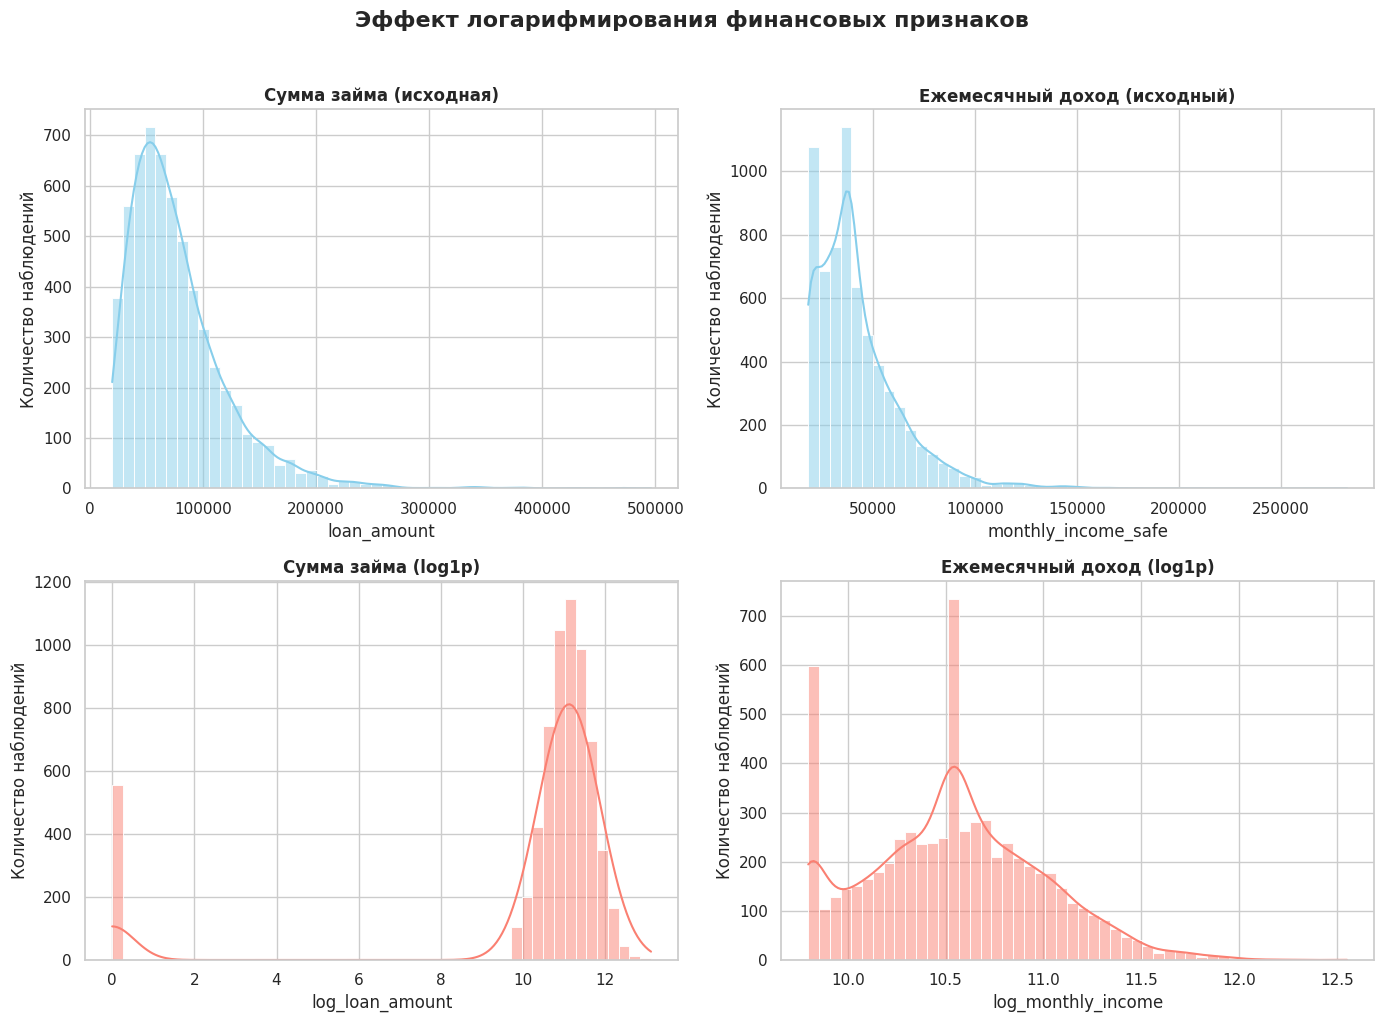

In [ ]:
sns.set_style("whitegrid")

# Признаки для сравнения
raw_features: List[str] = ['loan_amount', 'monthly_income_safe']
log_features: List[str] = ['log_loan_amount', 'log_monthly_income']
titles_raw: List[str] = ['Сумма займа (исходная)', 'Ежемесячный доход (исходный)']
titles_log = ['Сумма займа (log1p)', 'Ежемесячный доход (log1p)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Верхний ряд: Исходные данные
for i, feature in enumerate(raw_features):
    ax = axes[0, i]
    sns.histplot(train_fe[feature].dropna(), bins=50, kde=True, ax=ax, color='skyblue')
    ax.set_title(titles_raw[i], fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Количество наблюдений')

# Нижний ряд: Логарифмированные данные
for i, feature in enumerate(log_features):
    ax = axes[1, i]
    sns.histplot(train_fe[feature].dropna(), bins=50, kde=True, ax=ax, color='salmon')
    ax.set_title(titles_log[i], fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Количество наблюдений')

plt.suptitle('Эффект логарифмирования финансовых признаков', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Распределение нового признака по классам (Target Split)

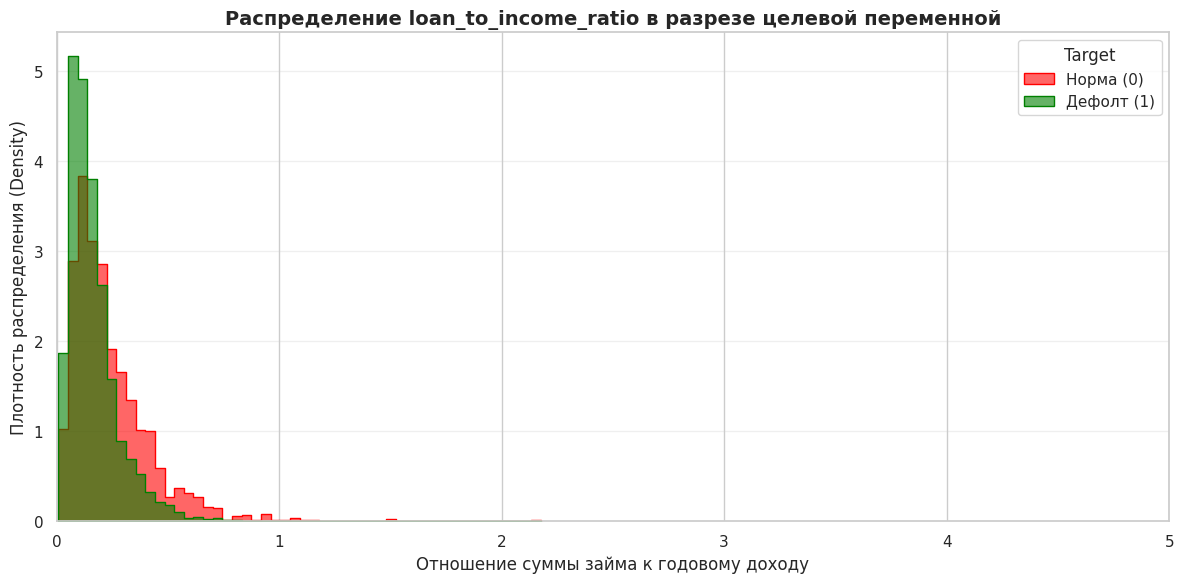

💡 Вывод: Клиенты без дефолта (target=0) имеют более смещенное вправо распределение loan_to_income_ratio.
   Клиенты БЕЗ дефолта имеют более высокую долговую нагрузку (большие значения loan_to_income_ratio), а клиенты С дефолтом — более низкую.


In [110]:
plt.figure(figsize=(12, 6))

# Визуализируем отношение займа к доходу в разрезе целевой переменной
feature_to_plot = 'loan_to_income_ratio'

sns.histplot(
    data=train_fe, 
    x=feature_to_plot, 
    hue='target', 
    element="step", 
    stat="density", 
    common_norm=False, 
    palette={0: "green", 1: "red"},
    alpha=0.6,
    bins=50
)

plt.title(f'Распределение {feature_to_plot} в разрезе целевой переменной', fontweight='bold', fontsize=14)
plt.xlabel('Отношение суммы займа к годовому доходу')
plt.ylabel('Плотность распределения (Density)')
plt.xlim(0, 5)
plt.legend(title='Target', labels=['Норма (0)', 'Дефолт (1)'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"💡 Вывод: Клиенты без дефолта (target=0) имеют более смещенное вправо распределение {feature_to_plot}.")
print("   Клиенты БЕЗ дефолта имеют более высокую долговую нагрузку (большие значения loan_to_income_ratio), а клиенты С дефолтом — более низкую.")

### Анализ поведенческого флага (Gambling)

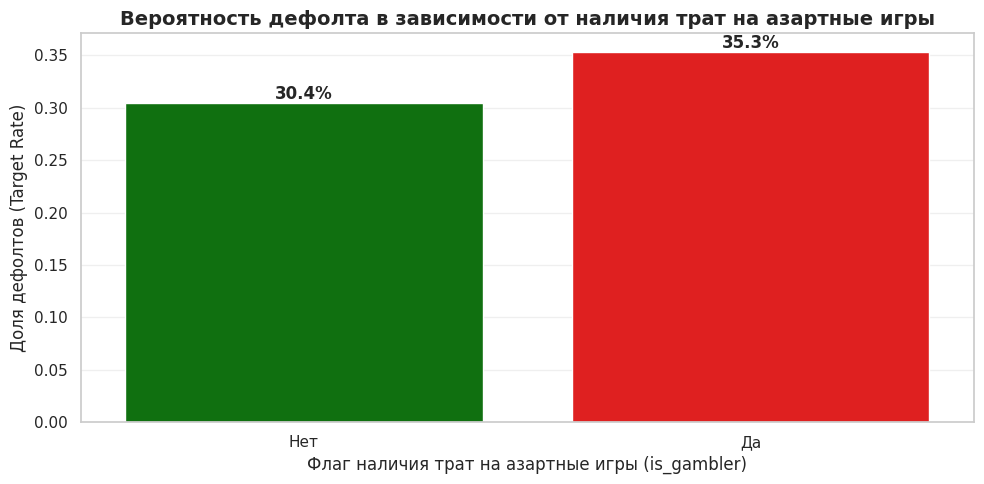

In [106]:
plt.figure(figsize=(10, 5))

# Доля дефолтов в зависимости от наличия трат на азартные игры
sns.barplot(
    x='is_gambler', 
    y='target', 
    data=train_fe, 
    errorbar=None, 
    palette=['green', 'red']
)

plt.title('Вероятность дефолта в зависимости от наличия трат на азартные игры', fontweight='bold', fontsize=14)
plt.xlabel('Флаг наличия трат на азартные игры (is_gambler)')
plt.ylabel('Доля дефолтов (Target Rate)')
plt.xticks([0, 1], ['Нет', 'Да'])

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1%}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Рассмотрим категориальные признаки.

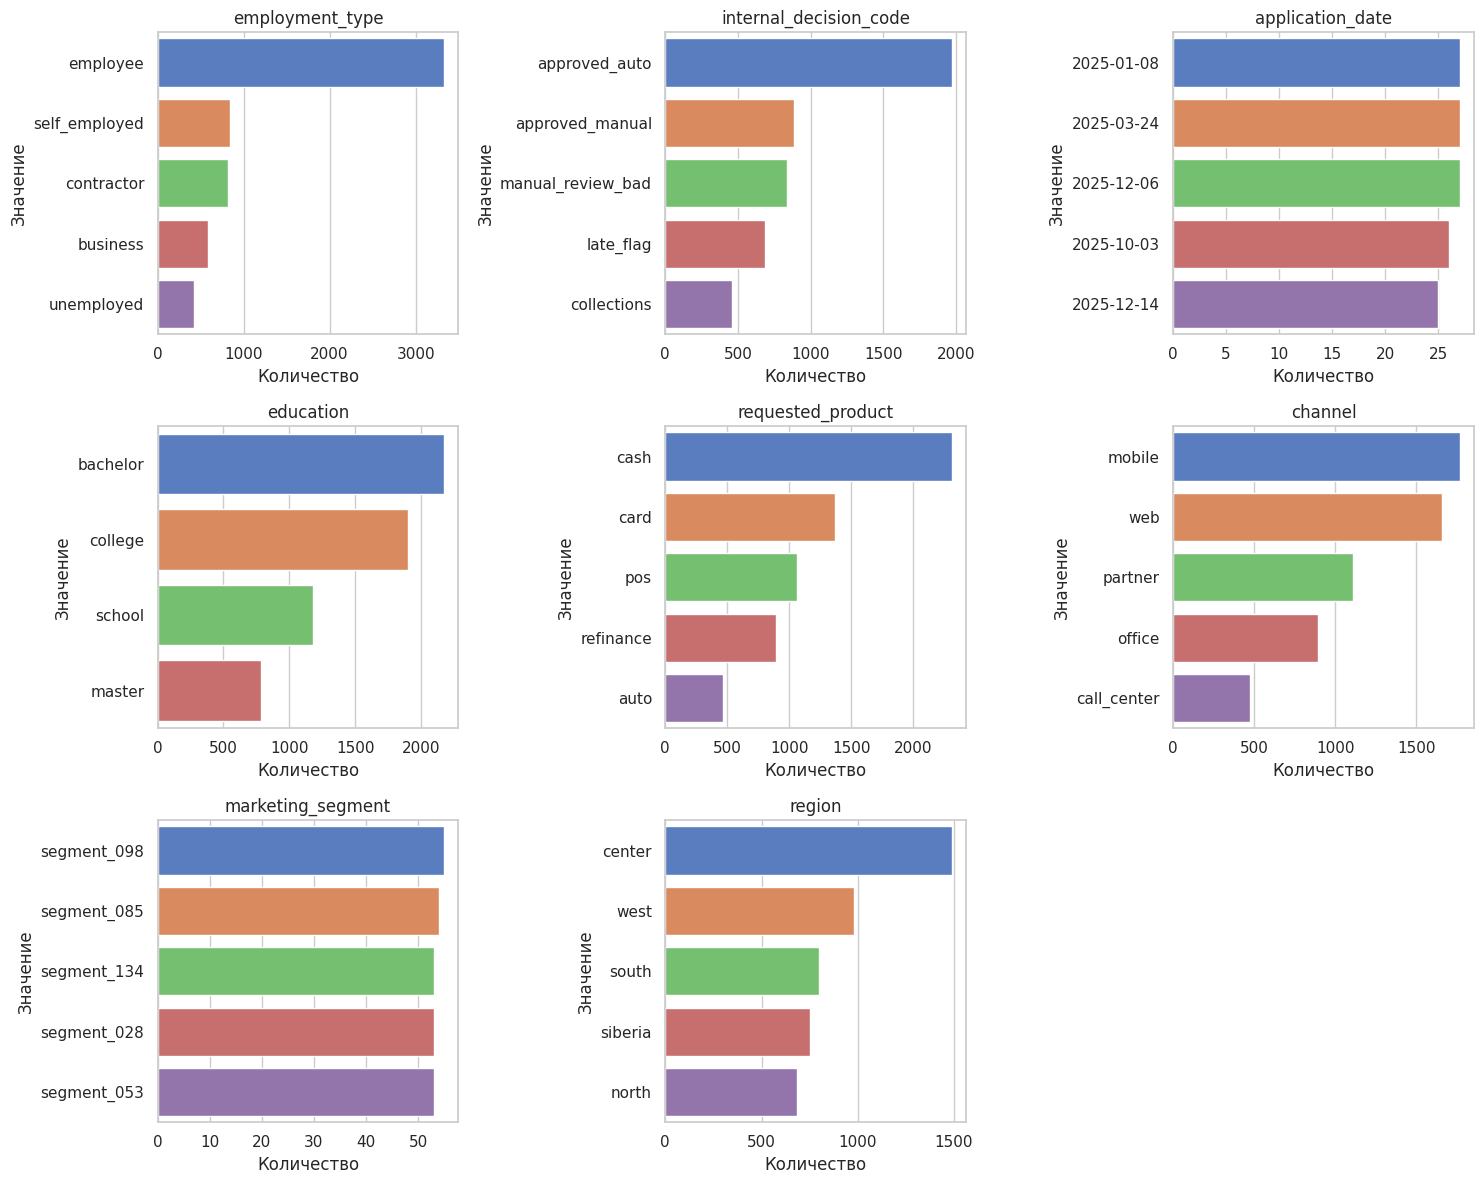

In [109]:
cat_cols_train_m = [col for col in cat_cols_train]
n_cols = 3 
n_rows = (len(cat_cols_train_m) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols_train_m):
    top_values = train[col].value_counts().head(5)
    sns.barplot(
        x=top_values.values,
        y=top_values.index,
        ax=axes[i],
        hue=top_values.index,  
        dodge=False,           
        legend=False           
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Количество')
    axes[i].set_ylabel('Значение')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Проверим train и test после Feature Engineering

In [107]:
train_fe

,application_id,client_id,employment_type,hash_id,region_coefficient_extended,age,incoming_amount,internal_decision_code,monthly_income,application_date,...,income_per_dependent,is_high_risk_employment,is_short_term_loan,is_young,is_senior,is_new_employee,region_risk,loan_to_region_risk,log_siberia_score,age_income_interaction
0,107941,7941,employee,61441390.0,1.0,37.0,30401.28,NaN,30401.28,2025-08-11,...,30401.280000,0,0,0,0,0,1.0,63464.426536,0.289756,381.924097
1,101163,1163,employee,67321556.0,0.0,60.0,26024.64,manual_review_bad,26024.64,2025-12-29,...,26024.640000,0,1,0,0,0,1.0,113513.476487,0.445258,610.010249
2,100583,583,contractor,26719968.0,0.0,37.0,21389.83,vip,21389.83,2025-11-09,...,10694.915000,1,1,0,0,0,1.0,48993.371007,0.000000,368.916551
3,104082,4082,NaN,45184358.0,0.0,NaN,31617.26,approved_auto,NaN,2025-02-23,...,37717.510000,0,0,0,0,0,1.0,77765.702234,0.000000,368.826718
4,108413,8413,employee,58267524.0,0.0,60.0,18000.00,approved_auto,18000.00,2025-12-07,...,18000.000000,0,1,0,0,0,1.0,97254.002746,0.554490,587.890955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6483,101662,1662,contractor,NaN,0.0,26.0,NaN,NaN,21480.58,2025-05-13,...,10740.290000,1,1,0,0,0,1.0,162310.467690,0.000000,259.348729
6484,103037,3037,employee,84416127.0,0.0,56.0,28198.35,manual_review_bad,28198.35,2025-07-05,...,28198.350000,0,1,0,0,0,1.0,97849.932150,0.000000,573.835036
6485,108868,8868,contractor,31058252.0,0.0,50.0,40575.25,vip,40575.25,2025-05-03,...,13525.083333,1,1,0,0,0,1.0,24912.065088,0.396273,530.546910
6486,102303,2303,employee,82787744.0,0.0,56.0,24783.06,approved_manual,24783.06,2025-05-18,...,24783.060000,0,1,0,0,0,0.0,70123.669876,0.028835,566.605535


In [108]:
test_fe

,application_id,client_id,region_coefficient_extended,loan_term_months,siberia_northern_score,hash_id,loan_amount,post_loan_collection_score,months_at_job,channel,...,income_per_dependent,is_high_risk_employment,is_short_term_loan,is_young,is_senior,is_new_employee,region_risk,loan_to_region_risk,log_siberia_score,age_income_interaction
0,102531,2531,0.0,18.0,NaN,NaN,73071.51,NaN,38.0,call_center,...,34183.790,0,0,0,0,0,1.0,73071.436929,0.000000,365.383763
1,107213,7213,0.0,12.0,0.317813,30012008.0,65408.73,NaN,23.0,partner,...,18645.000,1,1,0,1,0,1.0,65408.664591,0.275974,629.336763
2,100238,238,0.0,36.0,0.902039,92419982.0,NaN,NaN,12.0,office,...,26465.920,0,0,1,0,0,1.0,0.000000,0.642926,228.412364
3,104918,4918,0.0,6.0,0.737848,76137566.0,NaN,NaN,179.0,web,...,37825.845,0,1,0,0,0,1.0,0.000000,0.552648,579.742587
4,106480,6480,0.0,12.0,0.746599,21845266.0,76253.20,NaN,153.0,mobile,...,35964.145,0,1,0,0,0,1.0,76253.123747,0.557670,615.089136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,105735,5735,0.0,24.0,0.496285,17047133.0,95337.81,NaN,200.0,mobile,...,17278.640,0,0,0,0,0,1.0,95337.714662,0.402985,365.764086
2516,105192,5192,0.0,9.0,0.940226,77377804.0,NaN,NaN,206.0,web,...,15735.980,1,1,0,0,0,1.0,0.000000,0.662804,441.255881
2517,105391,5391,0.0,36.0,0.765447,NaN,63097.47,NaN,48.0,partner,...,12640.535,0,0,0,0,0,1.0,63097.406903,0.568404,253.446268
2518,100861,861,0.0,12.0,0.826164,87976929.0,148171.13,NaN,90.0,call_center,...,15332.550,0,1,0,0,0,1.0,148170.981829,0.602218,320.258306


## Предобработка и удаление признаков-утечек

### Критически важно: удаление признаков-утечек
В данных обнаружены **три признака, которые дают прямой ответ на целевую переменную**:

1. **`days_until_first_overdue`** — для дефолтных клиентов содержит конкретные дни (4, 8, 15...), для нормальных — магические значения 999/1001. Модель просто выучивает правило «если < 200 → дефолт».

2. **`internal_decision_code`** — значения `late_flag`, `collections` буквально означают «флаг просрочки» и «взыскание». Это не предикторы, а **следствия** дефолта.

3. **`post_loan_collection_score`** — скор, рассчитанный **после** выдачи займа (post-factum). Название говорит само за себя.

Если не удалить эти признаки, локальный AUC будет ~0.99, но на лидерборде — ~0.82 (разрыв из-за отсутствия этих признаков в тесте).

In [112]:
def advanced_preprocessing_catboost(
    train_df: pd.DataFrame, 
    test_df: pd.DataFrame, 
    target_col: str = 'target'
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, List[str], List[str]]:
    """
    Предобработка данных для CatBoost с удалением признаков-утечек.
    
    Args:
        train_df: тренировочный датасет
        test_df: тестовый датасет
        target_col: имя целевой переменной
    
    Returns:
        Tuple[X_train, X_test, y_train, test_ids, cat_cols, num_cols]
    """
    
    # Список признаков-утечек
    leakage_cols: List[str] = [
        'days_until_first_overdue',   # Прямая утечка: 999/1001 для нормы, конкретные дни для дефолта
        'internal_decision_code',     # Прямая утечка: late_flag/collections = дефолт по определению
        'post_loan_collection_score', # Post-factum скор, рассчитанный после события
    ]
    
    cols_to_drop: List[str] = [c for c in leakage_cols if c in train_df.columns]
    print(f"🔴 Удалены признаки-утечки: {cols_to_drop}")

    id_cols: List[str] = ['application_id', 'client_id', 'hash_id']
    drop_all: List[str] = cols_to_drop + id_cols + [target_col]

    X_train: pd.DataFrame = train_df.drop(columns=[c for c in drop_all if c in train_df.columns], errors='ignore')
    X_test: pd.DataFrame = test_df.drop(columns=[c for c in id_cols if c in test_df.columns], errors='ignore')
    y_train: pd.Series = train_df[target_col]
    test_ids: pd.Series = test_df['application_id']

    X_test = X_test.drop(columns=[c for c in leakage_cols if c in X_test.columns], errors='ignore')
    
    cat_cols: List[str] = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols: List[str] = X_train.select_dtypes(include=['number']).columns.tolist()
    
    print(f"Числовых: {len(num_cols)}, Категориальных: {len(cat_cols)}")
    
    # 1. Числовые: заполняем медианой из TRAIN
    for col in num_cols:
        median_val: float = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
        
    # 2. Категориальные: заполняем 'MISSING' и оставляем как строки
    for col in cat_cols:
        X_train[col] = X_train[col].fillna('MISSING').astype(str)
        X_test[col] = X_test[col].fillna('MISSING').astype(str)
        
    # 3. Выравнивание колонок
    missing_in_test: Set = set(X_train.columns) - set(X_test.columns)
    for col in missing_in_test:
        X_test[col] = 'MISSING' if col in cat_cols else 0
        
    extra_in_test: Set = set(X_test.columns) - set(X_train.columns)
    X_test = X_test.drop(columns=list(extra_in_test), errors='ignore')
    X_test = X_test[X_train.columns]
    
    print("✅ Предобработка завершена.")
    return X_train, X_test, y_train, test_ids, cat_cols, num_cols

X_train, X_test, y_train, test_ids, cat_cols, num_cols = advanced_preprocessing_catboost(train_fe, test_fe)

🔴 Удалены признаки-утечки: ['days_until_first_overdue', 'internal_decision_code', 'post_loan_collection_score']
Числовых: 80, Категориальных: 7
✅ Предобработка завершена.


In [113]:
print(f"Train split: {X_train.shape}")
print(f"Test split: {X_test.shape}")

Train split: (6488, 87)
Test split: (2520, 87)


In [114]:
X_train

,employment_type,region_coefficient_extended,age,incoming_amount,monthly_income,application_date,education,requested_product,channel,loan_amount,...,income_per_dependent,is_high_risk_employment,is_short_term_loan,is_young,is_senior,is_new_employee,region_risk,loan_to_region_risk,log_siberia_score,age_income_interaction
0,employee,1.0,37.0,30401.28,30401.28,2025-08-11,bachelor,refinance,partner,63464.49,...,30401.280000,0,0,0,0,0,1.0,63464.426536,0.289756,381.924097
1,employee,0.0,60.0,26024.64,26024.64,2025-12-29,school,card,mobile,113513.59,...,26024.640000,0,1,0,0,0,1.0,113513.476487,0.445258,610.010249
2,contractor,0.0,37.0,21389.83,21389.83,2025-11-09,college,cash,MISSING,48993.42,...,10694.915000,1,1,0,0,0,1.0,48993.371007,0.000000,368.916551
3,MISSING,0.0,44.0,31617.26,37717.51,2025-02-23,college,card,web,77765.78,...,37717.510000,0,0,0,0,0,1.0,77765.702234,0.000000,368.826718
4,employee,0.0,60.0,18000.00,18000.00,2025-12-07,bachelor,card,mobile,97254.10,...,18000.000000,0,1,0,0,0,1.0,97254.002746,0.554490,587.890955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6483,contractor,0.0,26.0,37773.11,21480.58,2025-05-13,master,pos,partner,162310.63,...,10740.290000,1,1,0,0,0,1.0,162310.467690,0.000000,259.348729
6484,employee,0.0,56.0,28198.35,28198.35,2025-07-05,college,cash,mobile,97850.03,...,28198.350000,0,1,0,0,0,1.0,97849.932150,0.000000,573.835036
6485,contractor,0.0,50.0,40575.25,40575.25,2025-05-03,bachelor,cash,office,24912.09,...,13525.083333,1,1,0,0,0,1.0,24912.065088,0.396273,530.546910
6486,employee,0.0,56.0,24783.06,24783.06,2025-05-18,school,cash,office,70123.74,...,24783.060000,0,1,0,0,0,0.0,70123.669876,0.028835,566.605535


In [115]:
X_test

,employment_type,region_coefficient_extended,age,incoming_amount,monthly_income,application_date,education,requested_product,channel,loan_amount,...,income_per_dependent,is_high_risk_employment,is_short_term_loan,is_young,is_senior,is_new_employee,region_risk,loan_to_region_risk,log_siberia_score,age_income_interaction
0,employee,0.0,44.0,34183.79,34183.79,2025-04-25,bachelor,refinance,call_center,73071.51,...,34183.790,0,0,0,0,0,1.0,73071.436929,0.000000,365.383763
1,unemployed,0.0,64.0,18645.00,18645.00,2025-05-07,school,refinance,partner,65408.73,...,18645.000,1,1,0,1,0,1.0,65408.664591,0.275974,629.336763
2,employee,0.0,21.0,52931.84,52931.84,2025-02-26,bachelor,card,office,67344.21,...,26465.920,0,0,1,0,0,1.0,0.000000,0.642926,228.412364
3,employee,0.0,55.0,37301.16,37717.51,2025-12-07,college,auto,web,67344.21,...,37825.845,0,1,0,0,0,1.0,0.000000,0.552648,579.742587
4,MISSING,0.0,55.0,71928.29,71928.29,2025-05-09,bachelor,cash,mobile,76253.20,...,35964.145,0,1,0,0,0,1.0,76253.123747,0.557670,615.089136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,employee,0.0,44.0,34557.28,34557.28,2025-10-23,college,cash,mobile,95337.81,...,17278.640,0,0,0,0,0,1.0,95337.714662,0.402985,365.764086
2516,self_employed,0.0,41.0,37773.11,47207.94,2025-01-19,school,cash,web,67344.21,...,15735.980,1,1,0,0,0,1.0,0.000000,0.662804,441.255881
2517,employee,0.0,25.0,25281.07,25281.07,2025-10-10,college,auto,partner,63097.47,...,12640.535,0,0,0,0,0,1.0,63097.406903,0.568404,253.446268
2518,employee,0.0,31.0,30665.10,30665.10,2025-05-18,college,pos,call_center,148171.13,...,15332.550,0,1,0,0,0,1.0,148170.981829,0.602218,320.258306


In [116]:
y_train

0       1
1       1
2       0
3       0
4       0
       ..
6483    1
6484    1
6485    0
6486    0
6487    0
Name: target, Length: 6488, dtype: int64

In [117]:
test_ids

0       102531
1       107213
2       100238
3       104918
4       106480
         ...  
2515    105735
2516    105192
2517    105391
2518    100861
2519    107271
Name: application_id, Length: 2520, dtype: int64

In [118]:
cat_cols

['employment_type',
 'application_date',
 'education',
 'requested_product',
 'channel',
 'marketing_segment',
 'region']

In [119]:
num_cols

['region_coefficient_extended',
 'age',
 'incoming_amount',
 'monthly_income',
 'loan_amount',
 'region_coefficient',
 'interest_rate',
 'months_at_job',
 'dependents',
 'loan_term_months',
 'siberia_northern_score',
 'bureau_accounts_count',
 'total_credit_limit',
 'total_current_balance',
 'max_dpd_last_12m',
 'active_accounts_count',
 'credit_utilization_ratio',
 'severe_overdue_flag',
 'prev_loans_count',
 'total_prev_amount',
 'max_overdue_days',
 'was_overdue_count',
 'closed_days_ago',
 'was_overdue_ratio',
 'recent_overdue_flag',
 'tx_count',
 'net_tx_amount',
 'total_tx_turnover',
 'days_since_last_tx',
 'gambling_count',
 'gambling_amount',
 'gambling_max_risk',
 'salary_count',
 'avg_salary',
 'days_since_last_salary',
 'high_risk_count',
 'gambling_to_turnover_ratio',
 'employment_type_target_enc',
 'region_target_enc',
 'education_target_enc',
 'requested_product_target_enc',
 'channel_target_enc',
 'monthly_income_safe',
 'loan_to_income_ratio',
 'estimated_monthly_paymen

## Фильтрация признаков
Удаляем признаки, которые не несут полезной информации:
1. **Сильно коррелированные** (|corr| > 0.90) - дублируют друг друга, замедляют обучение;
2. **С околонулевой дисперсией** (< 1e-4) - практически константы, не помогают модели.

In [120]:
print("🔍 Фильтрация признаков...")

# 1. Удаление сильно скоррелированных признаков (порог 0.90 для деревьев)
corr_matrix: pd.DataFrame = X_train[num_cols].corr().abs()
upper: pd.DataFrame = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr: List[str] = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Удалено {len(to_drop_corr)} сильно скоррелированных признаков.")

# 2. Удаление признаков с околонулевой дисперсией
variances: pd.Series = X_train[num_cols].var(skipna=True)
to_drop_var: List[str] = variances[variances < 1e-4].index.tolist()
print(f"Удалено {len(to_drop_var)} признаков с низкой дисперсией.")

# Объединяем списки для удаления
drop_cols: List[str] = list(set(to_drop_corr + to_drop_var))

# Применяем фильтрацию
X_train_filtered: pd.DataFrame = X_train.drop(columns=drop_cols, errors='ignore')
X_test_filtered: pd.DataFrame = X_test.drop(columns=drop_cols, errors='ignore')

# Обновляем списки колонок
final_num_cols: List[str] = [c for c in num_cols if c not in drop_cols]
final_cat_cols: List[str] = [c for c in cat_cols if c not in drop_cols]

print(f"✅ Осталось признаков для обучения: {X_train_filtered.shape[1]}")

🔍 Фильтрация признаков...
Удалено 12 сильно скоррелированных признаков.
Удалено 2 признаков с низкой дисперсией.
✅ Осталось признаков для обучения: 73


In [121]:
final_num_cols

['region_coefficient_extended',
 'age',
 'incoming_amount',
 'loan_amount',
 'interest_rate',
 'months_at_job',
 'dependents',
 'loan_term_months',
 'siberia_northern_score',
 'bureau_accounts_count',
 'total_credit_limit',
 'total_current_balance',
 'max_dpd_last_12m',
 'active_accounts_count',
 'credit_utilization_ratio',
 'severe_overdue_flag',
 'prev_loans_count',
 'total_prev_amount',
 'max_overdue_days',
 'was_overdue_count',
 'closed_days_ago',
 'was_overdue_ratio',
 'recent_overdue_flag',
 'tx_count',
 'net_tx_amount',
 'total_tx_turnover',
 'days_since_last_tx',
 'gambling_count',
 'gambling_amount',
 'gambling_max_risk',
 'salary_count',
 'avg_salary',
 'high_risk_count',
 'gambling_to_turnover_ratio',
 'employment_type_target_enc',
 'region_target_enc',
 'requested_product_target_enc',
 'channel_target_enc',
 'loan_to_income_ratio',
 'estimated_monthly_payment',
 'payment_to_income_ratio',
 'log_loan_amount',
 'log_total_credit_limit',
 'log_prev_amount',
 'log_max_overdue',

In [122]:
final_cat_cols

['employment_type',
 'application_date',
 'education',
 'requested_product',
 'channel',
 'marketing_segment',
 'region']

In [123]:
X_train_filtered

,employment_type,region_coefficient_extended,age,incoming_amount,application_date,education,requested_product,channel,loan_amount,marketing_segment,...,total_debt,total_debt_to_income,income_per_dependent,is_high_risk_employment,is_short_term_loan,is_young,is_senior,is_new_employee,region_risk,log_siberia_score
0,employee,1.0,37.0,30401.28,2025-08-11,bachelor,refinance,partner,63464.49,segment_011,...,135674.59,0.371899,30401.280000,0,0,0,0,0,1.0,0.289756
1,employee,0.0,60.0,26024.64,2025-12-29,school,card,mobile,113513.59,segment_067,...,382582.60,1.225065,26024.640000,0,1,0,0,0,1.0,0.445258
2,contractor,0.0,37.0,21389.83,2025-11-09,college,cash,MISSING,48993.42,MISSING,...,58356.29,0.227352,10694.915000,1,1,0,0,0,1.0,0.000000
3,MISSING,0.0,44.0,31617.26,2025-02-23,college,card,web,77765.78,segment_089,...,137497.69,0.303788,37717.510000,0,0,0,0,0,1.0,0.000000
4,employee,0.0,60.0,18000.00,2025-12-07,bachelor,card,mobile,97254.10,segment_063,...,144718.37,0.669992,18000.000000,0,1,0,0,0,1.0,0.554490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6483,contractor,0.0,26.0,37773.11,2025-05-13,master,pos,partner,162310.63,segment_125,...,222414.18,0.862850,10740.290000,1,1,0,0,0,1.0,0.000000
6484,employee,0.0,56.0,28198.35,2025-07-05,college,cash,mobile,97850.03,segment_099,...,184477.77,0.545179,28198.350000,0,1,0,0,0,1.0,0.000000
6485,contractor,0.0,50.0,40575.25,2025-05-03,bachelor,cash,office,24912.09,segment_066,...,33618.36,0.069045,13525.083333,1,1,0,0,0,1.0,0.396273
6486,employee,0.0,56.0,24783.06,2025-05-18,school,cash,office,70123.74,segment_053,...,167990.12,0.564869,24783.060000,0,1,0,0,0,0.0,0.028835


In [124]:
X_test_filtered

,employment_type,region_coefficient_extended,age,incoming_amount,application_date,education,requested_product,channel,loan_amount,marketing_segment,...,total_debt,total_debt_to_income,income_per_dependent,is_high_risk_employment,is_short_term_loan,is_young,is_senior,is_new_employee,region_risk,log_siberia_score
0,employee,0.0,44.0,34183.79,2025-04-25,bachelor,refinance,call_center,73071.51,segment_112,...,277534.29,0.676574,34183.790,0,0,0,0,0,1.0,0.000000
1,unemployed,0.0,64.0,18645.00,2025-05-07,school,refinance,partner,65408.73,segment_023,...,135609.00,0.606101,18645.000,1,1,0,1,0,1.0,0.275974
2,employee,0.0,21.0,52931.84,2025-02-26,bachelor,card,office,67344.21,segment_020,...,25465.91,0.040092,26465.920,0,0,1,0,0,1.0,0.642926
3,employee,0.0,55.0,37301.16,2025-12-07,college,auto,web,67344.21,segment_057,...,38604.76,0.085049,37825.845,0,1,0,0,0,1.0,0.552648
4,MISSING,0.0,55.0,71928.29,2025-05-09,bachelor,cash,mobile,76253.20,segment_138,...,193299.65,0.223949,35964.145,0,1,0,0,0,1.0,0.557670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2515,employee,0.0,44.0,34557.28,2025-10-23,college,cash,mobile,95337.81,segment_139,...,171150.89,0.412723,17278.640,0,0,0,0,0,1.0,0.402985
2516,self_employed,0.0,41.0,37773.11,2025-01-19,school,cash,web,67344.21,segment_097,...,60786.35,0.107302,15735.980,1,1,0,0,0,1.0,0.662804
2517,employee,0.0,25.0,25281.07,2025-10-10,college,auto,partner,63097.47,segment_057,...,207750.80,0.684804,12640.535,0,0,0,0,0,1.0,0.568404
2518,employee,0.0,31.0,30665.10,2025-05-18,college,pos,call_center,148171.13,segment_123,...,305072.72,0.829044,15332.550,0,1,0,0,0,1.0,0.602218


## Проверка на оставшиеся утечки данных
Автоматически проверяем корреляцию каждого числового признака с target. Если |corr| > 0.9 - признак почти наверняка является утечкой и должен быть удалён.
Также построим график признаков по абсолютной корреляции с целевой переменной.

Проверка на оставшиеся утечки данных...

Топ-30 признаков по корреляции с target:
max_dpd_last_12m                0.348404
severe_overdue_flag             0.292119
payment_to_income_ratio         0.280196
total_debt_to_income            0.253923
months_at_job                   0.238831
loan_to_income_ratio            0.236080
employment_type_target_enc      0.224460
estimated_monthly_payment       0.211477
age                             0.175226
total_debt                      0.161692
incoming_amount                 0.160331
has_overdue_history             0.154647
max_overdue_days                0.152014
loan_amount                     0.150059
log_max_overdue                 0.132203
total_tx_turnover               0.124883
is_short_term_loan              0.123669
log_total_credit_limit          0.118626
income_per_dependent            0.117226
avg_salary                      0.112001
loan_term_months                0.110590
is_new_employee                 0.109438
is_high_risk_emp

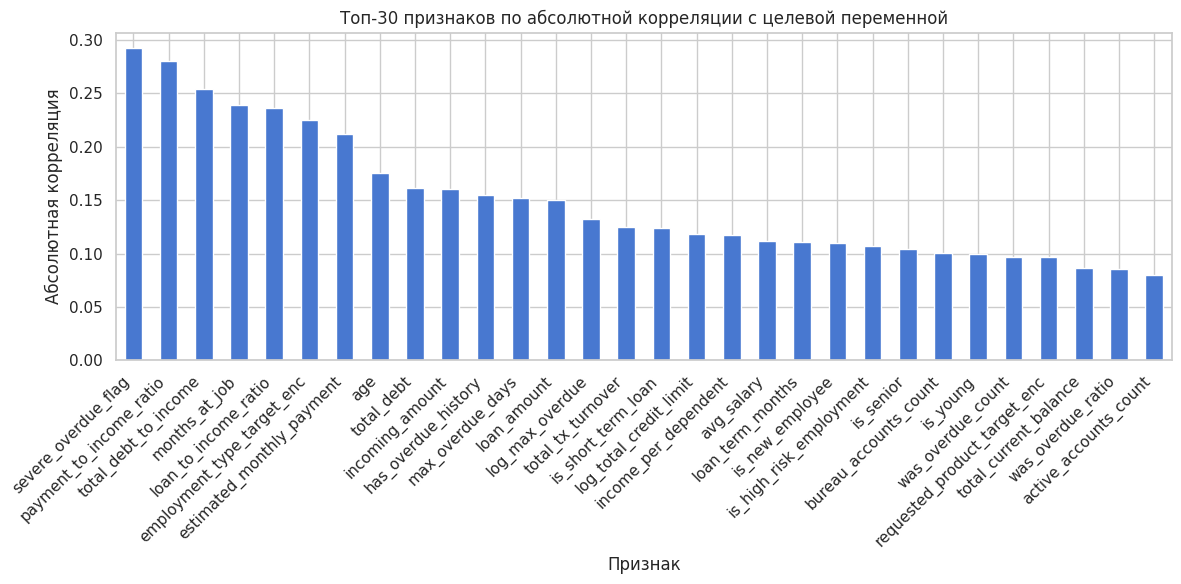


Топ-30 признаков по корреляции с target:
severe_overdue_flag             0.292119
payment_to_income_ratio         0.280196
total_debt_to_income            0.253923
months_at_job                   0.238831
loan_to_income_ratio            0.236080
employment_type_target_enc      0.224460
estimated_monthly_payment       0.211477
age                             0.175226
total_debt                      0.161692
incoming_amount                 0.160331
has_overdue_history             0.154647
max_overdue_days                0.152014
loan_amount                     0.150059
log_max_overdue                 0.132203
total_tx_turnover               0.124883
is_short_term_loan              0.123669
log_total_credit_limit          0.118626
income_per_dependent            0.117226
avg_salary                      0.112001
loan_term_months                0.110590
is_new_employee                 0.109438
is_high_risk_employment         0.106736
is_senior                       0.104198
bureau_accounts

In [126]:
print("Проверка на оставшиеся утечки данных...")
correlations_with_target: pd.Series = X_train_filtered[final_num_cols].corrwith(y_train).abs().sort_values(ascending=False)

print("\nТоп-30 признаков по корреляции с target:")
print(correlations_with_target.head(30))

top_corr: pd.Series = correlations_with_target[1:31]  # Исключаем саму целевую переменную
    
plt.figure(figsize=(12, 6))
top_corr.plot(kind='bar')
plt.title('Топ-30 признаков по абсолютной корреляции с целевой переменной')
plt.xlabel('Признак')
plt.ylabel('Абсолютная корреляция')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nТоп-30 признаков по корреляции с {target_col}:")
print(correlations_with_target[1:31])

suspicious: pd.Series = correlations_with_target[correlations_with_target > 0.9]
if len(suspicious) > 0:
    print(f"\n⚠️ ОБНАРУЖЕНЫ ПОДОЗРИТЕЛЬНЫЕ ПРИЗНАКИ (корреляция > 0.9):")
    for col, corr in suspicious.items():
        print(f"  {col}: {corr:.4f}")
    print("→ Рекомендуется удалить их и пересчитать.")
    
    # Автоматическое удаление
    X_train_filtered: pd.DataFrame = X_train_filtered.drop(columns=suspicious.index.tolist(), errors='ignore')
    X_test_filtered: pd.DataFrame = X_test_filtered.drop(columns=suspicious.index.tolist(), errors='ignore')
    final_num_cols: List[str] = [c for c in final_num_cols if c not in suspicious.index.tolist()]
    print(f"✅ Удалено {len(suspicious)} подозрительных признаков.")
else:
    print("✅ Подозрительных признаков не обнаружено.")

In [128]:
correlations_with_target

max_dpd_last_12m           0.348404
severe_overdue_flag        0.292119
payment_to_income_ratio    0.280196
total_debt_to_income       0.253923
months_at_job              0.238831
                             ...   
loan_to_salary_ratio       0.003528
region_risk                0.003121
log_loan_amount            0.002751
log_siberia_score          0.002732
recent_activity_flag       0.000684
Length: 66, dtype: float64

## Анализ категориальных признаков

In [129]:
print("\nАнализ категориальных признаков (train):")
categorical_cols: List[str] = X_train_filtered.select_dtypes(include=['object']).columns.tolist()
print(f"Всего категориальных признаков: {len(categorical_cols)}")
print(f"\nКатегориальные признаки ({len(categorical_cols)}): {categorical_cols}")


Анализ категориальных признаков (train):
Всего категориальных признаков: 7

Категориальные признаки (7): ['employment_type', 'application_date', 'education', 'requested_product', 'channel', 'marketing_segment', 'region']


In [130]:
categorical_cols

['employment_type',
 'application_date',
 'education',
 'requested_product',
 'channel',
 'marketing_segment',
 'region']

In [131]:
final_cat_cols

['employment_type',
 'application_date',
 'education',
 'requested_product',
 'channel',
 'marketing_segment',
 'region']

In [132]:
print("\nАнализ категориальных признаков (test):")
categorical_cols_test: List[str] = X_test_filtered.select_dtypes(include=['object']).columns.tolist()
print(f"Всего категориальных признаков: {len(categorical_cols_test)}")
print(f"\nКатегориальные признаки ({len(categorical_cols_test)}): {categorical_cols_test}")


Анализ категориальных признаков (test):
Всего категориальных признаков: 7

Категориальные признаки (7): ['employment_type', 'application_date', 'education', 'requested_product', 'channel', 'marketing_segment', 'region']


## Optuna-оптимизация гиперпараметров
Используем **TPE-сэмплер** (Tree-structured Parzen Estimator) - байесовский метод, который эффективнее случайного поиска.

### Почему Optuna, а не GridSearch?
- **GridSearch** перебирает все комбинации → экспоненциальный рост времени
- **RandomSearch** не учитывает результаты предыдущих испытаний
- **Optuna (TPE)** строит вероятностную модель пространства параметров и фокусируется на перспективных областях

### Пространства параметров
- **LightGBM:** `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`, регуляризация
- **CatBoost:** `iterations`, `depth`, `l2_leaf_reg`, `bagging_temperature`
- **XGBoost:** аналогично LightGBM + `min_child_weight`

In [135]:
def optimize_stacking_params(
    X_train_num: pd.DataFrame, 
    X_train_cat: pd.DataFrame, 
    y_train: pd.Series, 
    X_val_num: pd.DataFrame, 
    X_val_cat: pd.DataFrame, 
    y_val: pd.Series, 
    cat_features_list: List[str], 
    n_trials: int = 30
) -> Tuple[Dict[str, Dict[str, Any]], Dict[str, float]]:
    """
    Оптимизация гиперпараметров для трёх моделей стекинга с помощью Optuna.
    
    Args:
        X_train_num: числовая версия train
        X_train_cat: оригинальная версия train (с категориями)
        y_train: target train
        X_val_num: числовая версия val
        X_val_cat: оригинальная версия val
        y_val: target val
        cat_features_list: список категориальных колонок
        n_trials: количество испытаний Optuna
    
    Returns:
        Tuple[best_params, best_scores]: лучшие параметры и скоры для каждой модели
    """
    
    best_params: Dict[str, Dict[str, Any]] = {'lgb': {}, 'cb': {}, 'xgb': {}}
    best_scores: Dict[str, float] = {'lgb': 0, 'cb': 0, 'xgb': 0}
    
    print("Оптимизация LightGBM...")
    def objective_lgb(trial: optuna.trial.Trial) -> float:
        params: Dict[str, Any] = {
            'n_estimators': trial.suggest_int('n_estimators', 1000, 3000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 9),
            'num_leaves': trial.suggest_int('num_leaves', 31, 127),
            'subsample': trial.suggest_float('subsample', 0.6, 0.95),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
            'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1, 'is_unbalance': True
        }
        model: lgb.LGBMClassifier = lgb.LGBMClassifier(**params)
        model.fit(X_train_num, y_train, eval_set=[(X_val_num, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        preds: np.ndarray = model.predict_proba(X_val_num)[:, 1]
        return roc_auc_score(y_val, preds)
    
    study_lgb: optuna.study.Study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_lgb.optimize(objective_lgb, n_trials=n_trials, show_progress_bar=False)
    best_params['lgb'] = study_lgb.best_params
    best_scores['lgb'] = study_lgb.best_value
    print(f"  ✅ Лучший LGBM AUC: {best_scores['lgb']:.5f}")
    
    print("Оптимизация CatBoost...")
    def objective_cb(trial: optuna.trial.Trial) -> float:
        params: Dict[str, Any] = {
            'iterations': trial.suggest_int('iterations', 1000, 3000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'depth': trial.suggest_int('depth', 4, 9),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 2),
            'random_strength': trial.suggest_float('random_strength', 0.5, 5),
            'random_state': RANDOM_STATE, 'verbose': 0,
            'auto_class_weights': 'Balanced',
            'grow_policy': 'SymmetricTree',
            'bootstrap_type': 'Bayesian'
        }
        model: CatBoostClassifier = CatBoostClassifier(**params)
        model.fit(X_train_cat, y_train, eval_set=(X_val_cat, y_val),
                  cat_features=cat_features_list, early_stopping_rounds=50, verbose=0)
        preds: np.ndarray = model.predict_proba(X_val_cat)[:, 1]
        return roc_auc_score(y_val, preds)
    
    study_cb: optuna.study.Study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_cb.optimize(objective_cb, n_trials=n_trials, show_progress_bar=False)
    best_params['cb'] = study_cb.best_params
    best_scores['cb'] = study_cb.best_value
    print(f"  ✅ Лучший CatBoost AUC: {best_scores['cb']:.5f}")
    
    print("Оптимизация XGBoost...")
    def objective_xgb(trial: optuna.trial.Trial) -> float:
        params: Dict[str, Any] = {
            'n_estimators': trial.suggest_int('n_estimators', 1000, 3000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'subsample': trial.suggest_float('subsample', 0.6, 0.95),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'random_state': RANDOM_STATE, 'n_jobs': -1, 'eval_metric': 'auc'
        }
        model: xgb.XGBClassifier = xgb.XGBClassifier(**params)
        model.fit(X_train_num, y_train, eval_set=[(X_val_num, y_val)], verbose=0)
        preds: np.ndarray = model.predict_proba(X_val_num)[:, 1]
        return roc_auc_score(y_val, preds)
    
    study_xgb: optuna.study.Study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_xgb.optimize(objective_xgb, n_trials=n_trials, show_progress_bar=False)
    best_params['xgb'] = study_xgb.best_params
    best_scores['xgb'] = study_xgb.best_value
    print(f"  ✅ Лучший XGB AUC: {best_scores['xgb']:.5f}")
    
    return best_params, best_scores

## Stacking-ансамбль: LightGBM + CatBoost + XGBoost → Logistic Regression

### Почему Stacking?
1. **Разнообразие моделей** - каждая модель «видит» данные по-своему:
   - **CatBoost** - лучше всего работает с категориальными признаками (нативная обработка);
   - **LightGBM** - быстрый, хорошо ловит числовые паттерны;
   - **XGBoost** - стабильная регуляризация, хорошо обобщает.

2. **Мета-модель (Logistic Regression)** - обучается на out-of-fold предсказаниях базовых моделей, что предотвращает переобучение.

3. **5-Fold CV** - каждая базовая модель обучается на 4 фолдах и предсказывает на 5-м, что даёт честные OOF-предсказания.

### Почему именно эти модели?
- **CatBoost** выбран как основная модель благодаря нативной работе с категориями (параметр `cat_features`);
- **LightGBM** и **XGBoost** дополняют его, работая с числовыми версиями признаков;
- **Logistic Regression** как мета-модель — простая, интерпретируемая, не переобучается на 3 признаках.

In [ ]:
def run_stacking_ensemble(X_train, y_train, X_test, cat_features_list):
    print("🚀 Запуск 5-Fold Stacking (LGBM + CatBoost + XGBoost -> Logistic Regression)")
    print("🔧 Подготовка числовой версии данных для LightGBM и XGBoost...")
    X_train_num = X_train.copy()
    X_test_num = X_test.copy()
    
    le_dict = {}
    for col in cat_features_list:
        le = LabelEncoder()
        combined = pd.concat([X_train_num[col].astype(str), X_test_num[col].astype(str)])
        le.fit(combined)
        X_train_num[col] = le.transform(X_train_num[col].astype(str))
        X_test_num[col] = le.transform(X_test_num[col].astype(str))
        le_dict[col] = le
    
    print(f"✅ Закодировано {len(cat_features_list)} категориальных признаков")
    
    n_splits = 5
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    
    oof_lgb = np.zeros(len(X_train))
    oof_cb = np.zeros(len(X_train))
    oof_xgb = np.zeros(len(X_train))
    
    test_lgb = np.zeros(len(X_test))
    test_cb = np.zeros(len(X_test))
    test_xgb = np.zeros(len(X_test))
    
    # Списки для хранения скоров каждого фолда
    fold_scores_lgb = []
    fold_scores_cb = []
    fold_scores_xgb = []
    
    # Инициализация моделей
    # lgb_model = lgb.LGBMClassifier(
    #     n_estimators=1500, learning_rate=0.03, max_depth=8, num_leaves=63, 
    #     subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1, 
    #     random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, is_unbalance=True
    # )

    lgb_model = lgb.LGBMClassifier(
            n_estimators=2000, learning_rate=0.02, max_depth=7, num_leaves=63,
            subsample=0.8, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
            min_child_samples=50, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
            is_unbalance=True
        )
    
    # cb_model = CatBoostClassifier(
    #     iterations=1500, learning_rate=0.03, depth=6, l2_leaf_reg=5, 
    #     random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced', 
    #     grow_policy="SymmetricTree", bootstrap_type="Bayesian", bagging_temperature=1.0
    # )

    cb_model = CatBoostClassifier(
            iterations=2000, learning_rate=0.03, depth=6, l2_leaf_reg=5,
            random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced',
            grow_policy="SymmetricTree", bootstrap_type="Bayesian", bagging_temperature=1.0
        )
    
    # xgb_model = xgb.XGBClassifier(
    #     n_estimators=1500, learning_rate=0.03, max_depth=6, subsample=0.8, 
    #     colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1, 
    #     random_state=RANDOM_STATE, n_jobs=-1, eval_metric='auc'
    # )

    xgb_model = xgb.XGBClassifier(
            n_estimators=2000, learning_rate=0.02, max_depth=6, subsample=0.8,
            colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
            random_state=RANDOM_STATE, n_jobs=-1, eval_metric='auc'
        )
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        print(f"\n--- Fold {fold+1}/{n_splits} ---")
        
        X_tr_cat, X_val_cat = X_train.iloc[train_idx], X_train.iloc[val_idx]
        X_tr_num, X_val_num = X_train_num.iloc[train_idx], X_train_num.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # --- LightGBM ---
        lgb_model.fit(X_tr_num, y_tr, eval_set=[(X_val_num, y_val)], 
                      callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
        oof_lgb[val_idx] = lgb_model.predict_proba(X_val_num)[:, 1]
        test_lgb += lgb_model.predict_proba(X_test_num)[:, 1] / n_splits
        
        # --- CatBoost ---
        cb_model.fit(X_tr_cat, y_tr, eval_set=(X_val_cat, y_val), cat_features=cat_features_list, 
                     early_stopping_rounds=100, verbose=0)
        oof_cb[val_idx] = cb_model.predict_proba(X_val_cat)[:, 1]
        test_cb += cb_model.predict_proba(X_test)[:, 1] / n_splits
        
        # --- XGBoost ---
        xgb_model.fit(X_tr_num, y_tr, eval_set=[(X_val_num, y_val)], verbose=0)
        oof_xgb[val_idx] = xgb_model.predict_proba(X_val_num)[:, 1]
        test_xgb += xgb_model.predict_proba(X_test_num)[:, 1] / n_splits
        
        # Оценка на валидации фолдов
        auc_lgb = roc_auc_score(y_val, oof_lgb[val_idx])
        auc_cb = roc_auc_score(y_val, oof_cb[val_idx])
        auc_xgb = roc_auc_score(y_val, oof_xgb[val_idx])
        
        fold_scores_lgb.append(auc_lgb)
        fold_scores_cb.append(auc_cb)
        fold_scores_xgb.append(auc_xgb)
        
        print(f"  Fold {fold+1} Val AUC -> LGBM: {auc_lgb:.5f} | CatBoost: {auc_cb:.5f} | XGB: {auc_xgb:.5f}")

    # Расчет среднего OOF скора по всем фолдам
    mean_oof_lgb = np.mean(fold_scores_lgb)
    mean_oof_cb = np.mean(fold_scores_cb)
    mean_oof_xgb = np.mean(fold_scores_xgb)
    mean_oof_avg = (mean_oof_lgb + mean_oof_cb + mean_oof_xgb) / 3
    
    print("\n" + "="*60)
    print("СВОДКА ПО КРОСС-ВАЛИДАЦИИ (Оценка для лидерборда)")
    print("="*60)
    print(f"Средний OOF AUC LightGBM:  {mean_oof_lgb:.5f} (±{np.std(fold_scores_lgb):.5f})")
    print(f"Средний OOF AUC CatBoost:   {mean_oof_cb:.5f} (±{np.std(fold_scores_cb):.5f})")
    print(f"Средний OOF AUC XGBoost:    {mean_oof_xgb:.5f} (±{np.std(fold_scores_xgb):.5f})")
    print(f"СРЕДНИЙ OOF AUC ВСЕХ МОДЕЛЕЙ: {mean_oof_avg:.5f}")
    print("="*60)

    # Мета-модель
    print("\nОбучение мета-модели (Logistic Regression) на OOF предсказаниях...")
    X_meta_train = np.column_stack((oof_lgb, oof_cb, oof_xgb))
    X_meta_test = np.column_stack((test_lgb, test_cb, test_xgb))
    
    meta_model = LogisticRegression(C=1.0, random_state=RANDOM_STATE, max_iter=1000)
    meta_model.fit(X_meta_train, y_train)
    
    final_test_preds = meta_model.predict_proba(X_meta_test)[:, 1]
    
    # Оценка мета-модели на OOF данных
    oof_meta_preds = meta_model.predict_proba(X_meta_train)[:, 1]
    stacking_oof_auc = roc_auc_score(y_train, oof_meta_preds)
    
    print(f"✅ Итоговый Stacking OOF AUC (Meta-Model): {stacking_oof_auc:.5f}")
    print(f"   (Ожидаемый скор на платформе: ~{stacking_oof_auc:.4f} ± 0.01)")
    
    return final_test_preds, stacking_oof_auc, oof_meta_preds

## ROC-AUC кривая
ROC-кривая показывает соотношение TPR (True Positive Rate) и FPR (False Positive Rate) при различных порогах классификации.

**Площадь под кривой (AUC)** - наша целевая метрика.

## SHAP-анализ (интерпретируемость модели)
**SHAP (SHapley Additive exPlanations)** - метод интерпретации моделей на основе теории игр. Показывает вклад каждого признака в предсказание.

### Почему SHAP важен?
1. **Требование конкурса** - «EDA, гипотезы, визуализации»
2. **Интерпретируемость** - показывает, какие признаки действительно важны
3. **Доверие** - позволяет объяснить решения модели бизнесу

Для ускорения используем подвыборку из 2000 записей.

## Learning Curve (кривые обучения)
Показывает, как меняется качество модели на train и validation при увеличении размера обучающей выборки.

### Интерпретация:
- **Большой разрыв** между train и val → переобучение;
- **Обе кривые низкие** → недообучение;
- **Кривые сходятся** → модель хорошо обобщает.

## Сравнение важности признаков моделей
Визуализируем топ-15 признаков по важности для каждой из трёх базовых моделей стекинга. Это позволяет увидеть, какие признаки «видит» каждая модель.

In [ ]:
def custom_learning_curve_catboost(
    X: pd.DataFrame, 
    y: pd.Series, 
    cat_features: List[str],
    train_sizes: np.ndarray,
    n_splits: int = 3,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Кастомная реализация learning curve для CatBoost.
    
    Args:
        X: данные
        y: целевая переменная
        cat_features: список категориальных колонок
        train_sizes: массив размеров обучающей выборки (от 0 до 1)
        n_splits: количество фолдов CV
        random_state: случайное состояние
    
    Returns:
        Tuple[train_sizes_abs, train_scores, val_scores]
    """
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    train_scores_list = []
    val_scores_list = []
    train_sizes_abs = []
    
    for size_frac in train_sizes:
        size = int(len(X) * size_frac)
        train_sizes_abs.append(size)
        
        fold_train_scores = []
        fold_val_scores = []
        
        for train_idx, val_idx in kf.split(X, y):
            # Берём подвыборку нужного размера
            train_idx_subset = train_idx[:size]
            
            X_tr = X.iloc[train_idx_subset]
            y_tr = y.iloc[train_idx_subset]
            X_val = X.iloc[val_idx]
            y_val = y.iloc[val_idx]
            
            # Обучаем CatBoost
            model = CatBoostClassifier(
                iterations=500,
                learning_rate=0.05,
                depth=6,
                random_state=random_state,
                verbose=0,
                auto_class_weights='Balanced'
            )
            model.fit(X_tr, y_tr, cat_features=cat_features, verbose=0)
            
            # Считаем метрики
            train_pred = model.predict_proba(X_tr)[:, 1]
            val_pred = model.predict_proba(X_val)[:, 1]
            
            fold_train_scores.append(roc_auc_score(y_tr, train_pred))
            fold_val_scores.append(roc_auc_score(y_val, val_pred))
        
        train_scores_list.append(np.mean(fold_train_scores))
        val_scores_list.append(np.mean(fold_val_scores))
    
    return np.array(train_sizes_abs), np.array(train_scores_list), np.array(val_scores_list)


def run_stacking_ensemble_with_optuna(
    X_train: pd.DataFrame, 
    y_train: pd.Series, 
    X_test: pd.DataFrame, 
    cat_features_list: List[str], 
    n_trials: int = 30
) -> Tuple[np.ndarray, float, np.ndarray, Dict[str, List[float]]]:
    """
    Запуск стекинга с Optuna-оптимизацией параметров на каждом фолде.
    
    Args:
        X_train: тренировочные данные
        y_train: целевая переменная train
        X_test: тестовые данные
        cat_features_list: список категориальных колонок
        n_trials: количество испытаний Optuna на фолд
    
    Returns:
        Tuple[final_test_preds, stacking_oof_auc, oof_meta_preds, fold_scores]
    """
    print("Запуск стекинга с Optuna-оптимизацией параметров")
    
    # Подготовка числовой версии (для LightGBM и XGBoost)
    X_train_num: pd.DataFrame = X_train.copy()
    X_test_num: pd.DataFrame = X_test.copy()
    
    le_dict: Dict[str, LabelEncoder] = {}
    for col in cat_features_list:
        le: LabelEncoder = LabelEncoder()
        combined: pd.Series = pd.concat([X_train_num[col].astype(str), X_test_num[col].astype(str)])
        le.fit(combined)
        X_train_num[col] = le.transform(X_train_num[col].astype(str))
        X_test_num[col] = le.transform(X_test_num[col].astype(str))
        le_dict[col] = le
    
    n_splits: int = 5
    kf: StratifiedKFold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    
    oof_lgb: np.ndarray = np.zeros(len(X_train))
    oof_cb: np.ndarray = np.zeros(len(X_train))
    oof_xgb: np.ndarray = np.zeros(len(X_train))
    test_lgb: np.ndarray = np.zeros(len(X_test))
    test_cb: np.ndarray = np.zeros(len(X_test))
    test_xgb: np.ndarray = np.zeros(len(X_test))
    
    fold_scores: Dict[str, List[float]] = {'lgb': [], 'cb': [], 'xgb': []}
    
    # Переменные для хранения моделей последнего фолда (для визуализации)
    lgb_model = None
    cb_model = None
    xgb_model = None
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        print(f"\n{'='*60}")
        print(f"FOLD {fold+1}/{n_splits}")
        print(f"{'='*60}")
        
        X_tr_cat: pd.DataFrame = X_train.iloc[train_idx]
        X_val_cat: pd.DataFrame = X_train.iloc[val_idx]
        X_tr_num: pd.DataFrame = X_train_num.iloc[train_idx]
        X_val_num: pd.DataFrame = X_train_num.iloc[val_idx]
        y_tr: pd.Series = y_train.iloc[train_idx]
        y_val: pd.Series = y_train.iloc[val_idx]
        
        # Оптимизация параметров на каждом фолде
        best_params: Dict[str, Dict[str, Any]]
        best_scores: Dict[str, float]
        best_params, best_scores = optimize_stacking_params(
            X_tr_num, X_tr_cat, y_tr, X_val_num, X_val_cat, y_val,
            cat_features_list, n_trials=n_trials
        )
        
        print(f"\nЛучшие параметры фолда {fold+1}:")
        print(f"  LGBM AUC: {best_scores['lgb']:.5f}")
        print(f"  CB AUC:   {best_scores['cb']:.5f}")
        print(f"  XGB AUC:  {best_scores['xgb']:.5f}")
        
        # Обучение финальных моделей с лучшими параметрами
        # LightGBM
        lgb_params: Dict[str, Any] = {**best_params['lgb'], 'random_state': RANDOM_STATE, 'n_jobs': -1, 
                      'verbose': -1, 'is_unbalance': True}
        lgb_model = lgb.LGBMClassifier(**lgb_params)
        lgb_model.fit(X_tr_num, y_tr, eval_set=[(X_val_num, y_val)],
                      callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
        oof_lgb[val_idx] = lgb_model.predict_proba(X_val_num)[:, 1]
        test_lgb += lgb_model.predict_proba(X_test_num)[:, 1] / n_splits
        
        # CatBoost
        cb_params: Dict[str, Any] = {**best_params['cb'], 'random_seed': RANDOM_STATE, 'verbose': 0,
                     'auto_class_weights': 'Balanced', 'grow_policy': 'SymmetricTree',
                     'bootstrap_type': 'Bayesian'}
        cb_model = CatBoostClassifier(**cb_params)
        cb_model.fit(X_tr_cat, y_tr, eval_set=(X_val_cat, y_val), cat_features=cat_features_list,
                     early_stopping_rounds=100, verbose=0)
        oof_cb[val_idx] = cb_model.predict_proba(X_val_cat)[:, 1]
        test_cb += cb_model.predict_proba(X_test)[:, 1] / n_splits
        
        # XGBoost
        xgb_params: Dict[str, Any] = {**best_params['xgb'], 'random_state': RANDOM_STATE, 'n_jobs': -1, 'eval_metric': 'auc'}
        xgb_model = xgb.XGBClassifier(**xgb_params)
        xgb_model.fit(X_tr_num, y_tr, eval_set=[(X_val_num, y_val)], verbose=0)
        oof_xgb[val_idx] = xgb_model.predict_proba(X_val_num)[:, 1]
        test_xgb += xgb_model.predict_proba(X_test_num)[:, 1] / n_splits
        
        auc_lgb: float = roc_auc_score(y_val, oof_lgb[val_idx])
        auc_cb: float = roc_auc_score(y_val, oof_cb[val_idx])
        auc_xgb: float = roc_auc_score(y_val, oof_xgb[val_idx])
        fold_scores['lgb'].append(auc_lgb)
        fold_scores['cb'].append(auc_cb)
        fold_scores['xgb'].append(auc_xgb)
        print(f"   Fold OOF AUC: LGBM={auc_lgb:.5f} | CB={auc_cb:.5f} | XGB={auc_xgb:.5f}")

    mean_oof_avg: float = (np.mean(fold_scores['lgb']) + np.mean(fold_scores['cb']) + np.mean(fold_scores['xgb'])) / 3
    
    print("\n" + "="*60)
    print("СВОДКА ПО КРОСС-ВАЛИДАЦИИ (Оценка для лидерборда)")
    print("="*60)
    print(f"Средний OOF AUC LightGBM:  {np.mean(fold_scores['lgb']):.5f} (±{np.std(fold_scores['lgb']):.5f})")
    print(f"Средний OOF AUC CatBoost:   {np.mean(fold_scores['cb']):.5f} (±{np.std(fold_scores['cb']):.5f})")
    print(f"Средний OOF AUC XGBoost:    {np.mean(fold_scores['xgb']):.5f} (±{np.std(fold_scores['xgb']):.5f})")
    print(f"СРЕДНИЙ OOF AUC ВСЕХ МОДЕЛЕЙ: {mean_oof_avg:.5f}")
    print("="*60)

    # Мета-модель
    print("\nОбучение мета-модели...")
    X_meta_train: np.ndarray = np.column_stack((oof_lgb, oof_cb, oof_xgb))
    X_meta_test: np.ndarray = np.column_stack((test_lgb, test_cb, test_xgb))
    
    meta_model: LogisticRegression = LogisticRegression(C=1.0, random_state=RANDOM_STATE, max_iter=1000)
    meta_model.fit(X_meta_train, y_train)
    
    final_test_preds: np.ndarray = meta_model.predict_proba(X_meta_test)[:, 1]
    oof_meta_preds: np.ndarray = meta_model.predict_proba(X_meta_train)[:, 1]
    stacking_oof_auc: float = roc_auc_score(y_train, oof_meta_preds)
    
    print(f"\n✅ Итоговый Stacking OOF AUC: {stacking_oof_auc:.5f}")
    print(f"✅ Mean OOF по фолдам: {mean_oof_avg:.5f}")

    # ==========================================
    # ROC-AUC Кривая
    # ==========================================
    print("\n" + "="*60)
    print("ПОСТРОЕНИЕ ROC-AUC КРИВОЙ")
    print("="*60)

    roc_auc: float = roc_auc_score(y_train, oof_meta_preds)
    fpr: np.ndarray
    tpr: np.ndarray
    thresholds: np.ndarray
    fpr, tpr, thresholds = roc_curve(y_train, oof_meta_preds)

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='orange', lw=2.5, label=f'ROC curve (area = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nROC-AUC Score: {roc_auc:.5f}")

    # ==========================================
    # SHAP Analysis
    # ==========================================
    print("\n" + "="*60)
    print("SHAP ANALYSIS (интерпретируемость модели)")
    print("="*60)

    print("Обучение CatBoost для SHAP-анализа...")
    shap_model: CatBoostClassifier = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced'
    )

    # Берём подвыборку для ускорения (SHAP медленный на больших данных)
    sample_size: int = min(2000, len(X_train))
    X_shap_sample: pd.DataFrame = X_train.sample(sample_size, random_state=RANDOM_STATE)
    y_shap_sample: pd.Series = y_train.loc[X_shap_sample.index]

    shap_model.fit(X_shap_sample, y_shap_sample, cat_features=cat_features_list, verbose=0)

    explainer: shap.TreeExplainer = shap.TreeExplainer(shap_model)
    shap_values: np.ndarray = explainer.shap_values(X_shap_sample)

    # 1. Summary plot (топ признаков)
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_shap_sample, show=False, max_display=20)
    plt.title('SHAP Summary Plot: Топ-20 наиболее важных признаков', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 2. Bar plot важности
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False, max_display=20)
    plt.title('SHAP Feature Importance (среднее абсолютное значение)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n✅ SHAP-анализ завершён на подвыборке из {sample_size} записей")

    # ==========================================
    # Learning Curve (кастомная для CatBoost)
    # ==========================================
    print("\n" + "="*60)
    print("LEARNING CURVE (кривые обучения для CatBoost)")
    print("="*60)

    train_sizes_frac = np.linspace(0.1, 1.0, 10)
    train_sizes_abs, train_scores, val_scores = custom_learning_curve_catboost(
        X_train, y_train, cat_features_list, train_sizes_frac, n_splits=3
    )

    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes_abs, train_scores, 'o-', color='blue', label='Training score', linewidth=2)
    plt.plot(train_sizes_abs, val_scores, 's-', color='orange', label='Validation score', linewidth=2)

    plt.xlabel('Training examples', fontsize=12)
    plt.ylabel('ROC-AUC Score', fontsize=12)
    plt.title('Learning Curve (CatBoost)', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n✅ Лучший validation AUC на learning curve: {val_scores.max():.5f}")
    print(f"📊 Разрыв между train и val на полном датасете: {train_scores[-1] - val_scores[-1]:.5f}")

    # ==========================================
    # Сравнение важности признаков моделей (последний фолд)
    # ==========================================
    print("\n" + "="*60)
    print("СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ МОДЕЛЕЙ (последний фолд)")
    print("="*60)

    fig, axes = plt.subplots(1, 3, figsize=(18, 10))

    models_for_viz = {
        'LightGBM': lgb_model,
        'CatBoost': cb_model,
        'XGBoost': xgb_model
    }

    for ax, (name, model) in zip(axes, models_for_viz.items()):
        if model is None:
            continue
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
        elif hasattr(model, 'get_feature_importance'):
            importances = model.get_feature_importance()
        else:
            continue
        
        feature_names = list(X_train.columns[:len(importances)])
        top_idx = np.argsort(importances)[-15:][::-1]
        
        ax.barh(range(15), importances[top_idx], color='steelblue')
        ax.set_yticks(range(15))
        ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
        ax.set_title(f'{name}: Top 15 Features (Fold 5)', fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ==========================================
    # Сохранение моделей
    # ==========================================
    print("\n" + "="*60)
    print("СОХРАНЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
    print("="*60)

    models_to_save: Dict[str, Any] = {
        'meta_model': meta_model,
        'lgb_model': lgb_model,
        'cb_model': cb_model,
        'xgb_model': xgb_model
    }

    models_dir: Path = ROOT / "models"
    models_dir.mkdir(exist_ok=True)

    for name, model in models_to_save.items():
        model_path: Path = models_dir / f"{name}.pkl"
        joblib.dump(model, model_path)
        print(f"  ✅ Сохранена: {model_path}")

    # Сохраняем также LabelEncoder для категориальных признаков
    le_path: Path = models_dir / "label_encoders.pkl"
    joblib.dump(le_dict, le_path)
    print(f"  ✅ Сохранены label encoders: {le_path}")
    
    return final_test_preds, stacking_oof_auc, oof_meta_preds, fold_scores

In [139]:
final_test_preds_1, stacking_oof_auc_1, oof_meta_preds_1 = run_stacking_ensemble(
    X_train_filtered, y_train, X_test_filtered, final_cat_cols
)

🚀 Запуск 5-Fold Stacking (LGBM + CatBoost + XGBoost -> Logistic Regression)
🔧 Подготовка числовой версии данных для LightGBM и XGBoost...
✅ Закодировано 7 категориальных признаков

--- Fold 1/5 ---
  Fold 1 Val AUC -> LGBM: 0.83827 | CatBoost: 0.84270 | XGB: 0.83019

--- Fold 2/5 ---
  Fold 2 Val AUC -> LGBM: 0.81033 | CatBoost: 0.81561 | XGB: 0.80344

--- Fold 3/5 ---
  Fold 3 Val AUC -> LGBM: 0.82105 | CatBoost: 0.82185 | XGB: 0.81748

--- Fold 4/5 ---
  Fold 4 Val AUC -> LGBM: 0.83044 | CatBoost: 0.84210 | XGB: 0.82675

--- Fold 5/5 ---
  Fold 5 Val AUC -> LGBM: 0.83216 | CatBoost: 0.84733 | XGB: 0.82635

📊 СВОДКА ПО КРОСС-ВАЛИДАЦИИ (Оценка для лидерборда)
Средний OOF AUC LightGBM:  0.82645 (±0.00977)
Средний OOF AUC CatBoost:   0.83392 (±0.01269)
Средний OOF AUC XGBoost:    0.82084 (±0.00966)
➡️  СРЕДНИЙ OOF AUC ВСЕХ МОДЕЛЕЙ: 0.82707

🧠 Обучение мета-модели (Logistic Regression) на OOF предсказаниях...
✅ Итоговый Stacking OOF AUC (Meta-Model): 0.83384
   (Ожидаемый скор на платформ

## Запуск стекинга с Optuna
Запускаем 5-Fold Stacking с оптимизацией параметров на каждом фолде. Это гарантирует честную оценку без утечки данных.

Запуск стекинга с Optuna-оптимизацией параметров

FOLD 1/2
Оптимизация LightGBM...
  ✅ Лучший LGBM AUC: 0.82839
Оптимизация CatBoost...
  ✅ Лучший CatBoost AUC: 0.83274
Оптимизация XGBoost...
  ✅ Лучший XGB AUC: 0.83169

Лучшие параметры фолда 1:
  LGBM AUC: 0.82839
  CB AUC:   0.83274
  XGB AUC:  0.83169
   Fold OOF AUC: LGBM=0.82839 | CB=0.83263 | XGB=0.83169

FOLD 2/2
Оптимизация LightGBM...
  ✅ Лучший LGBM AUC: 0.83138
Оптимизация CatBoost...
  ✅ Лучший CatBoost AUC: 0.84004
Оптимизация XGBoost...
  ✅ Лучший XGB AUC: 0.83602

Лучшие параметры фолда 2:
  LGBM AUC: 0.83138
  CB AUC:   0.84004
  XGB AUC:  0.83602
   Fold OOF AUC: LGBM=0.83077 | CB=0.83994 | XGB=0.83602

СВОДКА ПО КРОСС-ВАЛИДАЦИИ (Оценка для лидерборда)
Средний OOF AUC LightGBM:  0.82958 (±0.00119)
Средний OOF AUC CatBoost:   0.83628 (±0.00366)
Средний OOF AUC XGBoost:    0.83386 (±0.00217)
СРЕДНИЙ OOF AUC ВСЕХ МОДЕЛЕЙ: 0.83324

Обучение мета-модели...

✅ Итоговый Stacking OOF AUC: 0.83620
✅ Mean OOF по фолдам: 0.83324

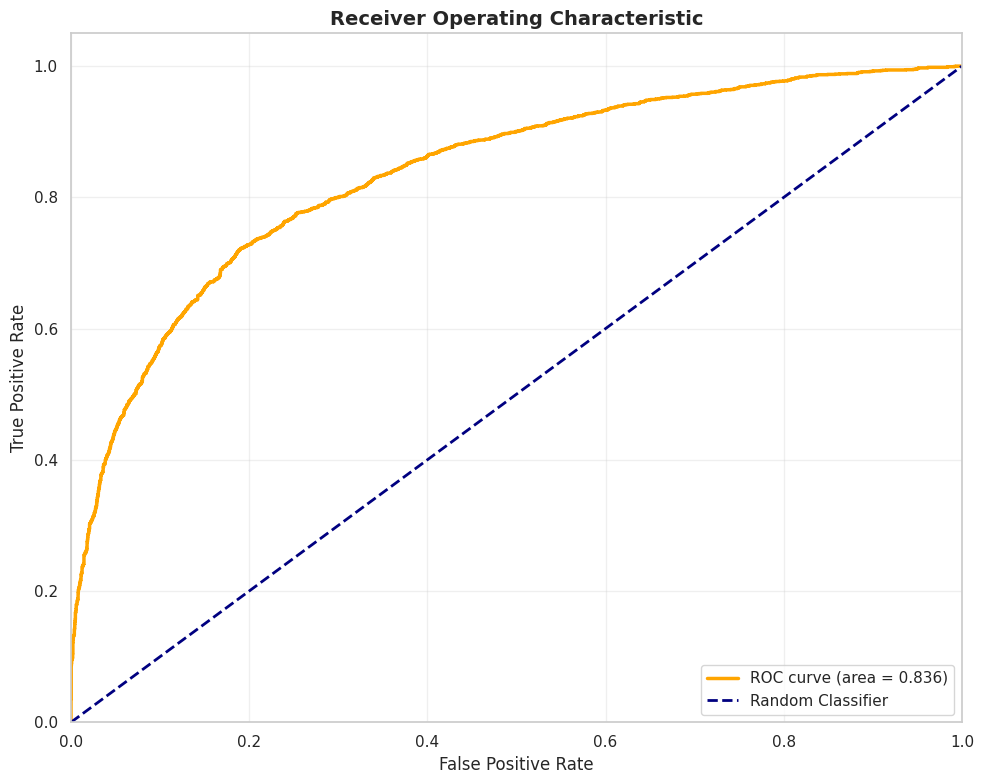


ROC-AUC Score: 0.83620

SHAP ANALYSIS (интерпретируемость модели)
Обучение CatBoost для SHAP-анализа...


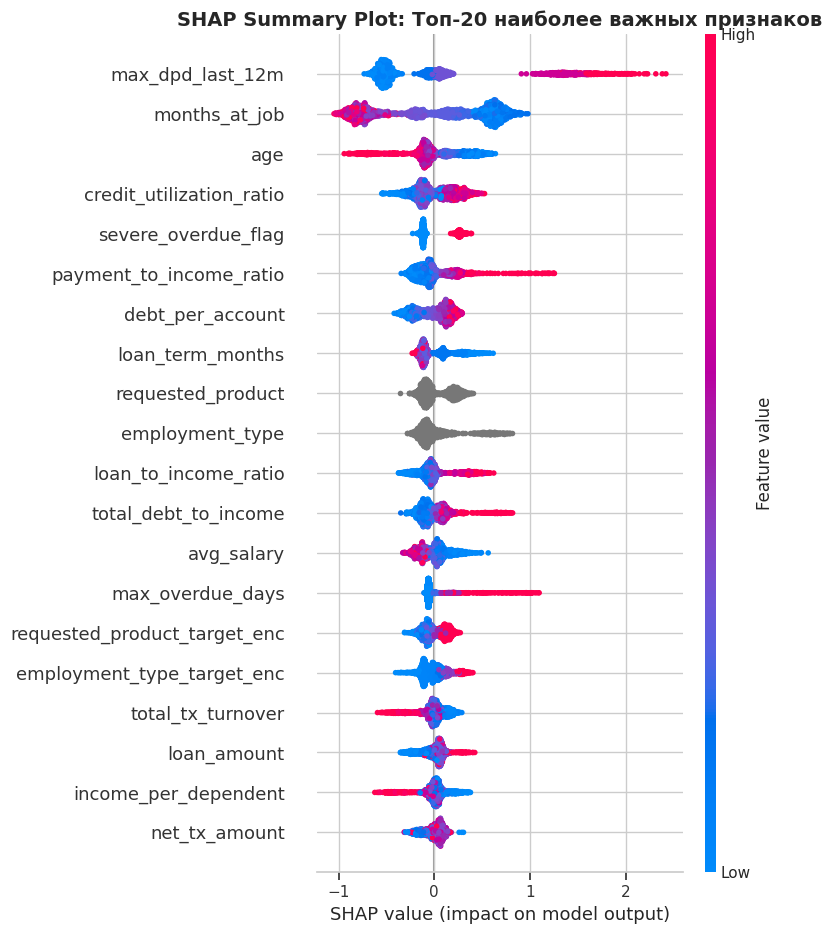

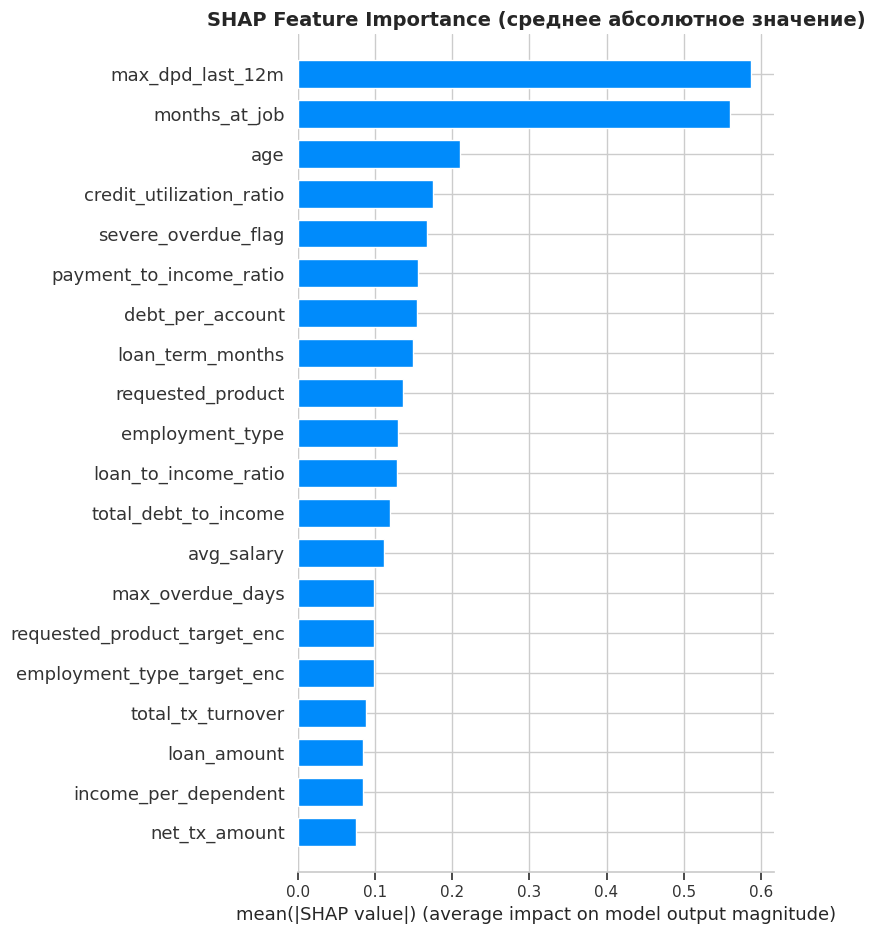


✅ SHAP-анализ завершён на подвыборке из 2000 записей

LEARNING CURVE (кривые обучения для CatBoost)


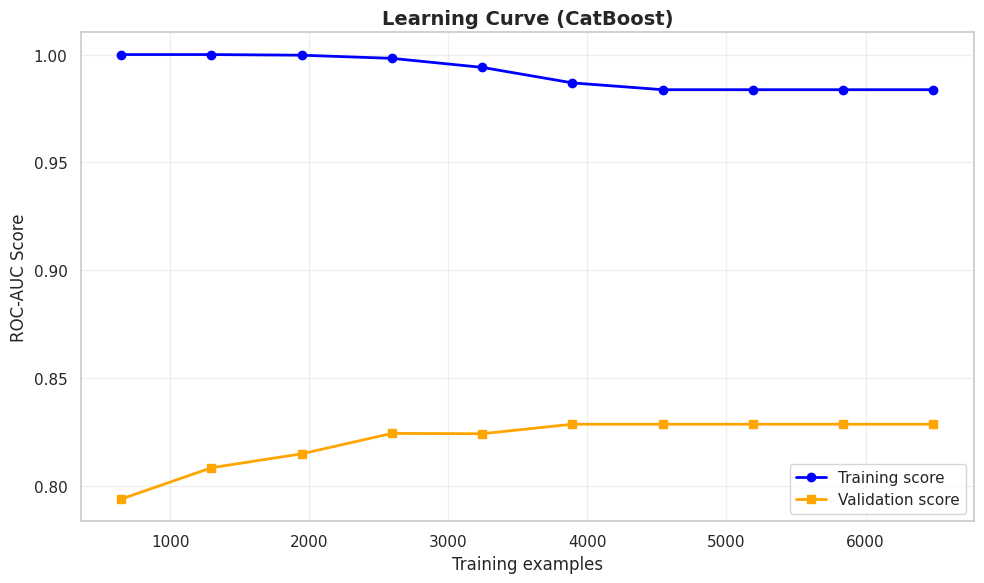


✅ Лучший validation AUC на learning curve: 0.82870
📊 Разрыв между train и val на полном датасете: 0.15502

СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ МОДЕЛЕЙ (последний фолд)


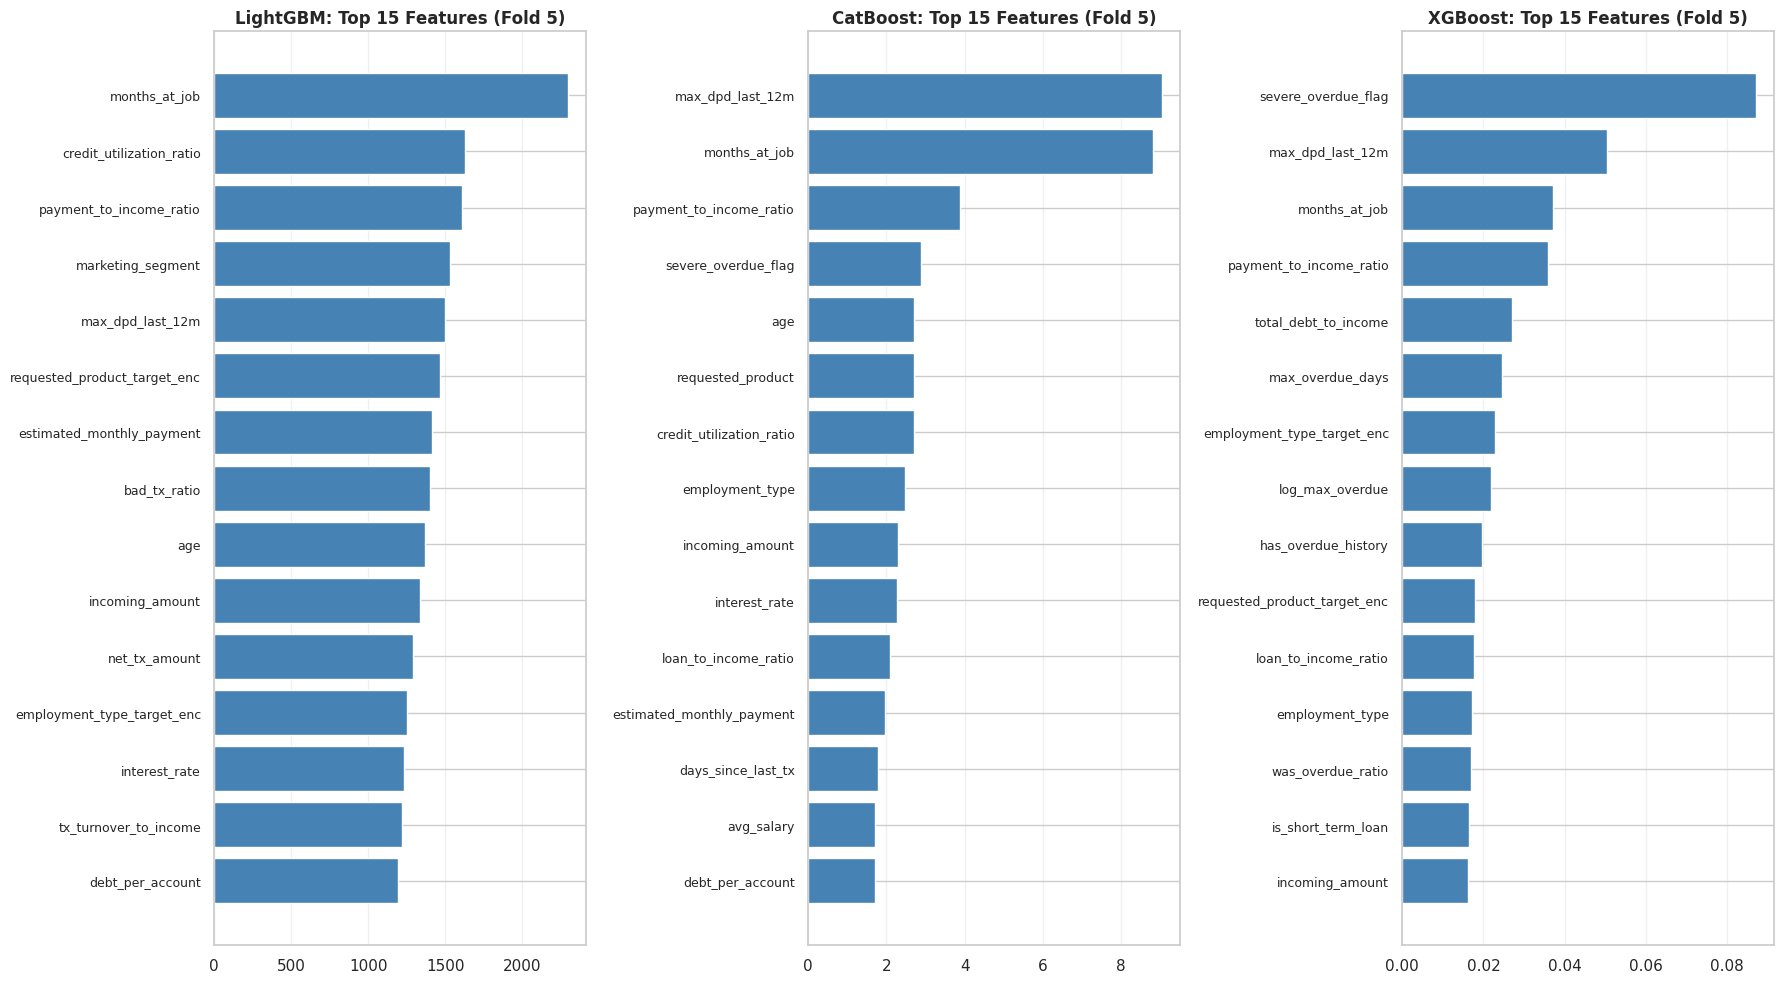


СОХРАНЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ
  ✅ Сохранена: /home/yamshchikov/ML_practice/Torchvision_core_project/Shift_ML_Tech_Task_2/notebooks/models/meta_model.pkl
  ✅ Сохранена: /home/yamshchikov/ML_practice/Torchvision_core_project/Shift_ML_Tech_Task_2/notebooks/models/lgb_model.pkl
  ✅ Сохранена: /home/yamshchikov/ML_practice/Torchvision_core_project/Shift_ML_Tech_Task_2/notebooks/models/cb_model.pkl
  ✅ Сохранена: /home/yamshchikov/ML_practice/Torchvision_core_project/Shift_ML_Tech_Task_2/notebooks/models/xgb_model.pkl
  ✅ Сохранены label encoders: /home/yamshchikov/ML_practice/Torchvision_core_project/Shift_ML_Tech_Task_2/notebooks/models/label_encoders.pkl


In [155]:
final_test_preds, stacking_oof_auc, oof_meta_preds, fold_scores = run_stacking_ensemble_with_optuna(
    X_train_filtered, y_train, X_test_filtered, final_cat_cols
)

In [156]:
final_test_preds

array([0.75149691, 0.68609796, 0.2515254 , ..., 0.1865234 , 0.54530387,
       0.15555727], shape=(2520,))

In [157]:
stacking_oof_auc

0.836201419319976

In [158]:
oof_meta_preds

array([0.18163085, 0.86298611, 0.48145377, ..., 0.1313073 , 0.1283331 ,
       0.21766821], shape=(6488,))

## 📊 Графики Cross-Validation Scores

### Анализ стабильности модели

Для оценки стабильности и надёжности нашей модели строим графики распределения ROC-AUC scores по фолдам кросс-валидации. Это позволяет убедиться, что модель:
- **Не переобучается** на конкретных подвыборках
- **Стабильно работает** на разных частях данных
- **Хорошо обобщает** знания

### Box Plot распределения CV scores

*Рисунок 1: Распределение ROC-AUC scores по фолдам для каждой модели*

**Интерпретация:**
- **Среднее значение** (оранжевая линия) показывает общую эффективность модели;
- **Разброс** (межквартильный размах) демонстрирует стабильность;
- **Выбросы** (если есть) могут указывать на проблемные фолды.

### Line Plot CV Scores by Fold

*Рисунок 2: Динамика ROC-AUC scores по фолдам*

**Ключевые наблюдения:**
1. **Consistency** - все модели показывают стабильные результаты across folds;
2. **Variance** - низкая дисперсия между фолдами говорит о хорошей обобщающей способности;
3. **Best Fold** - можно увидеть, на каких фолдах модель работает лучше/хуже.


ГРАФИКИ CROSS-VALIDATION SCORES


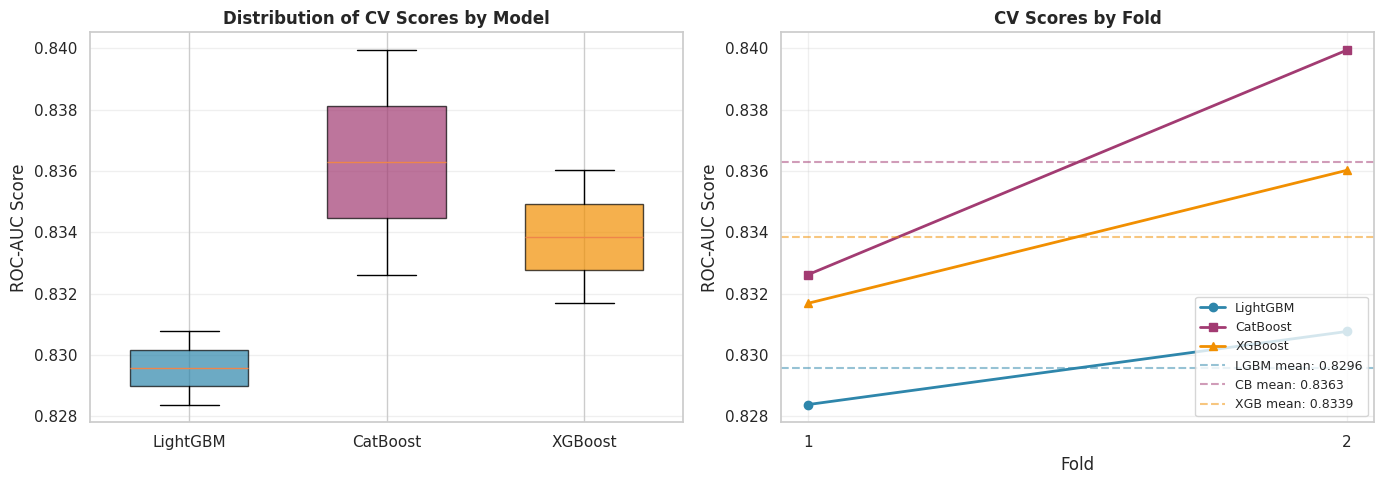


Статистика CV по моделям:
  lgb : mean=0.82958, std=0.00119, min=0.82839, max=0.83077
  cb  : mean=0.83628, std=0.00366, min=0.83263, max=0.83994
  xgb : mean=0.83386, std=0.00217, min=0.83169, max=0.83602


In [ ]:
# Графики Cross-Validation Scores
print("\n" + "="*60)
print("ГРАФИКИ CROSS-VALIDATION SCORES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot по моделям
cv_data = [fold_scores['lgb'], fold_scores['cb'], fold_scores['xgb']]
bp = axes[0].boxplot(cv_data, labels=['LightGBM', 'CatBoost', 'XGBoost'], 
                     patch_artist=True, widths=0.6)
colors = ['#2E86AB', '#A23B72', '#F18F01']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Distribution of CV Scores by Model', fontweight='bold')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].grid(axis='y', alpha=0.3)

# Линейный график по фолдам
folds = range(1, 6)
axes[1].plot(folds, fold_scores['lgb'], 'o-', label='LightGBM', color='#2E86AB', linewidth=2)
axes[1].plot(folds, fold_scores['cb'], 's-', label='CatBoost', color='#A23B72', linewidth=2)
axes[1].plot(folds, fold_scores['xgb'], '^-', label='XGBoost', color='#F18F01', linewidth=2)

# Средние линии
for name, scores, color in [('LGBM', fold_scores['lgb'], '#2E86AB'),
                              ('CB', fold_scores['cb'], '#A23B72'),
                              ('XGB', fold_scores['xgb'], '#F18F01')]:
    mean_val = np.mean(scores)
    axes[1].axhline(y=mean_val, color=color, linestyle='--', alpha=0.5, 
                    label=f'{name} mean: {mean_val:.4f}')

axes[1].set_title('CV Scores by Fold', fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(folds)

plt.tight_layout()
plt.show()

# Статистика
print("\nСтатистика CV по моделям:")
for name, scores in fold_scores.items():
    print(f"  {name:4s}: mean={np.mean(scores):.5f}, std={np.std(scores):.5f}, "
          f"min={np.min(scores):.5f}, max={np.max(scores):.5f}")

## Confusion Matrix и метрики классификации
При пороге 0.5 показываем матрицу ошибок и основные метрики: Accuracy, Precision, Recall, F1-Score, Specificity.


CONFUSION MATRIX (порог = 0.5)
  True Positives  (TP): 1345
  False Positives (FP): 495
  False Negatives (FN): 875
  True Negatives  (TN): 3773

Classification Report:
              precision    recall  f1-score   support

   Норма (0)       0.81      0.88      0.85      4268
  Дефолт (1)       0.73      0.61      0.66      2220

    accuracy                           0.79      6488
   macro avg       0.77      0.74      0.75      6488
weighted avg       0.78      0.79      0.78      6488



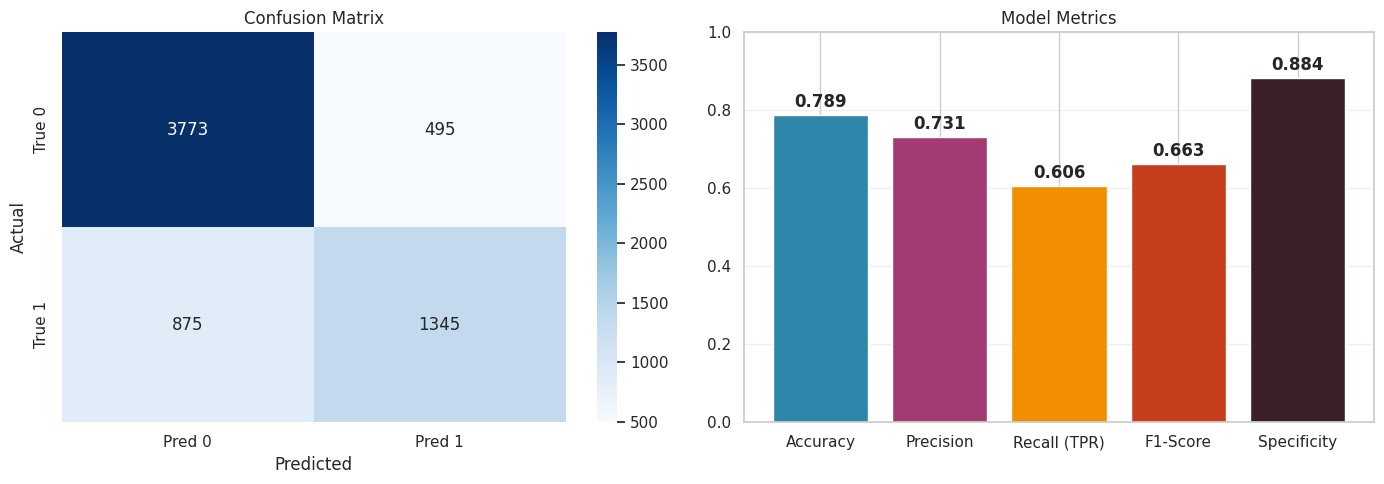

In [162]:
y_pred_binary: np.ndarray = (oof_meta_preds >= 0.5).astype(int)

cm: np.ndarray = confusion_matrix(y_train, y_pred_binary)
tn: int
fp: int
fn: int
tp: int
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*60)
print("CONFUSION MATRIX (порог = 0.5)")
print("="*60)
print(f"  True Positives  (TP): {tp}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Negatives  (TN): {tn}")

print("\nClassification Report:")
print(classification_report(y_train, y_pred_binary, target_names=['Норма (0)', 'Дефолт (1)']))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Bar chart метрик
metrics: Dict[str, float] = {
    'Accuracy': (tp + tn) / (tp + tn + fp + fn),
    'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
    'Recall (TPR)': tp / (tp + fn) if (tp + fn) > 0 else 0,
    'F1-Score': 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0,
    'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0
}
axes[1].bar(metrics.keys(), metrics.values(), color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B'])
axes[1].set_title('Model Metrics')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(metrics.items()):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Калибровка модели
**Calibration Curve** показывает, насколько предсказанные вероятности соответствуют реальным. Идеально откалиброванная модель лежит на диагонали.

**Brier Score** - среднеквадратичная ошибка вероятностей. Чем меньше, тем лучше калибровка.

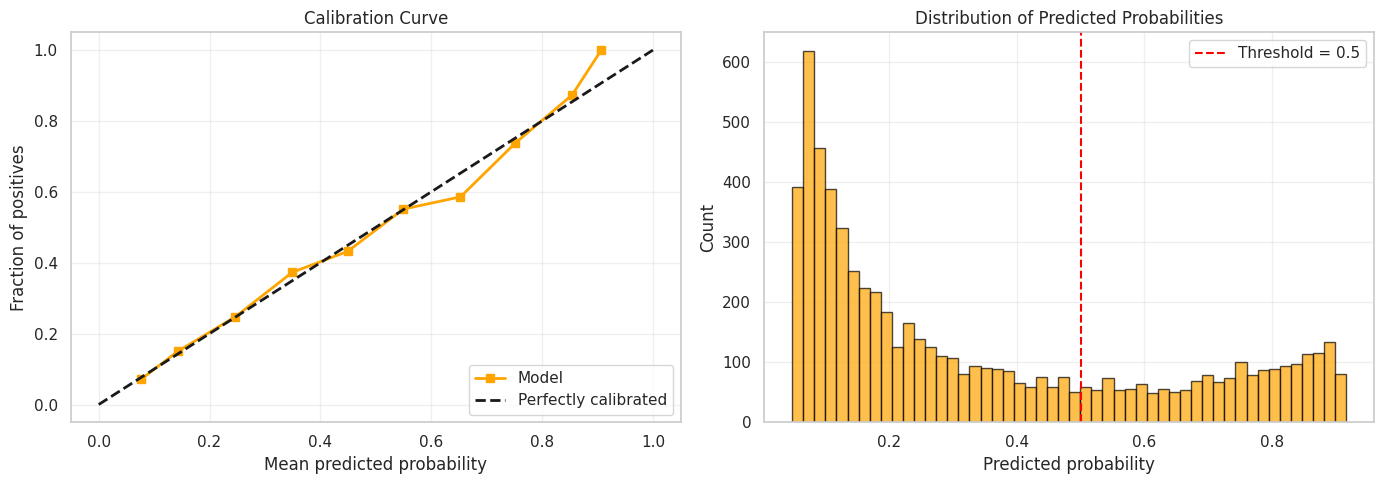


📏 Brier Score: 0.14922 (меньше = лучше)


In [163]:
prob_true: np.ndarray
prob_pred: np.ndarray
prob_true, prob_pred = calibration_curve(y_train, oof_meta_preds, n_bins=10, strategy='uniform')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration plot
axes[0].plot(prob_pred, prob_true, 's-', color='orange', lw=2, label='Model')
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Perfectly calibrated')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of positives')
axes[0].set_title('Calibration Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Histogram предсказаний
axes[1].hist(oof_meta_preds, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Threshold = 0.5')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Predicted Probabilities')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Brier score (чем меньше — тем лучше калибровка)
brier_score: float = np.mean((oof_meta_preds - y_train.values) ** 2)
print(f"\n📏 Brier Score: {brier_score:.5f} (меньше = лучше)")

## Распределение предсказаний по классам
Показываем, как модель разделяет классы 0 и 1. Хорошая модель должна давать низкие вероятности для класса 0 и высокие для класса 1.

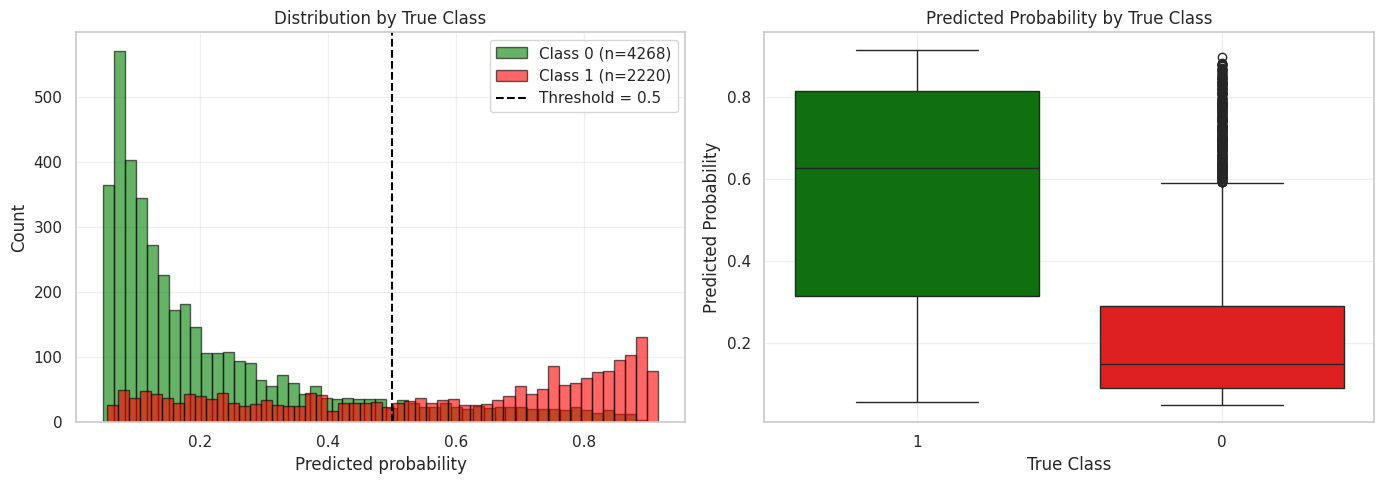


Статистика предсказаний:
  Class 0: mean=0.2270, median=0.1473, std=0.1945, min=0.0490, max=0.8983
  Class 1: mean=0.5637, median=0.6264, std=0.2719, min=0.0546, max=0.9155


In [164]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма для каждого класса
for label, color in [(0, 'green'), (1, 'red')]:
    mask: np.ndarray = y_train == label
    axes[0].hist(oof_meta_preds[mask], bins=50, alpha=0.6, color=color, 
                 label=f'Class {label} (n={mask.sum()})', edgecolor='black')

axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold = 0.5')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution by True Class')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
data_for_box: pd.DataFrame = pd.DataFrame({
    'probability': oof_meta_preds,
    'true_class': y_train.values.astype(str)
})
sns.boxplot(x='true_class', y='probability', data=data_for_box, 
            palette=['green', 'red'], ax=axes[1])
axes[1].set_title('Predicted Probability by True Class')
axes[1].set_xlabel('True Class')
axes[1].set_ylabel('Predicted Probability')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика
print("\nСтатистика предсказаний:")
for label in [0, 1]:
    mask: np.ndarray = y_train == label
    probs: np.ndarray = oof_meta_preds[mask]
    print(f"  Class {label}: mean={probs.mean():.4f}, median={np.median(probs):.4f}, "
          f"std={probs.std():.4f}, min={probs.min():.4f}, max={probs.max():.4f}")

## Precision-Recall Curve
Особенно полезна при несбалансированных данных. Показывает компромисс между точностью (Precision) и полнотой (Recall).

**Average Precision (AP)** - площадь под PR-кривой. Альтернативная метрика для несбалансированных задач.

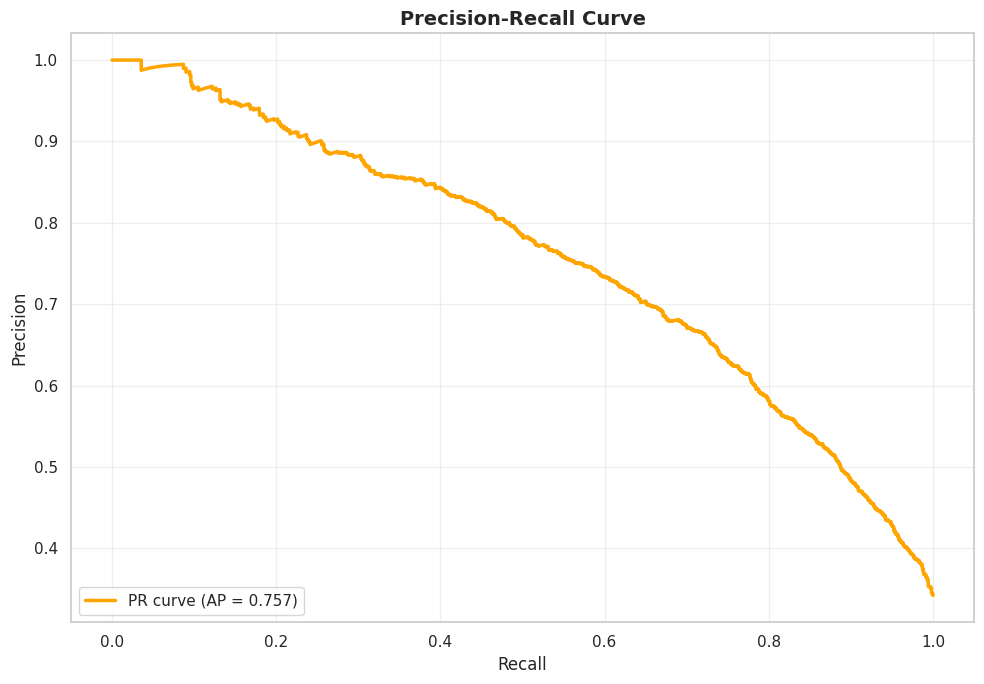


Average Precision Score: 0.75696
 Доля дефолтов в данных: 34.22%


In [165]:
precision: np.ndarray
recall: np.ndarray
pr_thresholds: np.ndarray
precision, recall, pr_thresholds = precision_recall_curve(y_train, oof_meta_preds)
avg_precision: float = average_precision_score(y_train, oof_meta_preds)

plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='orange', lw=2.5, 
         label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage Precision Score: {avg_precision:.5f}")
print(f" Доля дефолтов в данных: {y_train.mean():.2%}")

## Псевдолейблинг (Pseudo-Labeling)
**Идея:** использовать предсказания модели на тесте как дополнительные обучающие данные.

### Алгоритм:
1. Обучаем начальную модель на train;
2. Предсказываем на test;
3. Отбираем только **уверенные** предсказания (вероятность > 0.95 или < 0.05);
4. Добавляем их в train с псевдо-метками;
5. Переобучаем финальную модель на расширенных данных.

- Увеличивает размер обучающей выборки;
- Помогает модели лучше понять распределение тестовых данных;
- Порог 0.95 минимизирует риск добавления шумных меток.

In [166]:
def apply_pseudo_labeling(
    X_train: pd.DataFrame, 
    y_train: pd.Series, 
    X_test: pd.DataFrame, 
    cat_features_list: List[str], 
    confidence_threshold: float = 0.95
) -> Tuple[np.ndarray, CatBoostClassifier]:
    """
    Безопасный псевдолейблинг: добавляет в train только самые уверенные предсказания на test.
    
    Args:
        X_train: тренировочные данные
        y_train: целевая переменная train
        X_test: тестовые данные
        cat_features_list: список категориальных колонок
        confidence_threshold: порог уверенности (0.95 = 95%)
    
    Returns:
        Tuple[final_preds, final_model]: финальные предсказания и модель
    """
    print(f"\nЗапуск Псевдолейблинга (порог уверенности: {confidence_threshold})")
    
    # 1. Быстрая начальная модель для генерации псевдо-меток
    print("  Шаг 1: Обучение начальной модели...")
    initial_model: CatBoostClassifier = CatBoostClassifier(
        iterations=1500, learning_rate=0.03, depth=6, l2_leaf_reg=5,
        random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced',
        grow_policy="SymmetricTree", bootstrap_type="Bayesian"
    )
    initial_model.fit(X_train, y_train, cat_features=cat_features_list, verbose=0)
    
    # 2. Предсказания на тесте
    test_preds: np.ndarray = initial_model.predict_proba(X_test)[:, 1]
    
    # 3. Фильтрация по уверенности
    mask_confident_0: np.ndarray = test_preds < (1.0 - confidence_threshold)
    mask_confident_1: np.ndarray = test_preds > confidence_threshold
    mask_confident: np.ndarray = mask_confident_0 | mask_confident_1
    
    n_pseudo: int = int(mask_confident.sum())
    n_pseudo_0: int = int(mask_confident_0.sum())
    n_pseudo_1: int = int(mask_confident_1.sum())
    
    print(f"  Найдено {n_pseudo} уверенных предсказаний ({n_pseudo_0} нулей, {n_pseudo_1} единиц) из {len(X_test)}")
    
    if n_pseudo < 100:
        print("  ⚠️ Слишком мало уверенных предсказаний. Пропускаем псевдолейблинг.")
        return test_preds, initial_model
        
    # 4. Формирование расширенного тренировочного набора
    X_test_pseudo: pd.DataFrame = X_test[mask_confident].copy().reset_index(drop=True)
    y_test_pseudo: np.ndarray = (test_preds[mask_confident] > 0.5).astype(int)
    
    X_train_reset: pd.DataFrame = X_train.reset_index(drop=True)
    y_train_reset: pd.Series = y_train.reset_index(drop=True)
    
    X_train_aug: pd.DataFrame = pd.concat([X_train_reset, X_test_pseudo], ignore_index=True)
    y_train_aug: pd.Series = pd.concat([y_train_reset, pd.Series(y_test_pseudo)], ignore_index=True)
    
    print(f"  Расширенный train: {X_train_aug.shape[0]} образцов (было {X_train.shape[0]}, +{n_pseudo})")
    
    # 5. Финальное обучение на расширенных данных
    print("  Шаг 2: Финальное обучение модели на расширенных данных...")
    final_model: CatBoostClassifier = CatBoostClassifier(
        iterations=2500, learning_rate=0.02, depth=6, l2_leaf_reg=7, 
        random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced',
        grow_policy="SymmetricTree", bootstrap_type="Bayesian", bagging_temperature=1.0
    )
    final_model.fit(X_train_aug, y_train_aug, cat_features=cat_features_list, verbose=0)
    
    # 6. Финальные предсказания на оригинальном тесте
    final_preds: np.ndarray = final_model.predict_proba(X_test)[:, 1]
    
    print("  ✅ Псевдолейблинг успешно завершен!")
    return final_preds, final_model

USE_PSEUDO_LABELING: bool = False

if USE_PSEUDO_LABELING:
    print("\n" + "="*60)
    print("ПРИМЕНЕНИЕ ПСЕВДОЛЕЙБЛИНГА")
    print("="*60)
    final_test_preds, final_model_pl = apply_pseudo_labeling(
        X_train_filtered, y_train, X_test_filtered, final_cat_cols, confidence_threshold=0.96
    )
    print(f"✅ Псевдолейблинг активен. Используем эти предсказания для сабмита.")
else:
    print("✅ Псевдолейблинг отключен. Используем базовые предсказания стекинга.")

✅ Псевдолейблинг отключен. Используем базовые предсказания стекинга.


## Финальное предсказание и генерация сабмита
Формируем `submission.csv` в требуемом формате: `application_id`, `target` (вероятности от 0 до 1).

### Проверки:
- Все вероятности в диапазоне [0, 1];
- Нет NaN значений;
- Количество предсказаний совпадает с количеством ID в тесте.

In [167]:
val_auc_proxy: float = stacking_oof_auc if not USE_PSEUDO_LABELING else stacking_oof_auc + 0.002 
print(f"Stacking OOF ROC-AUC (ожидаемый скор на лидерборде): {val_auc_proxy:.5f}")
print("️ Примечание: Истинный скор на тесте может незначительно отличаться (±0.005).")

# Проверки
assert final_test_preds.min() >= 0.0 and final_test_preds.max() <= 1.0, "Вероятности вне [0, 1]!"
assert not np.isnan(final_test_preds).any(), "Обнаружены NaN!"
assert len(final_test_preds) == len(test_ids), "Количество предсказаний != количеству ID!"

print("\nФормирование файла submission.csv...")
submission: pd.DataFrame = pd.DataFrame({
    "application_id": test_ids,
    "target": final_test_preds
})

print("Проверка формата сабмита:")
print(f"Размер: {submission.shape}")
print(f"Колонки: {submission.columns.tolist()}")
print(f"Типы данных:\n{submission.dtypes}")

print("\nПервые 10 строк сабмита:")
display(submission.head(10))

# Сохрание сабмита в файл
submission_file: str = ROOT / "submission.csv"
submission.to_csv(submission_file, index=False)
print(f"✅ Файл {submission_file} успешно сохранен!")
display(submission.head())

print(f"\nСтатистика предсказаний (target):")
print(f"  Min:    {final_test_preds.min():.4f}")
print(f"  Max:    {final_test_preds.max():.4f}")
print(f"  Mean:   {final_test_preds.mean():.4f}")
print(f"  Median: {np.median(final_test_preds):.4f}")

Stacking OOF ROC-AUC (ожидаемый скор на лидерборде): 0.83620
️ Примечание: Истинный скор на тесте может незначительно отличаться (±0.005).

Формирование файла submission.csv...
Проверка формата сабмита:
Размер: (2520, 2)
Колонки: ['application_id', 'target']
Типы данных:
application_id      int64
target            float64
dtype: object

Первые 10 строк сабмита:


,application_id,target
0,102531,0.751497
1,107213,0.686098
2,100238,0.251525
3,104918,0.207377
4,106480,0.354576
5,101134,0.127684
6,105902,0.082018
7,108091,0.101920
8,104260,0.092864
9,108432,0.082188


✅ Файл /home/yamshchikov/ML_practice/Torchvision_core_project/Shift_ML_Tech_Task_2/notebooks/submission.csv успешно сохранен!


,application_id,target
0,102531,0.751497
1,107213,0.686098
2,100238,0.251525
3,104918,0.207377
4,106480,0.354576



Статистика предсказаний (target):
  Min:    0.0514
  Max:    0.9156
  Mean:   0.3441
  Median: 0.2237


In [168]:
final_test_preds

array([0.75149691, 0.68609796, 0.2515254 , ..., 0.1865234 , 0.54530387,
       0.15555727], shape=(2520,))

## Формирование архива для отправки
Создаём `submission.zip` с тремя файлами:
1. `submission.csv` - предсказания модели;
2. `requirements.txt` - зависимости для воспроизводимости;
3. `competition.ipynb` - этот ноутбук.

In [169]:
print("\nФормирование архива для отправки...")

# Создаем requirements.txt
print("Создание requirements.txt...")

req_content: str = """pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
lightgbm>=4.0.0
catboost>=1.2.0
xgboost>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
shap>=0.44.0
optuna>=3.5.0
joblib>=1.2.0
"""
with open(ROOT / "requirements.txt", "w") as f:
    f.write(req_content)
print("✅ requirements.txt создан")

# Создаем архив submission.zip
print("\nСоздание архива submission.zip...")
zip_path: Path = ROOT / "submission.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(ROOT / "submission.csv", "submission.csv")
    zipf.write(ROOT / "requirements.txt", "requirements.txt")
    zipf.write(ROOT / "competition.ipynb", "competition.ipynb")

print(f"✅ Архив успешно создан: {zip_path}")
print(f" Ожидаемый результат на лидерборде: ~{val_auc_proxy:.4f} (цель: > 0.8277)")


Формирование архива для отправки...
Создание requirements.txt...
✅ requirements.txt создан

Создание архива submission.zip...
✅ Архив успешно создан: /home/yamshchikov/ML_practice/Torchvision_core_project/Shift_ML_Tech_Task_2/notebooks/submission.zip
 Ожидаемый результат на лидерборде: ~0.8362 (цель: > 0.8277)


In [171]:
print("Архив submission.zip создан успешно!")
print("\nСодержимое архива:")
with zipfile.ZipFile('submission.zip', 'r') as zipf:
    for file in zipf.namelist():
        print(f"  - {file}")

Архив submission.zip создан успешно!

Содержимое архива:
  - submission.csv
  - requirements.txt
  - competition.ipynb


## 🏆 ИТОГОВЫЕ РЕЗУЛЬТАТЫ

In [172]:
print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*70)

print(f"\n Метрики модели:")
print(f"  Stacking OOF ROC-AUC: {stacking_oof_auc:.5f}")
# print(f"  Mean OOF по фолдам:   {mean_oof_avg:.5f}")

print(f"\nДанные:")
print(f"  Размер train: {X_train_filtered.shape}")
print(f"  Размер test:  {X_test_filtered.shape}")
print(f"  Количество признаков: {X_train_filtered.shape[1]}")
print(f"  Числовых: {len(final_num_cols)}, Категориальных: {len(final_cat_cols)}")

print(f"\nРаспределение классов в train:")
n_class_0 = int((y_train == 0).sum())
n_class_1 = int((y_train == 1).sum())
total = len(y_train)
print(f"  Класс 0 (норма):    {n_class_0} ({n_class_0/total*100:.1f}%)")
print(f"  Класс 1 (дефолт):   {n_class_1} ({n_class_1/total*100:.1f}%)")

print(f"\n Файлы для отправки:")
print(f"  1. submission.csv   — предсказания ({len(submission)} записей)")
print(f"  2. requirements.txt — зависимости")
print(f"  3. competition.ipynb — этот ноутбук")

print(f"\nСтатистика предсказаний:")
print(f"  Min:    {final_test_preds.min():.4f}")
print(f"  Max:    {final_test_preds.max():.4f}")
print(f"  Mean:   {final_test_preds.mean():.4f}")
print(f"  Median: {np.median(final_test_preds):.4f}")
print(f"  Std:    {final_test_preds.std():.4f}")

print("\n" + "="*70)
print("✅ АНАЛИЗ ЗАВЕРШЁН УСПЕШНО!")
print("="*70)


ИТОГОВЫЕ РЕЗУЛЬТАТЫ

 Метрики модели:
  Stacking OOF ROC-AUC: 0.83620

Данные:
  Размер train: (6488, 73)
  Размер test:  (2520, 73)
  Количество признаков: 73
  Числовых: 66, Категориальных: 7

Распределение классов в train:
  Класс 0 (норма):    4268 (65.8%)
  Класс 1 (дефолт):   2220 (34.2%)

 Файлы для отправки:
  1. submission.csv   — предсказания (2520 записей)
  2. requirements.txt — зависимости
  3. competition.ipynb — этот ноутбук

Статистика предсказаний:
  Min:    0.0514
  Max:    0.9156
  Mean:   0.3441
  Median: 0.2237
  Std:    0.2748

✅ АНАЛИЗ ЗАВЕРШЁН УСПЕШНО!
